In [1]:
import numpy as np
import pandas as pd
import glob, os, vcf, warnings, shutil, subprocess, re
from Bio import Seq, SeqIO
from Bio.Data import CodonTable
import sys
sys.path.append("variantDetector")
from utils import *

warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import scipy, pysam
from matplotlib.colors import ListedColormap
from collections import Counter
from dna_features_viewer import GraphicFeature, GraphicRecord

h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

# remove rRNAs, which are highly conserved. rrs, rrl, and rrf
rRNA_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='stable RNAs' & Feature=='rRNA'").iterrows():
    # print(row['Name'])
    rRNA_pos += list(np.arange(row['Start'], row['Stop'] + 1))

TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_trust_patients = pd.read_csv(f"{TRUST_data_dir}/combined_patient_WGS_data.csv").dropna(subset='Lineage')

isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")
isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/isolate_variants_WHO_catalog.csv")

for i, row in df_trust_patients.iterrows():
    if not row['Original_ID'].startswith('S'):
        
        length_numerical = len(row['Original_ID'].split('-')[0])
            
        newID = 'S' + '0' * (4 - length_numerical) + row['Original_ID']
        df_trust_patients.loc[i, 'Original_ID'] = newID

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

mixed_samples = df_trust_patients.query("F2 > 0.03").SampleID.unique()

def get_RvID_from_gff(attr_str):
    """
    Parse the attributes column of a GFF line.
    Returns a dict of key:value pairs.
    """
    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['ID'].split('-')[-1]


def get_geneName_from_gff(attr_str):

    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['Name']

F2_max = 0.03

df_who_variants = pd.read_csv(f"~/MtbQuantCNN/data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
genes_with_awR_mutations = df_who_variants.loc[df_who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].gene.unique()

cc_df = pd.read_csv(f"~/MtbQuantCNN/data_processing/data_utils/drug_CC.csv")

In [2]:
# genome_dict = compute_syn_nonsyn_sites_from_df(h37Rv_seq.seq, h37Rv_genes, genetic_code='Bacterial')

In [3]:
# syn_total, nonsyn_total = genome_dict['syn_sites_total'], genome_dict['nonsyn_sites_total']

# Get pids without lineage mixing and with lineage concordance at the two timepoints

In [2]:
df_longitudinal_pids = pd.read_csv(f"{TRUST_data_dir}/longitudinal_pids_WGS_data.csv")
print(f"{df_longitudinal_pids.pid.nunique()} pids")

325 pids


In [3]:
df_longitudinal_pids['Major_Lineage'] = np.nan
df_longitudinal_pids['Major_Lineage_Prop'] = np.nan
df_longitudinal_pids['Minor_Lineage'] = np.nan
df_longitudinal_pids['Minor_Lineage_Prop'] = np.nan

for i, row in df_longitudinal_pids.iterrows():
    
    pid = row['pid']
    sample = row['SampleID']
    
    if ',' in row['mix_phylotypes']:
        
        lineages = row['mix_phylotypes'].split(',')
        props = np.array(row['mix_props'].split(',')).astype(float)
        
        major_lineage = lineages[np.argmax(props)]
        major_prop = np.max(props)
        
    else:
        major_lineage = row['mix_phylotypes']
        major_prop = 1
    
    df_longitudinal_pids.loc[i, 'Major_Lineage'] = major_lineage
    df_longitudinal_pids.loc[i, 'Major_Lineage_Prop'] = major_prop
    
    if ',' in row['mix_phylotypes']:
        
        second_highest_idx = np.argpartition(props, -2)[-2]
        
        df_longitudinal_pids.loc[i, 'Minor_Lineage'] = lineages[second_highest_idx]
        df_longitudinal_pids.loc[i, 'Minor_Lineage_Prop'] = props[second_highest_idx]

df_longitudinal_pids['Major_Lineage'] = df_longitudinal_pids['Major_Lineage'].fillna(df_longitudinal_pids['Coll2014'])
df_longitudinal_pids['Major_Lineage_Prop'] = df_longitudinal_pids['Major_Lineage_Prop'].fillna(1)

df_longitudinal_pids['Major_Minor_Diff'] = df_longitudinal_pids['Major_Lineage_Prop'] - df_longitudinal_pids['Minor_Lineage_Prop']
df_longitudinal_pids['Sampling_Interval'] = df_longitudinal_pids.groupby('pid')['Sampling_Week'].transform(lambda x: np.max(x) - np.min(x))

In [4]:
pids_different_major_lineages = pd.DataFrame(df_longitudinal_pids.query("F2 <= @F2_max").groupby('pid')['Major_Lineage'].nunique()).query("Major_Lineage > 1").index.values

print(f"{len(pids_different_major_lineages)} pids have discordant unmixed samples")

df_longitudinal_pids = df_longitudinal_pids.query("pid not in @pids_different_major_lineages").reset_index(drop=True)

17 pids have discordant unmixed samples


In [5]:
df_pids_low_F2_same_lineage = pd.DataFrame(df_longitudinal_pids.query("F2 <= @F2_max").groupby('pid')['Major_Lineage'].count()).query("Major_Lineage > 1")

# should only be the value 2 now
assert df_pids_low_F2_same_lineage.Major_Lineage.nunique() == 1

pids_with_same_lineage_and_low_F2 = df_pids_low_F2_same_lineage.index.values

print(f"{len(pids_with_same_lineage_and_low_F2)}/{df_longitudinal_pids.pid.nunique()} pids have low F2 and the same lineage at both timepoints")

286/308 pids have low F2 and the same lineage at both timepoints


# Read in Low AF SNPs: Filtered, then predicted to be Real or Not by a Linear Mixed Model

In [6]:
df_baseline_samples = df_trust_patients.query("F2 <= @F2_max & Sampling_Week <= 2").sort_values(['pid', 'Sampling_Week']).drop_duplicates(subset='pid', keep='first')
print(f"{df_baseline_samples.pid.nunique()} pids with baseline samples with F2 ≤ {F2_max}")

395 pids with baseline samples with F2 ≤ 0.03


In [7]:
# samples_lst = os.listdir(H37Rv_ref_dir)

# for sample in df_baseline_samples.SampleID.values:
#     if sample not in samples_lst:
#         print(sample)

In [291]:
def read_in_process_variants(model_dir, df_pids, AF_thresh=0.95):
    
    df_fixed_variants = pd.read_csv(f"{model_dir}/fixed_variants.csv.gz", compression='gzip')

#     # 3037377 was not excluded for this reason, but it's problematic. It's typically a fixed variant, but the coverage drops substantially
#     exclude_pos = [454295, 554179, 630722, 2338275, 2338811, 2338961, 3037377, 3296843, 3851887, 3851888, 4328030]
#     df_fixed_variants = df_fixed_variants.query("POS not in @exclude_pos")
    
    # contains Real or not for the samples with a personal genome
    df_train_variants = pd.read_csv(f"{model_dir}/training_data_with_predictions.csv").query("Real == 1")

    # because of the discordant reads at the end of the linear reference genome, which are not actually discordant, it's just because the circular genome was linearized
    # the binary classifier will predict some low frequency variants at the ends as false because of all the discordantly paired reads there
    # this means that variant upstream of the first position and downstream of the last position can be erroneously flagged as not real
    first_pos = df_train_variants.query("Real==1").POS.min()
    last_pos = df_train_variants.query("Real==1").POS.max()

    # all other samples
    df_val_variants = pd.read_csv(f"{model_dir}/validation_data_with_predictions.csv")
    
    # exclude fixed SNP sites that had a low quality low frequency variant. Exclude these from the fixed counts too
    for pid in df_val_variants.pid.unique():

        false_lowAF_variant_sites = df_val_variants.query("pid==@pid & pred_class==0 & POS >= @first_pos & POS <= @last_pos & AF <= @AF_thresh").POS.values

        if len(false_lowAF_variant_sites) > 0:
            remove_pos = df_fixed_variants.query("pid==@pid & POS in @false_lowAF_variant_sites & AF > @AF_thresh").POS.unique()
            
#             if len(remove_pos) > 0:
#                 print(pid, len(remove_pos))
            
            df_fixed_variants = df_fixed_variants.query("~(pid == @pid & POS in @false_lowAF_variant_sites & AF > @AF_thresh)")
        
    # false negatives in the train set in MFS-325 and MFS-326. It is therefore predicted False in the validation set for MFS-306, so manually set it real
    # The paired sample, MFS-305 does not have this variant
    df_val_variants.loc[(df_val_variants['SampleID']=='MFS-306') & (df_val_variants['POS']==1699255), 'pred_class'] = 1

    # only apply the filter for classifier filter to low frequency variants
    df_val_variants = df_val_variants.query("(pred_class == 1 & POS >= @first_pos & POS <= @last_pos) | POS < @first_pos | POS > @last_pos")
    
    assert len(set(df_train_variants.SampleID).intersection(df_val_variants.SampleID)) == 0
    df_variants = pd.concat([df_train_variants, df_val_variants])

    # set the variants that were False everywhere in the ground truth set to False. These should be flagged as suspicious sites
    df_variants = df_variants.query("False_in_all_Ground_Truth_Samples==0").reset_index(drop=True)
        
    df_variants = pd.concat([df_fixed_variants, df_variants]).merge(df_pids[['SampleID', 'Sampling_Week']], on='SampleID')
    
    # drop duplicates because we lowered the AF threshold to 0.9, so if the threshold was higher in the past, then there will be duplicates
    # preferentially keep the one in the fixed variants df
    df_variants = df_variants.drop_duplicates(subset=['SampleID', 'POS', 'REF', 'ALT'], keep='first')

    df_variants['SNP'] = df_variants['POS'].astype(str) + '_' + df_variants['REF'] + '_' + df_variants['ALT']

    df_variants['Region'] = df_variants['POS'].map(h37Rv_coords_dict)

#     df_variants.loc[(df_variants['Region'].str.contains('NC')) & (df_variants['GENE'].str.contains('-')), 'Variant_Type'] = 'Intergenic'
#     df_variants.loc[(df_variants['Region'].str.contains('NC')) & (~df_variants['GENE'].str.contains('-')), 'Variant_Type'] = 'Noncoding'

#     df_variants.loc[~pd.isnull(df_variants['HGVS_P']), 'REF_AA'] = df_variants.loc[~pd.isnull(df_variants['HGVS_P'])]['HGVS_P'].str.split('p\.').str[-1].str[:3]
#     df_variants.loc[~pd.isnull(df_variants['HGVS_P']), 'ALT_AA'] = df_variants.loc[~pd.isnull(df_variants['HGVS_P'])]['HGVS_P'].str.split('p\.').str[-1].str[-3:]

#     df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic'])) & ((df_variants['REF_AA'] == df_variants['ALT_AA']) | (df_variants['ANN'].str.contains('initiator_codon_variant'))), 'Variant_Type'] = 'Silent'

#     df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent'])) &
#                           (df_variants['HGVS_P'].str.contains('ext*?')), 'Variant_Type'] = 'Stop_Lost'

#     df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost'])) &
#                           (df_variants['HGVS_P'].str.contains('\?')), 'Variant_Type'] = 'Start_Lost'

#     df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost', 'Start_Lost'])) & 
#                           (df_variants['HGVS_P'].str.contains('\*')), 'Variant_Type'] = 'Nonsense'

#     df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost', 'Start_Lost', 'Nonsense'])), 'Variant_Type'] = 'Missense'
        
    # return pd.concat([df_fixed_variants, df_variants]), df_variants.drop_duplicates().reset_index(drop=True)
    return df_variants.drop_duplicates().reset_index(drop=True).dropna(axis=1, how='all'), df_variants.query("AF >= 0.05 & AF <= @AF_thresh").drop_duplicates().dropna(axis=1, how='all').reset_index(drop=True)

In [292]:
df_variants, df_lowAF_variants = read_in_process_variants("./pilonVariantDetector/unmixed_only", df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2"))

df_variants = df_variants.merge(df_longitudinal_pids[['SampleID', 'Paired_Sample_Num']])
df_lowAF_variants = df_lowAF_variants.merge(df_longitudinal_pids[['SampleID', 'Paired_Sample_Num']])

# df_variants[['GENE1', 'GENE2']] = df_variants['GENE'].str.split('-', expand=True)

# 1406
len(df_variants), len(df_lowAF_variants)

(560497, 1309)

In [293]:
df_variants_baseline, df_lowAF_variants_baseline = read_in_process_variants("./pilonVariantDetector/unmixed_only", df_baseline_samples)

# 385398
len(df_variants_baseline), len(df_lowAF_variants_baseline)

(385398, 847)

In [294]:
df_variants_full, df_lowAF_variants_full = read_in_process_variants("./pilonVariantDetector/unmixed_only", df_trust_patients.dropna(subset='Lineage').query("F2 <= @F2_max"))

# df_lowAF_variants_full[['GENE1', 'GENE2']] = df_lowAF_variants_full['GENE'].str.split('-', expand=True)

# 1,837
print(len(df_lowAF_variants_full))

1715


In [295]:
# when doing the enrichment analysis, keep only the first SampleID for each pid because that's a source of bias
keep_samples = []

for pid in df_lowAF_variants_full.pid.unique():
    
    if df_lowAF_variants_full.query("pid==@pid").SampleID.nunique() > 1:
        keep_samples += list(df_lowAF_variants_full.query("pid==@pid").sort_values('Sampling_Week').drop_duplicates(subset='pid', keep='first').SampleID.unique())
    else:
        keep_samples += list(df_lowAF_variants_full.query("pid==@pid").SampleID.unique())
        
assert len(keep_samples) == df_lowAF_variants_full.pid.nunique()

df_lowAF_variants_full_for_enrichment_test = df_lowAF_variants_full.query("SampleID in @keep_samples").reset_index(drop=True)
print(len(df_lowAF_variants_full_for_enrichment_test), len(df_lowAF_variants_full))

# for i, row in df_lowAF_variants_full_for_enrichment_test.iterrows():
    
#     # duplicate it so that we can use dataframe groupby to count the number of variants per gene
#     if not pd.isnull(row['GENE2']):
        
#         # replace the GENE column with GENE1
#         df_lowAF_variants_full_for_enrichment_test.loc[i, 'GENE'] = row['GENE1']
        
#         df_add = pd.DataFrame(row).T
        
#         # replace the GENE column in the copied dataframe GENE2
#         df_add['GENE'] = row['GENE2']
                
#         df_lowAF_variants_full_for_enrichment_test = pd.concat([df_lowAF_variants_full_for_enrichment_test,
#                                                                 df_add
#                                                                ])

len(df_variants_full), len(df_lowAF_variants_full), len(df_lowAF_variants_full_for_enrichment_test)

df_lowAF_variants_full.to_csv("unfixed_SNVs_all_pilon.csv", index=False)

1026 1715


In [296]:
df_lowAF_variants_full_for_enrichment_test.drop_duplicates(subset=['pid', 'POS', 'REF', 'ALT']).Lineage.value_counts()

Lineage
2.0    566
4.0    385
3.0     75
Name: count, dtype: int64

In [298]:
# df_lowAF_variants_full_for_enrichment_test.query("Variant_Type != 'Silent'").drop_duplicates(subset=['pid', 'POS', 'REF', 'ALT']).Lineage.value_counts()

In [299]:
df_lowAF_variants_full_for_enrichment_test.pid.nunique(), df_lowAF_variants_full_for_enrichment_test.SampleID.nunique()

(346, 346)

In [301]:
# len(df_lowAF_variants_full_for_enrichment_test.query("Variant_Type != 'Silent'"))

# Are unfixed SNVs enriched in certain genes?

Accounting for GC composition of the gene, the length of the gene, and the type of substitution

In [302]:
def estimate_mutation_rates(variants_df, h37Rv_seq):
    
    # Count substitutions
    sub_counts = Counter(zip(variants_df["REF"], variants_df["ALT"]))

    # Count genome-wide base composition
    genome_base_counts = Counter(h37Rv_seq.seq)

    # Compute per-base mutation rates
    mu = {}
    for ref in "ACGT":
        ref_total = genome_base_counts.get(ref, 0)
        for alt in "ACGT":
            if ref != alt:
                mu[(ref, alt)] = sub_counts.get((ref, alt), 0) / ref_total

    return mu



def expected_mutations_per_gene(regions_lst, h37Rv_seq, mu):
    
    expected = {}
    gene_lengths = {}

    for region in regions_lst:
        
        if region in h37Rv_regions.Name.values:
            start = h37Rv_regions.query("Name==@region").Start.values[0]
            end = h37Rv_regions.query("Name==@region").Stop.values[0]
            
        elif 'NC' in region:
            start = h37Rv_coords.query("region==@region").pos.min()
            end = h37Rv_coords.query("region==@region").pos.max()
            
        else:
            raise ValueError(f"{region} not found!")
            
        seq = str(h37Rv_seq.seq[start-1:end]).upper()

        counts = Counter(seq)

        E = 0.0
        for ref in "ACGT":
            for alt in "ACGT":
                if ref != alt:
                    E += counts.get(ref, 0) * mu[(ref, alt)]

        expected[region] = E
        gene_lengths[region] = [start, end, len(seq)]

    return pd.Series(expected, name="Expected"), pd.DataFrame(gene_lengths, index=['Start', 'End', 'Length']).T



def poisson_two_sided_pval(observed, expected):
    
    observed = np.asarray(observed)
    expected = np.asarray(expected)
    
    # Poisson is discrete; use min-tail approach
    lower_tail = st.poisson.cdf(observed, expected)
    upper_tail = st.poisson.sf(observed - 1, expected)
    
    pval = 2 * np.minimum(lower_tail, upper_tail)
    return np.minimum(pval, 1.0)



def poisson_enrichment_test(observed, expected):
    
    df = pd.concat([observed, expected], axis=1).fillna(0)

    df["Fold_Enrichment"] = df["Observed"] / df["Expected"].replace(0, np.nan)

    # One-sided test: enrichment
    df["Enrich_pval"] = st.poisson.sf(df["Observed"] - 1, df["Expected"])
    
    # One-sided test: de-enrichment (depletion)
    df["Deplete_pval"] = st.poisson.cdf(df["Observed"], df["Expected"])
    
    # Two-sided test: Poisson is discrete; use min-tail approach
    df["Twosided_pval"] = poisson_two_sided_pval(df["Observed"], df["Expected"])

    return df.sort_values("Twosided_pval")


# def permutation_test(variants_df, observed, genes_lst, genome_seq, n_perm=1000, seed=1):
    
#     rng = np.random.default_rng(seed)

#     # Genome positions by base
#     base_positions = {
#         b: np.where(np.array(list(genome_seq)) == b)[0]
#         for b in "ACGT"
#     }
    
#     gene_lengths = {}
    
#     for gene in genes_lst:
#         if gene not in h37Rv_genes.Symbol.values:
#             print(f"{gene} is not a gene")
#         else:
#             start = h37Rv_genes.query("Symbol==@gene").Start.values[0]
#             end = h37Rv_genes.query("Symbol==@gene").End.values[0]
#             gene_lengths[gene] = end - start + 1

#     gene_offsets = np.cumsum([0] + list(gene_lengths.values()))
#     gene_names = list(gene_lengths.keys())

#     def position_to_gene(pos):
#         idx = np.searchsorted(gene_offsets, pos, side="right") - 1
#         return gene_names[idx] if 0 <= idx < len(gene_names) else None

#     perm_counts = {g: [] for g in genes_lst}

#     ref_alt = list(zip(variants_df["REF"], variants_df["ALT"]))

#     for _ in range(n_perm):
#         counts = Counter()

#         for ref, alt in ref_alt:
#             pos = rng.choice(base_positions[ref])
#             gene = position_to_gene(pos)
#             if gene is not None:
#                 counts[gene] += 1

#         for g in genes_lst:
#             perm_counts[g].append(counts.get(g, 0))

#     # Compute empirical p-values
#     results = []
#     for i, g in enumerate(genes_lst):
#         obs = observed.get(g, 0)
#         perm = np.array(perm_counts[g])
#         p = (np.sum(perm >= obs) + 1) / (n_perm + 1)
#         results.append((g, p))

#     return pd.DataFrame(results, columns=["GENE", "Permutation_pval"]).set_index("GENE")


def perform_poisson_enrichment_test(variants_df, exclude_silent=False, keep_lineages=None):
            
    background_df = variants_df.copy()

    # by default, keep all variants. Can exclude silent variants if wanted
    if exclude_silent:
        variants_df = variants_df.query("Variant_Type != 'Silent'")
        
    if keep_lineages is not None:
        background_df = background_df.query("Lineage in @keep_lineages")
        variants_df = variants_df.query("Lineage in @keep_lineages")
        assert len(variants_df) > 0
        
    # genes_lst = variants_df.query("Variant_Type != 'Intergenic'").GENE.unique()
    
    # include intergenic regions too. Need to get names from different columns though
    regions_lst = np.concatenate([variants_df.query("Variant_Type != 'Intergenic'").GENE.unique(), variants_df.query("Variant_Type == 'Intergenic'").Region.unique()])

    # do full dataset, then separate by lineage as well. KEEP intergenic variants for estimating genome-wide mutation rate
    mu = estimate_mutation_rates(background_df.drop_duplicates(subset=['SampleID', 'POS', 'REF', 'ALT']), h37Rv_seq)
    print(f"Genome-wide mutation rate: {mu}\n")

    expected, df_gene_lengths = expected_mutations_per_gene(regions_lst, h37Rv_seq, mu)
    
    # observed = variants_df.query("Variant_Type != 'Intergenic'").groupby("GENE").size().rename("Observed")
    
    # Names come from different columns for coding and non-coding variants
    observed = pd.concat([variants_df.query("Variant_Type != 'Intergenic'").groupby("GENE").size().rename("Observed"),
                          variants_df.query("Variant_Type == 'Intergenic'").groupby("Region").size().rename("Observed")
                         ])

    poisson_results = poisson_enrichment_test(observed, expected)
    
    return poisson_results.merge(df_gene_lengths, left_index=True, right_index=True), mu

In [303]:
exclude_silent = True
df_combined_results = []

# results on full dataset
poisson_results, mu = perform_poisson_enrichment_test(df_lowAF_variants_full_for_enrichment_test, exclude_silent=exclude_silent, keep_lineages=None)
poisson_results['Lineage'] = 'Full'
poisson_results['Bonferroni_pval'] = poisson_results['Enrich_pval'] * len(poisson_results)
df_combined_results.append(poisson_results)

# lineage-specific enrichment
for lineage in np.sort(df_lowAF_variants_full['Lineage'].unique()):
    
    num_samples = df_lowAF_variants_full.query("Lineage in [@lineage]").SampleID.nunique()
    print(f"L{str(int(lineage))}, N = {num_samples}")
    
    poisson_results, _ = perform_poisson_enrichment_test(df_lowAF_variants_full_for_enrichment_test, exclude_silent=exclude_silent, keep_lineages=[lineage])
    poisson_results['Lineage'] = str(int(lineage))
    poisson_results['Bonferroni_pval'] = poisson_results['Enrich_pval'] * len(poisson_results)
    df_combined_results.append(poisson_results)

    # perm_results = permutation_test(df_lowAF_variants_full_for_enrichment_test, observed, genes_lst, h37Rv_seq, n_perm=1000)

    # final = poisson_results.join(perm_results)
    
df_combined_results = pd.concat(df_combined_results)
assert len(df_combined_results.query("Expected==0")) == 0

df_combined_results = df_combined_results.reset_index().rename(columns={'index': 'Gene'})

df_combined_results.loc[df_combined_results['Bonferroni_pval'] > 1, 'Bonferroni_pval'] = 1

UndefinedVariableError: name 'Variant_Type' is not defined

In [248]:
df_mut_rate_full = pd.DataFrame(mu, index=[0])

# df_mut_rate_L2 = pd.DataFrame({('A', 'C'): 6.723336040245099e-05, ('A', 'G'): 0.00015951444330777586, ('A', 'T'): 9.228108290532488e-06, ('C', 'A'): 4.275867966714437e-05, ('C', 'G'): 3.448280618318094e-05, ('C', 'T'): 0.0001386208808563874, ('G', 'A'): 0.00011352513543410212, ('G', 'C'): 2.1459019502787595e-05, ('G', 'T'): 4.845585049016554e-05, ('T', 'A'): 6.5931051943119966e-06, ('T', 'C'): 0.00014109245115827672, ('T', 'G'): 6.197518882653277e-05}, index=[0])

# df_mut_rate_L4 = pd.DataFrame({('A', 'C'): 4.614054145266244e-05, ('A', 'G'): 8.30529746147924e-05, ('A', 'T'): 1.0546409474894273e-05, ('C', 'A'): 3.793108680149904e-05, ('C', 'G'): 2.6206932699217515e-05, ('C', 'T'): 0.00012620707063044226, ('G', 'A'): 0.00013152302275902075, ('G', 'C'): 2.9765736729673118e-05, ('G', 'T'): 2.4920151680656562e-05, ('T', 'A'): 7.911726233174396e-06, ('T', 'C'): 0.00010417106207012954, ('T', 'G'): 2.3735178699523185e-05}, index=[0])

df_mut_rate_full = df_mut_rate_full.T.reset_index()

df_mut_rate_full.columns = ['REF', 'ALT', 'MutRate']

df_mut_rate_full['Type'] = np.nan

df_mut_rate_full.loc[(df_mut_rate_full['REF'].isin(['A', 'G'])) & (df_mut_rate_full['ALT'].isin(['A', 'G'])), 'Type'] = 'Transition'
df_mut_rate_full.loc[(df_mut_rate_full['REF'].isin(['C', 'T'])) & (df_mut_rate_full['ALT'].isin(['C', 'T'])), 'Type'] = 'Transition'

df_mut_rate_full['Type'] = df_mut_rate_full['Type'].fillna('Transversion')

df_mut_rate_full.sort_values('MutRate', ascending=False)


,REF,ALT,MutRate,Type
5,C,T,0.000168,Transition
1,A,G,0.000158,Transition
6,G,A,0.000150,Transition
10,T,C,0.000148,Transition
0,A,C,0.000071,Transversion
11,T,G,0.000057,Transversion
3,C,A,0.000057,Transversion
8,G,T,0.000045,Transversion
4,C,G,0.000037,Transversion
7,G,C,0.000033,Transversion


In [249]:
df_mut_rate_full.sort_values('MutRate', ascending=False).MutRate.values

array([1.68276094e-04, 1.58196142e-04, 1.49520910e-04, 1.47685556e-04,
       7.11882640e-05, 5.67007047e-05, 5.65518021e-05, 4.49947183e-05,
       3.65517746e-05, 3.25346425e-05, 1.31862104e-05, 1.31830118e-05])

In [250]:
df_mut_rate_full.MutRate.min(), df_mut_rate_full.MutRate.max()

(1.318301184361784e-05, 0.000168276094173923)

In [251]:
df_mut_rate_full.groupby('Type').MutRate.mean().values

array([1.55919676e-04, 4.06113910e-05])

In [252]:
df_mut_rate_full.groupby('Type')['MutRate'].mean().loc['Transition'] / df_mut_rate_full.groupby('Type')['MutRate'].mean().loc['Transversion']

3.839308915111831

In [253]:
df_mut_rate_full.groupby('Type')['MutRate'].mean().loc['Transition'], df_mut_rate_full.groupby('Type')['MutRate'].mean().loc['Transversion']

(0.00015591967568346629, 4.0611391042214344e-05)

In [254]:
noncoding_regions = df_combined_results.query("Gene.str.contains('NC')").Gene.unique()
noncoding_regions_flanking_genes = {}

for region in noncoding_regions:
    
    # increment and decrement by 1 to get the positions at which the flanking genes start and end
    start = h37Rv_coords.query("region==@region").pos.min() - 1
    end = h37Rv_coords.query("region==@region").pos.max() + 1
    
    upstream_gene = h37Rv_genes.query("End==@start").Symbol.values[0]
    downstream_gene = h37Rv_genes.query("Start==@end").Symbol.values[0]
    
    noncoding_regions_flanking_genes[region] = f"{upstream_gene},{downstream_gene}"
    
# add flanking genes for the intergenic variants
df_combined_results[['Gene1', 'Gene2']] = df_combined_results['Gene'].map(noncoding_regions_flanking_genes).str.split(',', expand=True)

In [255]:
# add lineages
df_combined_results['Lineages_Found_In'] = np.nan

for i, row in df_combined_results.query("Lineage=='Full'").iterrows():
    
    gene = row['Gene']
    df_combined_results.loc[i, 'Lineages_Found_In'] = ','.join(np.sort(df_lowAF_variants_full.query("Region==@@gene").Lineage.unique().astype(int).astype(str)))

In [256]:
def qq_plot_with_labels(df, pval_col="Enrich_pval", gene_col="Gene", p_label_thresh=1e-5, title=None, saveName=None):
    """
    QQ plot of gene-level p-values with labels for extreme points.
    
    df: DataFrame with gene names and p-values
    pval_col: column containing p-values
    gene_col: column containing gene names
    p_label_thresh: threshold below which genes are labeled
    """
    # Extract p-values and sort
    pvals = df[pval_col].values
    genes = df[gene_col].values
    
    mask = np.isfinite(pvals) & (pvals > 0)
    pvals = pvals[mask]
    genes = genes[mask]
    
    pvals_sorted_idx = np.argsort(pvals)
    pvals_sorted = pvals[pvals_sorted_idx]
    genes_sorted = genes[pvals_sorted_idx]

    n = len(pvals_sorted)
    expected = -np.log10((np.arange(1, n+1) - 0.5) / n)
    observed = -np.log10(pvals_sorted)

    plt.figure(figsize=(6,6))
    plt.scatter(expected, observed, s=20)

    # Diagonal line
    plt.plot(expected, expected, color="black", linestyle="--", linewidth=1)

    # Label extreme points
    for obs, exp, gene, p in zip(observed, expected, genes_sorted, pvals_sorted):
        if p < p_label_thresh:
            
            if 'NC_' in gene:
                name = noncoding_regions_flanking_genes[gene].replace(',', '-')
            else:
                name = gene
                
            plt.text(exp+0.05, obs+0.05, name, fontsize=8, ha='left', va='bottom', rotation=0,  style='italic')

    plt.xlabel("Expected -log10(p)")
    plt.ylabel("Observed -log10(p)")
    
    if title is not None:
        plt.title(title)
    else:
        plt.title("QQ plot of Gene-level Poisson p-values")
        
    plt.tight_layout()
    sns.despine()
    
    if saveName is None:
        plt.show()
    else:
        plt.savefig(saveName, bbox_inches='tight')


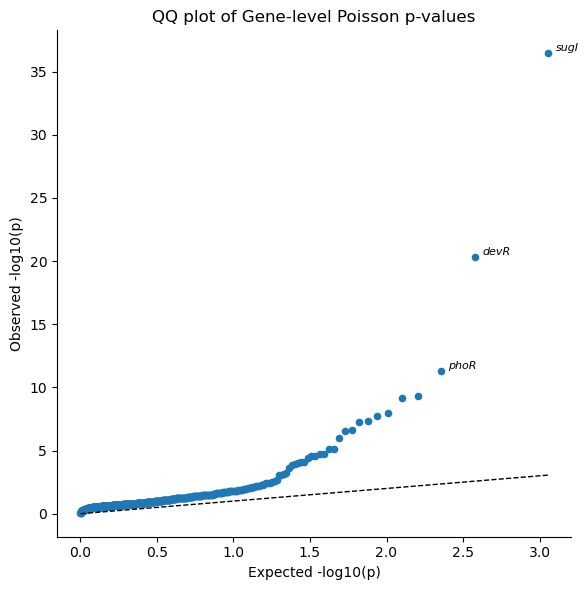

In [257]:
qq_plot_with_labels(df_combined_results.query("Lineage=='Full'"), 
                    gene_col="Gene", 
                    p_label_thresh=1e-10,
                    saveName="../results/figures/pilon_full_set_QQ_plot.svg",
                   )


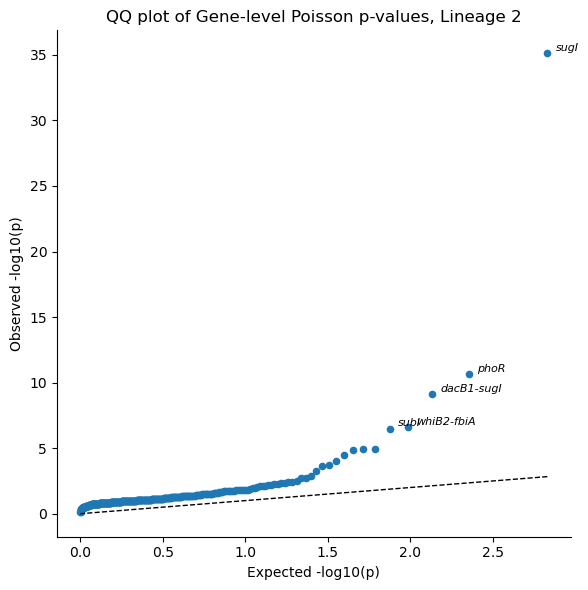

In [258]:
qq_plot_with_labels(df_combined_results.query("Lineage=='2'"), 
                    gene_col="Gene", 
                    p_label_thresh=1e-5,
                    title="QQ plot of Gene-level Poisson p-values, Lineage 2",
                    saveName="../results/figures/pilon_L2_QQ_plot.svg",
                   )


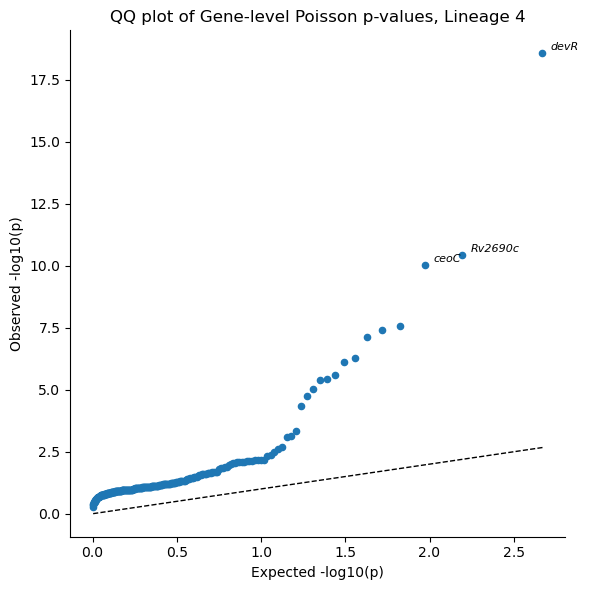

In [259]:
qq_plot_with_labels(df_combined_results.query("Lineage=='4'"), 
                    gene_col="Gene", 
                    p_label_thresh=1e-10,
                    title="QQ plot of Gene-level Poisson p-values, Lineage 4",
                    saveName="../results/figures/pilon_L4_QQ_plot.svg",
                   )


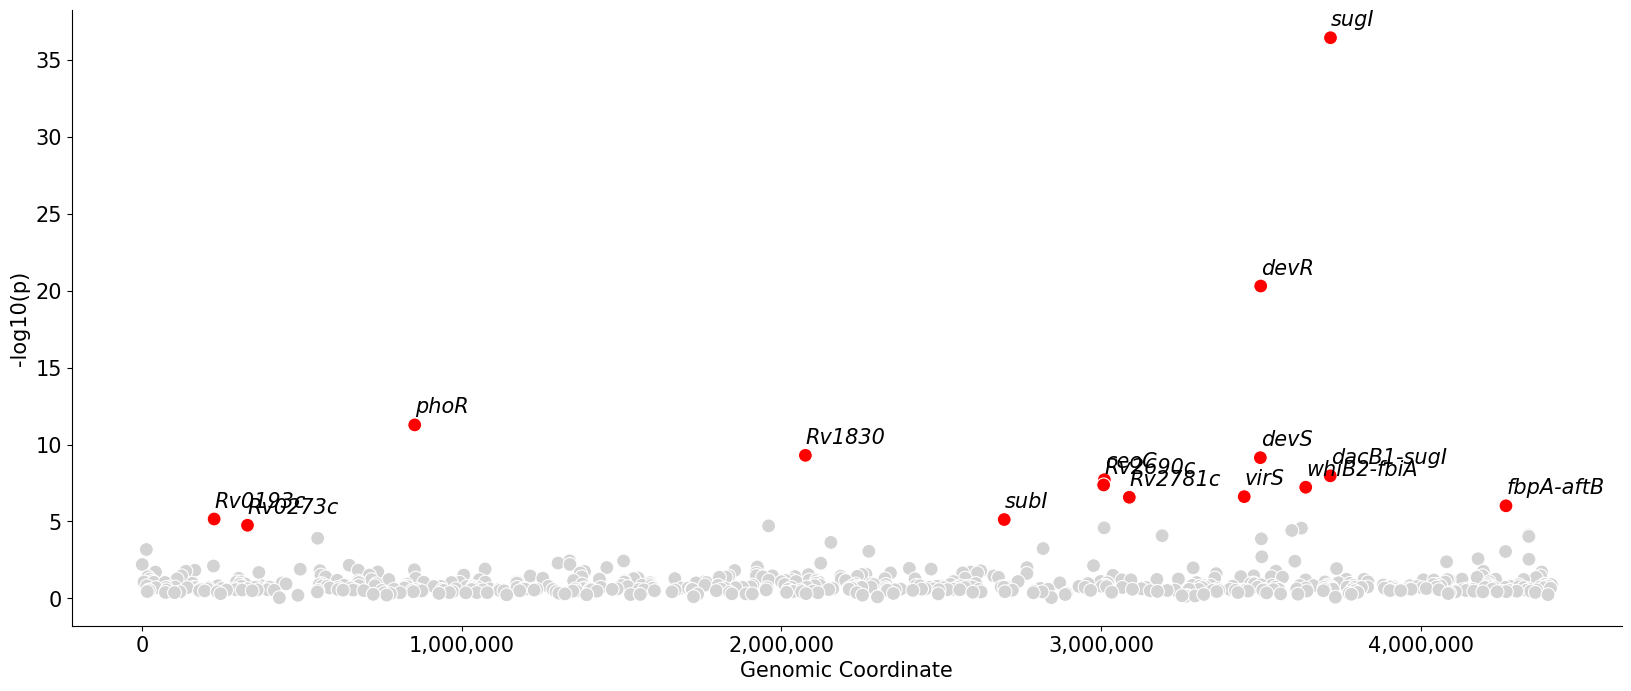

In [260]:
df_combined_results['Midpoint'] = np.mean([df_combined_results['Start'], df_combined_results['End']], axis=0)

y_axis_var = 'Neg_Log_Enrich_pval'
# y_axis_var = 'Fold_Enrichment'
hue_thresh = 1e-2

df_combined_results['Neg_Log_Enrich_pval'] = -np.log10(df_combined_results['Enrich_pval'])

df_combined_results.loc[df_combined_results['Bonferroni_pval'] <= hue_thresh, 'Significant'] = 1
df_combined_results.loc[df_combined_results['Bonferroni_pval'] > hue_thresh, 'Significant'] = 0

font_size = 15

fig, ax = plt.subplots(figsize=(20, 8))

sns.scatterplot(data=df_combined_results.query("Lineage=='Full'"),
                x='Midpoint',
                y=y_axis_var,
                hue='Significant',
                palette={1: 'red', 0: 'lightgray'},
                legend=False,
                ax=ax,
                s=100
               )

for i, row in df_combined_results.query("Lineage=='Full'").query("Significant==1").iterrows():
    
    if 'NC' in row['Gene']:
        name = f"{row['Gene1']}-{row['Gene2']}"
    else:
        name = row['Gene']
    
    plt.text(row['Midpoint']+1000, row[y_axis_var]+0.5, name, fontsize=font_size, ha='left', va='bottom', rotation=0,  style='italic')

# ax.ticklabel_format(style='plain', axis='x')
from matplotlib.ticker import StrMethodFormatter

ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

sns.despine()

ax.set_xticklabels(ax.get_xticklabels(), fontsize=font_size)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=font_size)

plt.xlabel('Genomic Coordinate', fontsize=font_size)
plt.ylabel('-log10(p)', fontsize=font_size)

plt.savefig("../results/figures/pilon_Manhattan_plot_SNVs.svg", bbox_inches='tight')

In [261]:
df_combined_results.query("Gene=='ceoB'")

,Gene,Observed,Expected,Fold_Enrichment,Enrich_pval,Deplete_pval,Twosided_pval,Start,End,Length,Lineage,Bonferroni_pval,Gene1,Gene2,Lineages_Found_In,Midpoint,Neg_Log_Enrich_pval,Significant
16,ceoB,4,0.163296,24.495414,0.000026,0.999999,0.000052,3009344,3010027,684,Full,0.014721,NaN,NaN,"2,4",3009685.5,4.584889,0.0
690,ceoB,1,0.084944,11.772478,0.081436,0.996590,0.162872,3009344,3010027,684,2,1.000000,NaN,NaN,NaN,3009685.5,1.089183,0.0
966,ceoB,3,0.066438,45.154772,0.000047,0.999999,0.000093,3009344,3010027,684,4,0.010882,NaN,NaN,NaN,3009685.5,4.332503,0.0


In [81]:
# df_lowAF_variants_full_for_enrichment_test

In [90]:
whiB2_variant_samples = df_lowAF_variants_full.query("GENE1=='whiB2' & Region.str.contains('NC')")[['pid', 'SampleID', 'Coll2014', 'POS', 'REF', 'ALT', 'AF', 'Region']].SampleID.values

df_lowAF_variants_full.query("GENE1=='whiB2' & Region.str.contains('NC')")[['pid', 'SampleID', 'Coll2014', 'POS', 'REF', 'ALT', 'AF', 'Region']]

,pid,SampleID,Coll2014,POS,REF,ALT,AF,Region
238,T0033,MFS-18,2.2.1,3640256,T,G,0.640212,NC_2516
239,T0033,MFS-18,2.2.1,3640408,T,G,0.293217,NC_2516
262,T0033,MFS-19,2.2.1,3640256,T,G,0.472441,NC_2516
263,T0033,MFS-19,2.2.1,3640408,T,G,0.311659,NC_2516
305,T0263,MFS-274,2.2.1.1,3640256,T,G,0.678700,NC_2516
518,T0069,MFS-348,2.2.1.1,3640407,G,T,0.774118,NC_2516
1122,T0296,MFS-655,4.1.1.3,3640429,C,A,0.139535,NC_2516


In [91]:
Rv1830_variant_samples = df_lowAF_variants_full.query("GENE=='Rv1830'")[['pid', 'SampleID', 'Coll2014', 'POS', 'REF', 'ALT', 'AF', 'Region']].SampleID.values

df_lowAF_variants_full.query("GENE=='Rv1830'")[['pid', 'SampleID', 'Coll2014', 'POS', 'REF', 'ALT', 'AF', 'Region']]

,pid,SampleID,Coll2014,POS,REF,ALT,AF,Region
116,T0235,MFS-144,2.2.1.1,2075037,G,A,0.095436,Rv1830
381,T0278,MFS-296,4.3.3,2075178,T,C,0.100000,Rv1830
675,T0341,MFS-416,4.4.1.1,2075106,T,C,0.266160,Rv1830
868,T0054,MFS-542,4.3.2.1,2075516,T,C,0.324910,Rv1830
875,T0054,MFS-543,4.3.2.1,2075516,T,C,0.755725,Rv1830
958,T0116,MFS-578,2.2.1.1,2075129,G,T,0.788136,Rv1830
1071,T0187,MFS-626,2.2.1,2075518,G,T,0.422111,Rv1830
1121,T0296,MFS-655,4.1.1.3,2075518,G,T,0.137255,Rv1830
1644,T0470,MFS-858,2.2.1,2075516,T,C,0.131034,Rv1830


In [92]:
set(whiB2_variant_samples).intersection(Rv1830_variant_samples)

{'MFS-655'}

In [69]:
df_combined_results.query("Bonferroni_pval <= 1e-2 & Lineage=='Full'")[['Gene', 'Gene1', 'Gene2', 'Observed', 'Bonferroni_pval', 'Lineages_Found_In']].sort_values('Bonferroni_pval')




,Gene,Gene1,Gene2,Observed,Bonferroni_pval,Lineages_Found_In
0,sugI,NaN,NaN,25,1.681120e-34,"2,3,4"
1,devR,NaN,NaN,13,2.562089e-18,"2,3,4"
2,phoR,NaN,NaN,10,2.798360e-09,"2,4"
3,Rv1830,NaN,NaN,7,2.702797e-07,"2,4"
4,devS,NaN,NaN,9,3.805678e-07,"2,3,4"
5,NC_2568,dacB1,sugI,4,5.907776e-06,2
6,ceoC,NaN,NaN,6,1.054838e-05,4
7,Rv2690c,NaN,NaN,8,2.277500e-05,"2,4"
8,NC_2516,whiB2,fbiA,5,3.233526e-05,"2,4"
9,virS,NaN,NaN,6,1.326799e-04,"2,4"


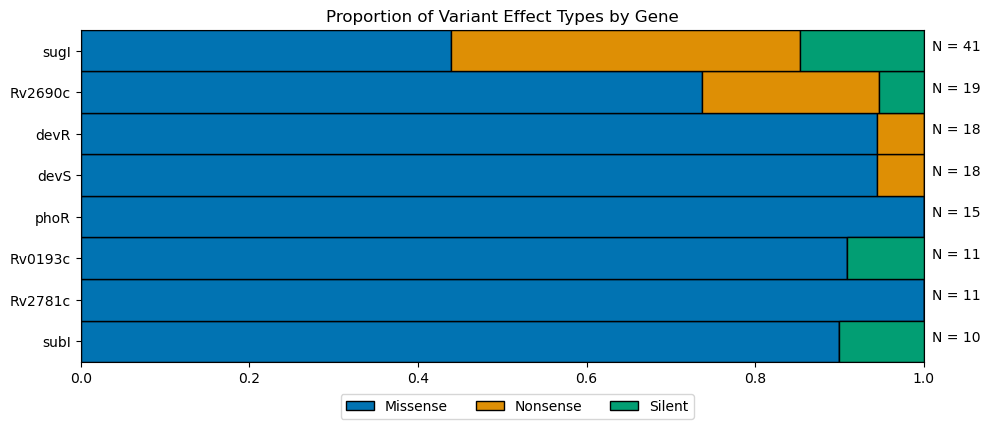

In [108]:
# --- Compute proportions per gene ---
df_lowAF_prop_by_gene = pd.DataFrame(df_lowAF_variants_full[['GENE', 'Variant_Type']].value_counts()).reset_index()
df_lowAF_prop_by_gene['Total'] = df_lowAF_prop_by_gene.groupby('GENE')['count'].transform(lambda x: sum(x))
df_lowAF_prop_by_gene['Proportion'] = df_lowAF_prop_by_gene['count'] / df_lowAF_prop_by_gene['Total']

min_variants = 10

# Pivot to wide format for stacked plotting
df_wide = df_lowAF_prop_by_gene.query("Total >= @min_variants & Variant_Type != 'Intergenic'").pivot(index='GENE', columns='Variant_Type', values='Proportion').fillna(0)

gene_order = df_lowAF_prop_by_gene.query("Total >= @min_variants & Variant_Type != 'Intergenic'").sort_values('Total', ascending=True).GENE.unique()

df_wide = df_wide.loc[gene_order, ]

# --- Plot settings ---
fig, ax = plt.subplots(figsize=(10, 0.55 * len(df_wide)))

n_genes = len(df_wide)
bar_height = 1.0      # full height
y_positions = range(n_genes)

bottom = None

color_palette = dict(zip(df_wide.columns, sns.color_palette("colorblind")[:df_wide.shape[1]]))
variant_totals_by_gene = dict(df_lowAF_prop_by_gene[['GENE', 'Total']].drop_duplicates().values)

for variant_type in df_wide.columns:
    ax.barh(
        y_positions,
        df_wide[variant_type],
        left=bottom,
        height=bar_height,
        label=variant_type,
        edgecolor='black',
        color=color_palette[variant_type]
    )
    bottom = df_wide[variant_type] if bottom is None else bottom + df_wide[variant_type]

for i, gene in enumerate(gene_order):
    ax.text(1.01, i, f"N = {variant_totals_by_gene[gene]}")
    
# --- Formatting ---
ax.set_yticks(y_positions)
ax.set_yticklabels(df_wide.index)

ax.set_title("Proportion of Variant Effect Types by Gene")

ax.legend(title="", bbox_to_anchor=(0.3, -0.075), loc="upper left", ncol=df_wide.shape[1])

# Remove extra space at top & bottom
ax.set_ylim(-0.5, n_genes - 0.5)

plt.tight_layout()
plt.savefig("../overview/figures/lowAF_SNVs_top_protein_coding.svg", bbox_inches='tight')

In [85]:
df_lowAF_variants_full.query("GENE=='phoR'").Coll2014.value_counts()

Coll2014
2.2.1.1    11
4.4.1.1     4
2.2.1       1
Name: count, dtype: int64

In [31]:
df_lowAF_variants_full.query("GENE=='sugI' & Variant_Type=='Nonsense'").Coll2014.value_counts()

Coll2014
2.2.1.1    8
2.2.1      6
4.3.2.1    2
3.1.1      1
Name: count, dtype: int64

In [35]:
df_lowAF_variants_full.query("POS==3717105").Coll2014.value_counts()

Coll2014
2.2.1.1    8
2.2.1      6
4.3.2.1    2
3.1.1      1
Name: count, dtype: int64

In [72]:
df_lowAF_variants_full.query("GENE=='sugI'").HGVS_P.unique()

array(['p.Pro7Thr', 'p.Leu44Leu', 'p.Leu44Met', 'p.Gln6*', 'p.Pro7His',
       'p.Glu37Val', 'p.Leu44Val'], dtype=object)

In [82]:
df_lowAF_variants_full.query("GENE=='sugI'").query("HGVS_P.str.contains('Pro7')")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'SNP', 'HGVS_C', 'HGVS_P', 'AF']]

,pid,SampleID,POS,REF,ALT,SNP,HGVS_C,HGVS_P,AF
41,T0200,MFS-115,3717108,C,A,3717108_C_A,c.19C>A,p.Pro7Thr,0.718147
72,T0220,MFS-129,3717108,C,A,3717108_C_A,c.19C>A,p.Pro7Thr,0.702341
195,T0251,MFS-167,3717108,C,A,3717108_C_A,c.19C>A,p.Pro7Thr,0.100592
562,T0324,MFS-388,3717109,C,A,3717109_C_A,c.20C>A,p.Pro7His,0.612403
737,T0359,MFS-444,3717108,C,A,3717108_C_A,c.19C>A,p.Pro7Thr,0.207048
790,T0378,MFS-471,3717109,C,A,3717109_C_A,c.20C>A,p.Pro7His,0.491409
925,T0081,MFS-563,3717108,C,A,3717108_C_A,c.19C>A,p.Pro7Thr,0.100917
1371,T0384,MFS-777,3717109,C,A,3717109_C_A,c.20C>A,p.Pro7His,0.197802
1458,T0425,MFS-807,3717109,C,A,3717109_C_A,c.20C>A,p.Pro7His,0.157647
1723,T0264,MFS-880,3717108,C,A,3717108_C_A,c.19C>A,p.Pro7Thr,0.501754


# Unfixed Resistance-Associated Mutations (Indels and LoFs too)

In [ ]:
cc_df.query("Drug=='Isoniazid' & Medium in ['MGIT', '7H10']")

In [37]:
df_lowAF_variants['variant'] = df_lowAF_variants['GENE'] + '_' + df_lowAF_variants['HGVS_P']

df_lowAF_variants.loc[(df_lowAF_variants['Variant_Type'] == 'Silent'), 'variant'] = df_lowAF_variants.loc[(df_lowAF_variants['Variant_Type'] == 'Silent')]['GENE'] + '_' + df_lowAF_variants.loc[(df_lowAF_variants['Variant_Type'] == 'Silent')]['HGVS_C']

In [48]:
INH_R_samples = df_trust_patients.drop_duplicates(subset='pid').query("(s_inhmic_sputum_specimen_1 > 3 & s_inhmicmeth_sputum_specimen_1==2) | (s_inhmic_sputum_specimen_1 > 4 & s_inhmicmeth_sputum_specimen_1==3)").pid.unique()

len(INH_R_samples)

28

In [49]:
EMB_R_samples = df_trust_patients.drop_duplicates(subset='pid').query("s_embmic_sputum_specimen_1 >= 5").pid.unique()

len(EMB_R_samples)

2

In [50]:
PZA_R_samples = df_trust_patients.drop_duplicates(subset='pid').query("s_pzamic_sputum_specimen_1 >= 5").pid.unique()

len(PZA_R_samples)

2

In [51]:
missing_INH = list(set(INH_R_samples) - set(isolate_variants.query("confidence in ['1) Assoc w R', '2) Assoc w R - Interim'] & SampleID in @df_trust_patients.SampleID & drug=='Isoniazid'").pid))
len(missing_INH)

12

In [52]:
missing_EMB = list(set(EMB_R_samples) - set(isolate_variants.query("confidence in ['1) Assoc w R', '2) Assoc w R - Interim'] & SampleID in @df_trust_patients.SampleID & drug=='Ethambutol'").pid))
len(missing_EMB)

1

In [53]:
missing_PZA = list(set(PZA_R_samples) - set(isolate_variants.query("confidence in ['1) Assoc w R', '2) Assoc w R - Interim'] & SampleID in @df_trust_patients.SampleID & drug=='Pyrazinamide'").pid))
len(missing_PZA)

2

In [28]:
def get_unfixed_resistance_associated_mutations(sample):
    
    fName = f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.excludeLowConf.tsv"

    silent_lst = ['synonymous_variant', 'initiator_codon_variant', 'stop_retained_variant', 'intergenic_region']
    LoF_lst = ['frameshift', 'ablation', 'start_lost', 'stop_gained']
    drugs_lst = ['Rifampicin', 'Isoniazid', 'Ethambutol', 'Pyrazinamide']
    
    promoter_sites = df_who_variants.query("effect=='upstream_gene_variant'")['genomic position'].unique().astype(int)

    df_single_sample_variants = pd.read_csv(fName, sep='\t', on_bad_lines='skip')
    df_single_sample_variants['AF'] = df_single_sample_variants['AO'] / df_single_sample_variants['DP']

    for col in df_single_sample_variants.columns:
        if 'ANN' in col:
            df_single_sample_variants.rename(columns={col: col.split('.')[-1]}, inplace=True)

    df_single_sample_variants['variant'] = df_single_sample_variants['GENE'] + '_' + df_single_sample_variants['HGVS_P']

    df_single_sample_variants.loc[df_single_sample_variants['ANN'].str.contains('|'.join(silent_lst)), 'variant'] = df_single_sample_variants.loc[df_single_sample_variants['ANN'].str.contains('|'.join(silent_lst))]['GENE'] + '_' + df_single_sample_variants.loc[df_single_sample_variants['ANN'].str.contains('|'.join(silent_lst))]['HGVS_C']

    df_single_sample_variants.loc[df_single_sample_variants['ANN'].str.contains('|'.join(LoF_lst)), 'variant'] = df_single_sample_variants.loc[df_single_sample_variants['ANN'].str.contains('|'.join(LoF_lst))]['GENE'] + '_' + 'LoF'

    df_single_sample_variants = df_single_sample_variants.merge(df_who_variants[['variant', 'drug', 'FINAL CONFIDENCE GRADING', 'Present_SOLO_S', 'Present_SOLO_R', 'OR_SOLO', 'Present_S', 'Present_R']], on='variant', how='left').rename(columns={'FINAL CONFIDENCE GRADING': 'confidence'})

    df_single_sample_variants['SampleID'] = sample
    
    return df_single_sample_variants.query("AF >= 0.05 & AF <= 0.95") #.query("OR_SOLO > 1 | POS in @promoter_sites").query("AF >= 0.05 & AF <= 0.95 & drug in @drugs_lst")

In [61]:
WHO_regions = df_who_variants.gene.unique()
WHO_resistance_regions = df_who_variants.loc[df_who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].gene.unique()

df_lowAF_variants_WHO_annot = df_lowAF_variants.query("Variant_Type != 'Silent'").merge(df_who_variants, how='left', on='variant')

In [70]:
df_lowAF_variants_WHO_annot.query("Region in @WHO_regions")

,POS,REF,ALT,QUAL,GENE,HGVS_C,HGVS_P,NS,DP,DPB,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
2,764924,G,A,3.200000e-14,rpoC,c.1555G>A,p.Gly519Ser,1,218,218.0000,...,NaN,3) Uncertain significance,NaN,New Uncertain,NaN,NaN,no,NaN,NaN,0.0
6,689,C,T,3.417360e-14,dnaA,c.689C>T,p.Pro230Leu,1,318,318.0000,...,NaN,3) Uncertain significance,NaN,New Uncertain,NaN,NaN,no,NaN,NaN,0.0
31,3626989,G,A,4.300000e-15,mtrA,c.361C>T,p.Arg121Cys,1,307,307.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,3627349,T,C,4.200000e-14,mtrA,c.1A>G,p.Met1?,1,434,434.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
107,3626075,A,G,3.400000e-14,mtrB,c.539T>C,p.Leu180Pro,1,260,260.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
182,775917,A,G,0.000000e+00,mmpL5,c.2564T>C,p.Val855Ala,1,306,306.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
259,2288760,G,A,2.000000e-14,pncA,c.482C>T,p.Ala161Val,1,313,313.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
308,2155174,A,G,8.700000e-14,katG,c.938T>C,p.Ile313Thr,1,345,345.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
323,3612504,G,A,4.600000e-14,Rv3236c,c.613C>T,p.His205Tyr,1,270,270.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
324,3612504,G,A,3.300000e-14,Rv3236c,c.613C>T,p.His205Tyr,1,290,290.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [72]:
df_lowAF_variants_WHO_annot.query("Region=='katG'")

,POS,REF,ALT,QUAL,GENE,HGVS_C,HGVS_P,NS,DP,DPB,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
308,2155174,A,G,8.700000e-14,katG,c.938T>C,p.Ile313Thr,1,345,345.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,2153995,G,T,0.000000e+00,katG,c.2117C>A,p.Ala706Glu,1,281,281.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,2154800,A,G,6.300000e-14,katG,c.1312T>C,p.Trp438Arg,1,317,317.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365,2155667,A,G,2.400000e-14,katG,c.445T>C,p.Trp149Arg,1,269,269.0,...,NaN,3) Uncertain significance,NaN,No change,AwRI by relaxed thresholds (not endorsed),NaN,yes,NaN,O,1.0
366,2155819,T,C,0.000000e+00,katG,c.293A>G,p.Tyr98Cys,1,257,257.0,...,NaN,3) Uncertain significance,NaN,No change,AwRI by relaxed thresholds (not endorsed),NaN,yes,NaN,O,1.0


In [68]:
df_lowAF_variants_WHO_annot.query("Region=='pncA'")

,POS,REF,ALT,QUAL,GENE,HGVS_C,HGVS_P,NS,DP,DPB,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
259,2288760,G,A,2.000000e-14,pncA,c.482C>T,p.Ala161Val,1,313,313.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
df_lowAF_variants.query("Region=='katG'")

,POS,REF,ALT,QUAL,GENE,HGVS_C,HGVS_P,NS,DP,DPB,...,False_in_all_Ground_Truth_Samples,predicted,pred_class,Sampling_Week,SNP,Region,Variant_Type,REF_AA,ALT_AA,variant
401,2155174,A,G,8.700000e-14,katG,c.938T>C,p.Ile313Thr,1,345,345.0,...,0.0,0.998321,1.0,1,2155174_A_G,katG,Missense,Ile,Thr,katG_p.Ile313Thr
474,2153995,G,T,0.000000e+00,katG,c.2117C>A,p.Ala706Glu,1,281,281.0,...,0.0,0.999482,1.0,1,2153995_G_T,katG,Missense,Ala,Glu,katG_p.Ala706Glu
475,2154800,A,G,6.300000e-14,katG,c.1312T>C,p.Trp438Arg,1,317,317.0,...,0.0,0.996060,1.0,1,2154800_A_G,katG,Missense,Trp,Arg,katG_p.Trp438Arg
476,2155667,A,G,2.400000e-14,katG,c.445T>C,p.Trp149Arg,1,269,269.0,...,0.0,0.999864,1.0,1,2155667_A_G,katG,Missense,Trp,Arg,katG_p.Trp149Arg
477,2155819,T,C,0.000000e+00,katG,c.293A>G,p.Tyr98Cys,1,257,257.0,...,0.0,0.998626,1.0,1,2155819_T_C,katG,Missense,Tyr,Cys,katG_p.Tyr98Cys


In [45]:
df_lowAF_variants.query("Region in @WHO_resistance_regions").query("Region in ['gyrB', 'gyrA']")

,POS,REF,ALT,QUAL,GENE,HGVS_C,HGVS_P,NS,DP,DPB,...,False_in_all_Ground_Truth_Samples,predicted,pred_class,Sampling_Week,SNP,Region,Variant_Type,REF_AA,ALT_AA,variant
709,6923,T,G,0.0,gyrB,c.1684T>G,p.Phe562Val,1,350,350.000,...,0.0,0.999208,1.0,1,6923_T_G,gyrB,Missense,Phe,Val,gyrB_p.Phe562Val
712,6923,T,G,0.0,gyrB,c.1684T>G,p.Phe562Val,1,347,347.000,...,0.0,0.999586,1.0,9,6923_T_G,gyrB,Missense,Phe,Val,gyrB_p.Phe562Val
853,6078,G,T,0.0,gyrB,c.839G>T,p.Gly280Val,1,388,388.000,...,0.0,0.995078,1.0,6,6078_G_T,gyrB,Missense,Gly,Val,gyrB_p.Gly280Val
1242,6608,G,C,13022.0,gyrB,c.1369G>C,p.Val457Leu,1,387,392.667,...,0.0,0.999749,1.0,1,6608_G_C,gyrB,Missense,Val,Leu,gyrB_p.Val457Leu
1250,6608,G,C,14237.2,gyrB,c.1369G>C,p.Val457Leu,1,448,454.333,...,0.0,0.999818,1.0,5,6608_G_C,gyrB,Missense,Val,Leu,gyrB_p.Val457Leu


In [46]:
df_who_variants.query("variant in ['gyrB_p.Phe562Val', 'gyrB_p.Gly280Val', 'gyrB_p.Val457Leu']")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
30280,Levofloxacin,gyrB,p.Val457Leu,gyrB_p.Val457Leu,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,19.0,1.0,...,NaN,3) Uncertain significance,NaN,No change,NaN,NaN,no,NaN,NaN,1
34083,Moxifloxacin,gyrB,p.Val457Leu,gyrB_p.Val457Leu,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,8.0,1.0,...,NaN,3) Uncertain significance,NaN,No change,NaN,NaN,no,NaN,NaN,1


In [58]:
INH_unfixed_muts = []
INH_genes = df_who_variants.query("drug=='Isoniazid'").gene.unique()

for pid in missing_INH:
    
    for sample in df_trust_patients.query("pid==@pid").SampleID.unique():
        INH_unfixed_muts.append(get_unfixed_resistance_associated_mutations(sample))
        
INH_unfixed_muts = pd.concat(INH_unfixed_muts).merge(df_trust_patients[['pid', 'SampleID']])

INH_unfixed_muts.query("GENE.str.contains('|'.join(@INH_genes))")

,POS,REF,ALT,QUAL,FILTER,GENE,HGVS_C,HGVS_P,NS,DP,...,variant,drug,confidence,Present_SOLO_S,Present_SOLO_R,OR_SOLO,Present_S,Present_R,SampleID,pid
75,576093,C,G,0.000000e+00,NaN,mshA,c.746C>G,p.Pro249Arg,1,102,...,mshA_p.Pro249Arg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MFS-151,T0242
117,472711,T,TTTGTGGGCC,1.800000e+03,NaN,ndhA-Rv0393,n.472711_472712insTTGTGGGCC,NaN,1,129,...,ndhA-Rv0393_n.472711_472712insTTGTGGGCC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MFS-486,T0393
145,1406760,T,TG,5.700000e+03,NaN,Rv1258c,c.580_581insC,p.Glu194fs,1,209,...,Rv1258c_LoF,Isoniazid,3) Uncertain significance,4043.0,178.0,0.0816,5293.0,8886.0,MFS-486,T0393
146,1406760,T,TG,5.700000e+03,NaN,Rv1258c,c.580_581insC,p.Glu194fs,1,209,...,Rv1258c_LoF,Pyrazinamide,3) Uncertain significance,2512.0,227.0,0.5108,3093.0,1980.0,MFS-486,T0393
147,1406760,T,TG,5.700000e+03,NaN,Rv1258c,c.580_581insC,p.Glu194fs,1,209,...,Rv1258c_LoF,Streptomycin,3) Uncertain significance,2810.0,132.0,0.1101,3353.0,5140.0,MFS-486,T0393
224,1849,C,A,6.177100e+03,NaN,dnaA-dnaN,n.1849C>A,NaN,1,249,...,dnaA-dnaN_n.1849C>A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MFS-485,T0393
363,472711,T,TTTGTGGGCC,1.500000e+03,NaN,ndhA-Rv0393,n.472711_472712insTTGTGGGCC,NaN,1,117,...,ndhA-Rv0393_n.472711_472712insTTGTGGGCC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MFS-485,T0393
391,575907,C,T,5.200000e+03,NaN,mshA,c.560C>T,p.Ala187Val,1,201,...,mshA_p.Ala187Val,Ethionamide,5) Not assoc w R,3001.0,108.0,0.1305,4517.0,2187.0,MFS-485,T0393
392,575907,C,T,5.200000e+03,NaN,mshA,c.560C>T,p.Ala187Val,1,201,...,mshA_p.Ala187Val,Isoniazid,5) Not assoc w R,0.0,0.0,NaN,4835.0,8244.0,MFS-485,T0393
592,1406760,T,TG,4.500000e+03,NaN,Rv1258c,c.580_581insC,p.Glu194fs,1,182,...,Rv1258c_LoF,Isoniazid,3) Uncertain significance,4043.0,178.0,0.0816,5293.0,8886.0,MFS-485,T0393


In [55]:
EMB_unfixed_muts = []
EMB_genes = df_who_variants.query("drug=='Ethambutol'").gene.unique()

for pid in missing_EMB:
    
    for sample in df_trust_patients.query("pid==@pid").SampleID.unique():
        EMB_unfixed_muts.append(get_unfixed_resistance_associated_mutations(sample))
        
EMB_unfixed_muts = pd.concat(EMB_unfixed_muts).merge(df_trust_patients[['pid', 'SampleID']])

EMB_unfixed_muts.query("GENE.str.contains('|'.join(@EMB_genes))")

,POS,REF,ALT,QUAL,FILTER,GENE,HGVS_C,HGVS_P,NS,DP,...,variant,drug,confidence,Present_SOLO_S,Present_SOLO_R,OR_SOLO,Present_S,Present_R,SampleID,pid


In [238]:
PZA_unfixed_muts = []
PZA_genes = df_who_variants.query("drug=='Pyrazinamide'").gene.unique()

for pid in missing_PZA:
    
    for sample in df_trust_patients.query("pid==@pid").SampleID.unique():
        PZA_unfixed_muts.append(get_unfixed_resistance_associated_mutations(sample))
        
PZA_unfixed_muts = pd.concat(PZA_unfixed_muts).merge(df_trust_patients[['pid', 'SampleID']])

PZA_unfixed_muts.query("GENE.str.contains('|'.join(@PZA_genes))")

,POS,REF,ALT,QUAL,FILTER,GENE,HGVS_C,HGVS_P,NS,DP,...,variant,drug,confidence,Present_SOLO_S,Present_SOLO_R,OR_SOLO,OR_SOLO_exact_lb,OR_SOLO_exact_ub,SampleID,pid


In [70]:
isolate_variants.query("confidence in ['1) Assoc w R', '2) Assoc w R - Interim'] & SampleID in @df_trust_patients.SampleID & drug=='Isoniazid'").AF.min()

np.float64(0.56)

In [23]:
isolate_variants.query("confidence in ['1) Assoc w R', '2) Assoc w R - Interim'] & SampleID in @df_trust_patients.SampleID").drop_duplicates(subset=['SampleID', 'variant']).query("drug in ['Ethambutol', 'Pyrazinamide']")

,SampleID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
18389,MFS-533,4247429,A,G,PASS,8303.0,False,1.0,246.0,34.0,60.0,0.0,0.0,missense_variant,embB,c.916A>G,p.Met306Val,embB_p.Met306Val,Ethambutol,1) Assoc w R
18448,MFS-534,4247429,A,G,PASS,8045.0,False,1.0,238.0,34.0,60.0,0.0,0.0,missense_variant,embB,c.916A>G,p.Met306Val,embB_p.Met306Val,Ethambutol,1) Assoc w R
23288,MFS-637,2289202,A,G,PASS,8287.0,False,1.0,246.0,34.0,60.0,0.0,0.0,missense_variant,pncA,c.40T>C,p.Cys14Arg,pncA_p.Cys14Arg,Pyrazinamide,1) Assoc w R


In [ ]:
# 4 = 0.125-0.25 
df_trust_patients.query("pid in ['T0186']")[['pid', 's_rifmic_sputum_specimen_1', 's_rifmic_sputum_specimen_2']]

,pid,s_rifmic_sputum_specimen_1,s_rifmic_sputum_specimen_2
582,T0186,4.0,NaN
583,T0186,4.0,NaN


In [335]:
df_trust_patients.query("pid=='T0186'")[['pid', 's_rifmic_sputum_specimen_1']]

,pid,s_rifmic_sputum_specimen_1
582,T0186,4.0
583,T0186,4.0


In [193]:
# 2 = 0.6-1.25
df_trust_patients.query("pid in ['T0352', 'T0278']")[['pid', 's_embmic_sputum_specimen_1', 's_embmic_sputum_specimen_2']]

,pid,s_embmic_sputum_specimen_1,s_embmic_sputum_specimen_2
540,T0352,2.0,NaN
541,T0352,2.0,NaN
783,T0278,2.0,NaN
784,T0278,2.0,NaN


In [173]:
df_lowAF_variants_WHO = df_lowAF_variants[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'GENE', 'HGVS_C', 'HGVS_P', 'variant']].merge(df_who_variants.query("tier==1")[['variant', 'drug', 'FINAL CONFIDENCE GRADING']], on='variant', how='left')

df_lowAF_variants_WHO['FINAL CONFIDENCE GRADING'].value_counts()

FINAL CONFIDENCE GRADING
3) Uncertain significance     7
4) Not assoc w R - Interim    1
Name: count, dtype: int64

In [196]:
df_lowAF_variants_WHO.query("GENE=='embA'")#.dropna(subset='FINAL CONFIDENCE GRADING')

,pid,SampleID,POS,REF,ALT,AF,GENE,HGVS_C,HGVS_P,variant,drug,FINAL CONFIDENCE GRADING
438,T0278,MFS-296,4246040,C,T,0.120805,embA,c.2808C>T,p.Ala936Ala,embA_c.2808C>T,NaN,NaN
613,T0352,MFS-433,4244674,A,G,0.176030,embA,c.1442A>G,p.Glu481Gly,embA_p.Glu481Gly,NaN,NaN


In [176]:
df_who_variants.query("variant=='gyrB_p.Val457Leu'")[['drug', 'Present_SOLO_S', 'Present_SOLO_R']]

,drug,Present_SOLO_S,Present_SOLO_R
30280,Levofloxacin,18.0,1.0
34083,Moxifloxacin,7.0,1.0


# Changes in Unfixed Variants

In [29]:
def convert_variants_to_matrices(df_variants, variant_col, baseline_only=False):
    
    variant_matrix = []

    # fixed_AF_thresh = 1.2
    
    # baseline samples only, so if the column isn't there, assign 1. If doing longitudinal analysis, the Paired_Sample_Num column needs to be added before!
    if baseline_only and 'Paired_Sample_Num' not in df_variants.columns:
        df_variants['Paired_Sample_Num'] = 1

    # use df_lowAF_variants because the signal for low frequency variants gets drowned out by tons of fixed SNPs
    for pid in df_variants.pid.unique():

        single_pid_matrix = df_variants.query("pid==@pid").pivot(index='Paired_Sample_Num', columns=variant_col, values='AF')
        
        single_pid_matrix.index = pid + '_' + single_pid_matrix.index.astype(str)

        # variant_matrix.append(single_pid_matrix[keep_variants])
        variant_matrix.append(single_pid_matrix)

    variant_matrix = pd.concat(variant_matrix).fillna(0)

    sample_1_variants = variant_matrix.loc[variant_matrix.index.str.endswith('_1')]
    
    # remove the suffixes from the indexes
    sample_1_variants.index = sample_1_variants.index.str.split('_').str[0]
    
    if not baseline_only:
        sample_2_variants = variant_matrix.loc[variant_matrix.index.str.endswith('_2')]
        sample_2_variants.index = sample_2_variants.index.str.split('_').str[0]    

        # make sure they have the same samples
        all_pids = np.sort(list(set(sample_1_variants.index).union(sample_2_variants.index)))

        missing_pids_sample1 = list(set(all_pids) - set(sample_1_variants.index))
        missing_pids_sample2 = list(set(all_pids) - set(sample_2_variants.index))

        sample_1_variants = pd.concat([sample_1_variants,
                                   pd.DataFrame(index=missing_pids_sample1, columns=sample_1_variants.columns).fillna(0)
                                  ]).loc[all_pids]

        sample_2_variants = pd.concat([sample_2_variants,
                                   pd.DataFrame(index=missing_pids_sample2, columns=sample_2_variants.columns).fillna(0)
                                  ]).loc[all_pids]

        variant_differences = sample_2_variants - sample_1_variants
        print(variant_differences.shape)

        return sample_1_variants, sample_2_variants, variant_differences
    
    else:
        print(sample_1_variants.shape)
        return sample_1_variants

In [307]:
# for analyzing variant changes because unfixed --> fixed and vice versa are important to see
sample_1_SNVs, sample_2_SNVs, SNV_differences = convert_variants_to_matrices(df_variants, 'SNP')

# for analyzing variant changes because unfixed --> fixed and vice versa are important to see
sample_1_SNVs_baseline = convert_variants_to_matrices(df_variants_baseline, 'SNP', baseline_only=True)

sample_1_unfixed_SNVs, sample_2_unfixed_SNVs, unfixed_SNV_differences = convert_variants_to_matrices(df_lowAF_variants, 'SNP')

(286, 11737)
(395, 13553)
(250, 1094)


In [216]:
nonzero_vals_1 = sample_1_unfixed_SNVs.values.flatten()
nonzero_vals_1 = nonzero_vals_1[(nonzero_vals_1 >= 0.05) & (nonzero_vals_1 <= 0.95)]

nonzero_vals_2 = sample_2_unfixed_SNVs.values.flatten()
nonzero_vals_2 = nonzero_vals_2[(nonzero_vals_2 >= 0.05) & (nonzero_vals_2 <= 0.95)]

len(nonzero_vals_1), len(nonzero_vals_2)

(626, 744)

In [217]:
np.mean(nonzero_vals_1), np.mean(nonzero_vals_2)

(0.32698621597454, 0.32999114749803143)

In [218]:
st.mannwhitneyu(nonzero_vals_1,
                nonzero_vals_2,
                alternative='greater'
               )

MannwhitneyuResult(statistic=231532.0, pvalue=0.5729014883096908)

In [15]:
df_split_genes = df_variants['Region'].str.split(',', expand=True)
assert df_split_genes.shape[1] == 2 # only at most 2 genes overlapping a single site
df_split_genes.columns = [f"GENE{i+1}" for i in np.arange(df_split_genes.shape[1])]

df_variants = pd.concat([df_variants, df_split_genes], axis=1)

In [168]:
def compute_nonsilent_variant_changes(gene, df_variants, SNV_differences, diff_min = 0.05):
        
    search_SNVs = df_variants.loc[(df_variants['GENE']==gene) | (df_variants['GENE1']==gene) | (df_variants['GENE2']==gene)].query("Variant_Type not in ['Silent', 'Intergenic']").SNP.unique()

    search_search_SNVs_long = SNV_differences[search_SNVs].reset_index().melt(id_vars='index').rename(columns={'index': 'pid'})

    search_search_SNVs_long = search_search_SNVs_long.merge(df_variants[['SNP', 'GENE', 'HGVS_P', 'Variant_Type']].drop_duplicates(), how='left')
    
    diff_max = 1 - diff_min

    num_increase = len(search_search_SNVs_long.query("(value >= @diff_min & value <= @diff_max) | (value >= -@diff_max & value <= -@diff_min)").query("value > 0"))
    num_decrease = len(search_search_SNVs_long.query("(value >= @diff_min & value <= @diff_max) | (value >= -@diff_max & value <= -@diff_min)").query("value < 0"))
    
    increase_pids = search_search_SNVs_long.query("(value >= @diff_min & value <= @diff_max) | (value >= -@diff_max & value <= -@diff_min)").query("value > 0").pid.unique()
    decrease_pids = search_search_SNVs_long.query("(value >= @diff_min & value <= @diff_max) | (value >= -@diff_max & value <= -@diff_min)").query("value < 0").pid.unique()
    
    increase_pval = st.wilcoxon(search_search_SNVs_long.query("(value >= @diff_min & value <= @diff_max) | (value >= -@diff_max & value <= -@diff_min)")['value'],
                                alternative='greater'
                                ).pvalue
    
    decrease_pval = st.wilcoxon(search_search_SNVs_long.query("(value >= @diff_min & value <= @diff_max) | (value >= -@diff_max & value <= -@diff_min)")['value'],
                                alternative='less'
                                ).pvalue
    
    return search_search_SNVs_long.query("(value >= @diff_min & value <= @diff_max) | (value >= -@diff_max & value <= -@diff_min)")['value'].mean(), increase_pval, decrease_pval, num_increase, num_decrease, increase_pids, decrease_pids

In [169]:
# df_variants[['GENE1', 'GENE2']] = df_variants['Region'].str.split(',', expand=True)


In [156]:
# gene = 'whiB6'
# df_variants.query("GENE2==@gene | GENE1==@gene | GENE==@gene")[['Coll2014', 'Lineage']]

In [102]:
# search_genes = [['phoR', 'phoP'], ['devS', 'devR', 'dosT'], ['sugI'], ['virS'], ['subI'], ['mbtE'], ['ceoB', 'ceoC'], ['Rv2690c']]
search_genes = df_variants.query("Variant_Type not in ['Silent', 'Intergenic']").GENE.unique()

df_change_pvals = pd.DataFrame(columns = ['Gene', 'Avg_Change', 'Increase_pval', 'Decrease_pval', 'Num_Increase', 'Num_Decrease'])

for i, gene in enumerate(search_genes):
    
    avg_change, increase_pval, decrease_pval, num_increase, num_decrease, _, _ = compute_nonsilent_variant_changes(gene, df_variants, SNV_differences)
    df_change_pvals.loc[i, :] = [gene, avg_change, increase_pval, decrease_pval, num_increase, num_decrease]
    
    if i % 100 == 0:
        print(i)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700


In [126]:
# new
pval_thresh = 0.1
df_change_pvals.query("Increase_pval <= @pval_thresh | Decrease_pval <= @pval_thresh")

,Gene,Avg_Change,Increase_pval,Decrease_pval,Num_Increase,Num_Decrease
280,Rv1733c,-0.162605,1.0,0.0625,0,4
302,katG,-0.172745,1.0,0.03125,0,5
499,sugI,-0.131959,0.954718,0.047694,10,17
1334,whiB6,-0.176696,1.0,0.0625,0,4


In [184]:
for gene in ['Rv1733c', 'katG', 'sugI', 'whiB6']:
    _, _, _, _, _, increase_pids, decrease_pids = compute_nonsilent_variant_changes(gene, df_variants, SNV_differences)
    # print(gene, increase_pids, decrease_pids)
    print(gene, df_trust_patients.query("pid in @decrease_pids")[['pid', 'Coll2014', 'Lineage', 'F2']].drop_duplicates(subset='pid').Coll2014.value_counts())

Rv1733c Coll2014
3.1.1      2
4.3.2.1    1
2.2.1      1
Name: count, dtype: int64
katG Coll2014
2.2.1.1    1
2.2.1      1
Name: count, dtype: int64
sugI Coll2014
2.2.1.1    8
2.2.1      6
4.3.2.1    2
4.1.1.1    1
Name: count, dtype: int64
whiB6 Coll2014
2.2.1.1    1
2.2.1      1
Name: count, dtype: int64


In [180]:
df_trust_patients.query("pid in ['T0219', 'T0222', 'T0324', 'T0328']")[['pid', 'Coll2014', 'Lineage', 'F2']].drop_duplicates(subset='pid')

,pid,Coll2014,Lineage,F2
133,T0222,4.3.2.1,4.0,0.009735
529,T0324,2.2.1,2,0.010747
549,T0328,3.1.1,3,0.012999
742,T0219,3.1.1,3,0.013948


In [ ]:
df_trust_patients.query("pid in ['T0219', 'T0222', 'T0324', 'T0328']")[['pid', 'Coll2014', 'Lineage', 'F2']].drop_duplicates(subset='pid')

In [128]:
df_change_pvals.query("Num_Increase==0 & Num_Decrease >= 3").sort_values('Decrease_pval', ascending=False)

,Gene,Avg_Change,Increase_pval,Decrease_pval,Num_Increase,Num_Decrease
890,cdsA,-0.505477,1.0,0.125,0,3
1330,mtrA,-0.260112,1.0,0.125,0,3
1406,virS,-0.301829,1.0,0.125,0,3
2711,Rv3861,-0.191736,1.0,0.125,0,3
280,Rv1733c,-0.162605,1.0,0.0625,0,4
1334,whiB6,-0.176696,1.0,0.0625,0,4
302,katG,-0.172745,1.0,0.03125,0,5


In [26]:
df_change_pvals.query("Num_Decrease==0 & Num_Increase >= 2").sort_values('Increase_pval', ascending=False)

,Gene,Avg_Change,Increase_pval,Decrease_pval,Num_Increase,Num_Decrease
170,kdpD,0.260639,0.25,1.0,2,0
1152,mmpL11,0.254751,0.25,1.0,2,0
1944,PPE6,0.375258,0.25,1.0,2,0
1715,fadD16,0.091146,0.25,1.0,2,0
1657,mhpE,0.129614,0.25,1.0,2,0
1655,lpqW,0.073733,0.25,1.0,2,0
1309,acrA1,0.287313,0.25,1.0,2,0
1263,Rv2345,0.637268,0.25,1.0,2,0
984,lprD,0.443226,0.25,1.0,2,0
196,fadD6,0.070346,0.25,1.0,2,0


In [67]:
gene = 'whiB6'
search_SNVs = df_variants.loc[(df_variants['GENE']==gene) | (df_variants['GENE1']==gene) | (df_variants['GENE2']==gene)].query("Variant_Type not in ['Silent', 'Intergenic']").SNP.unique()

search_search_SNVs_long = SNV_differences[search_SNVs].reset_index().melt(id_vars='index').rename(columns={'index': 'pid'})

search_search_SNVs_long = search_search_SNVs_long.merge(df_variants[['SNP', 'GENE', 'HGVS_P', 'Variant_Type', 'ANN']].drop_duplicates(), how='left')

diff_min = 0.05
diff_max = 1 - diff_min

search_search_SNVs_long.query("(value >= @diff_min & value <= @diff_max) | (value >= -@diff_max & value <= -@diff_min)")

,pid,SNP,value,GENE,HGVS_P,Variant_Type,ANN
1272,T0217,4338238_A_C,-0.242775,Rv3861,p.Gln98Pro,Missense,C|missense_variant|MODERATE|Rv3861|Rv3861|tran...
1557,T0217,4338301_C_G,-0.131579,whiB6,p.Gly74Ala,Missense,G|missense_variant|MODERATE|whiB6|Rv3862c|tran...
1989,T0470,4338238_A_G,-0.170270,Rv3861,p.Gln98Arg,Missense,G|missense_variant|MODERATE|Rv3861|Rv3861|tran...
2274,T0470,4338250_G_C,-0.162162,Rv3861,p.Arg102Pro,Missense,C|missense_variant|MODERATE|Rv3861|Rv3861|tran...


In [68]:
search_search_SNVs_long.query("(value >= @diff_min & value <= @diff_max) | (value >= -@diff_max & value <= -@diff_min)").ANN.values

array(['C|missense_variant|MODERATE|Rv3861|Rv3861|transcript|CCP46690|protein_coding|1/1|c.293A>C|p.Gln98Pro|293/327|293/327|98/108||WARNING_TRANSCRIPT_NO_START_CODON,C|missense_variant|MODERATE|whiB6|Rv3862c|transcript|CCP46691|protein_coding|1/1|c.284T>G|p.Leu95Arg|284/351|284/351|95/116||',
       'G|missense_variant|MODERATE|whiB6|Rv3862c|transcript|CCP46691|protein_coding|1/1|c.221G>C|p.Gly74Ala|221/351|221/351|74/116||',
       'G|missense_variant|MODERATE|Rv3861|Rv3861|transcript|CCP46690|protein_coding|1/1|c.293A>G|p.Gln98Arg|293/327|293/327|98/108||WARNING_TRANSCRIPT_NO_START_CODON,G|missense_variant|MODERATE|whiB6|Rv3862c|transcript|CCP46691|protein_coding|1/1|c.284T>C|p.Leu95Pro|284/351|284/351|95/116||',
       'C|missense_variant|MODERATE|Rv3861|Rv3861|transcript|CCP46690|protein_coding|1/1|c.305G>C|p.Arg102Pro|305/327|305/327|102/108||WARNING_TRANSCRIPT_NO_START_CODON,C|missense_variant|MODERATE|whiB6|Rv3862c|transcript|CCP46691|protein_coding|1/1|c.272C>G|p.Ala91Gly|272/

In [71]:
gene = 'whiB6'
pid = 'T0217'
df_variants.loc[(df_variants['GENE']==gene) | (df_variants['GENE1']==gene) | (df_variants['GENE2']==gene)].query("Variant_Type not in ['Silent', 'Intergenic']").query("pid==@pid")[['POS', 'REF', 'ALT', 'GENE', 'HGVS_P', 'AF', 'GENE1', 'GENE2']]

,POS,REF,ALT,GENE,HGVS_P,AF,GENE1,GENE2
459048,4338238,A,C,Rv3861,p.Gln98Pro,0.242775,Rv3861,whiB6
459049,4338301,C,G,whiB6,p.Gly74Ala,0.131579,whiB6,None


In [72]:
gene = 'whiB6'
pid = 'T0470'
df_variants.loc[(df_variants['GENE']==gene) | (df_variants['GENE1']==gene) | (df_variants['GENE2']==gene)].query("Variant_Type not in ['Silent', 'Intergenic']").query("pid==@pid")[['POS', 'REF', 'ALT', 'GENE', 'HGVS_P', 'AF', 'GENE1', 'GENE2']]

,POS,REF,ALT,GENE,HGVS_P,AF,GENE1,GENE2
524193,4338238,A,G,Rv3861,p.Gln98Arg,0.170270,Rv3861,whiB6
524194,4338250,G,C,Rv3861,p.Arg102Pro,0.162162,Rv3861,whiB6


In [69]:
df_trust_patients.query("pid in ['T0217', 'T0470']")[['Coll2014', 'Freschi2020', 'SampleID']]

,Coll2014,Freschi2020,SampleID
131,2.2.1.1,2.2.1.1.1,MFS-758
132,2.2.1.1,2.2.1.1.1,MFS-759
271,2.2.1,2.2.1.1.1,MFS-858
272,2.2.1,2.2.1.1.1,MFS-859


In [55]:
gene = 'whiB6'
df_variants.loc[(df_variants['GENE']==gene) | (df_variants['GENE1']==gene) | (df_variants['GENE2']==gene)].query("Variant_Type not in ['Silent', 'Intergenic']").query("pid=='T0470'")[['POS', 'REF', 'ALT', 'GENE', 'HGVS_P', 'AF', 'GENE1', 'GENE2']]

,POS,REF,ALT,GENE,HGVS_P,AF,GENE1,GENE2
524193,4338238,A,G,Rv3861,p.Gln98Arg,0.170270,Rv3861,whiB6
524194,4338250,G,C,Rv3861,p.Arg102Pro,0.162162,Rv3861,whiB6


In [62]:
df_whiB6_nonsense = df_variants.loc[(df_variants['GENE']==gene) | (df_variants['GENE1']==gene) | (df_variants['GENE2']==gene)].query("Variant_Type == 'Nonsense'")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'GENE', 'HGVS_P', 'AF', 'GENE1', 'GENE2']]#.pid.nunique()

df_whiB6_nonsense.merge(df_trust_patients[['SampleID', 'Coll2014', 'Lineage', 'F2']], on='SampleID')

,pid,SampleID,POS,REF,ALT,GENE,HGVS_P,AF,GENE1,GENE2,Coll2014,Lineage,F2
0,T0220,MFS-129,4338271,G,C,whiB6,p.Ser84*,1.0,Rv3861,whiB6,2.2.1.1,2,0.009631
1,T0220,MFS-130,4338271,G,C,whiB6,p.Ser84*,1.0,Rv3861,whiB6,2.2.1.1,2,0.011702
2,T0090,MFS-355,4338271,G,C,whiB6,p.Ser84*,1.0,Rv3861,whiB6,2.2.1.1,2,0.011483
3,T0090,MFS-356,4338271,G,C,whiB6,p.Ser84*,1.0,Rv3861,whiB6,2.2.1.1,2,0.010696
4,T0135,MFS-66,4338271,G,C,whiB6,p.Ser84*,1.0,Rv3861,whiB6,2.2.1.1,2,0.010233
5,T0135,MFS-67,4338271,G,C,whiB6,p.Ser84*,1.0,Rv3861,whiB6,2.2.1.1,2,0.010175


In [36]:
df_variants.loc[(df_variants['GENE']==gene) | (df_variants['GENE1']==gene) | (df_variants['GENE2']==gene)].query("Variant_Type not in ['Silent', 'Intergenic']")[['POS', 'REF', 'ALT', 'HGVS_P', 'AF']].query("AF <= 0.98")



,POS,REF,ALT,HGVS_P,AF
459048,4338238,A,C,p.Gln98Pro,0.242775
459049,4338301,C,G,p.Gly74Ala,0.131579
524193,4338238,A,G,p.Gln98Arg,0.170270
524194,4338250,G,C,p.Arg102Pro,0.162162


In [230]:
# look for samples with a difference in an intermediate range, not absent to fixed because those are probably not real
# 0.05 is within the rror rate of 
diff_min = 0.05
diff_max = 1 - diff_min

SNV_differences_long = SNV_differences.reset_index().melt(id_vars='index').rename(columns={'index': 'pid'})

SNV_large_differences_long = SNV_differences_long.query("(value > @diff_min & value < @diff_max) | (-@diff_max < value < -@diff_min)").merge(df_variants[['POS', 'SNP', 'GENE', 'Variant_Type', 'HGVS_P', 'Region', 'GENE1', 'GENE2']].drop_duplicates())
SNV_large_differences_long['Variant'] = SNV_large_differences_long['GENE'] + '_' + SNV_large_differences_long['HGVS_P']

SNV_large_differences_long = SNV_large_differences_long.merge(h37Rv_regions.query("Feature=='CDS'")[['Name', 'Functional_Category']], left_on='GENE', right_on='Name', how='left')

for i, row in SNV_large_differences_long.iterrows():
    SNV_large_differences_long.loc[i, 'Plot_SNP'] = row['SNP'].rsplit('_', 1)[0].replace('_', ' ') + '>' + row['SNP'].rsplit('_', 1)[-1]
    
SNV_large_differences_long['GENE'].value_counts().head(20)

GENE
sugI          33
Rv2690c       16
devS          13
devR          12
phoR          10
dosT           6
ceoB           6
Rv3083         6
subI           6
katG           5
ceoC           5
Rv1830         5
fbpA-aftB      5
dnaA           5
Rv0193c        5
PPE12          4
dacB1-sugI     4
Rv2781c        4
Rv1733c        4
Rv1194c        4
Name: count, dtype: int64

In [116]:
SNV_large_differences_long['value'].mean(), SNV_large_differences_long.query("Variant_Type not in ['Silent', 'Intergenic']")['value'].mean()

(0.04616593218999672, 0.04234291352100875)

In [117]:
SNV_large_differences_long['value'].median(), SNV_large_differences_long.query("Variant_Type not in ['Silent', 'Intergenic']")['value'].median()

(0.22599846390168948, 0.225626740947075)

In [118]:
st.wilcoxon(SNV_large_differences_long['value'],
            alternative='greater'
           )

WilcoxonResult(statistic=32630.0, pvalue=0.035505694390406205)

In [119]:
st.wilcoxon(SNV_large_differences_long.query("Variant_Type not in ['Silent', 'Intergenic']")['value'],
            alternative='greater'
           )

WilcoxonResult(statistic=12465.0, pvalue=0.07439419009654452)

In [114]:
SNV_large_differences_long.query("Functional_Category=='regulatory proteins'")['value'].mean(), SNV_large_differences_long.query("Functional_Category=='regulatory proteins'").query("Variant_Type != 'Silent'")['value'].mean()

(0.03674664898141495, -0.01679915489745469)

In [84]:
st.wilcoxon(SNV_large_differences_long.query("Functional_Category=='regulatory proteins'")['value'],
            alternative='greater'
           )

WilcoxonResult(statistic=2551.0, pvalue=0.3954038089992187)

In [192]:
st.wilcoxon(SNV_large_differences_long.query("Functional_Category=='regulatory proteins'").query("Variant_Type != 'Silent'")['value'],
            alternative='greater'
           )

WilcoxonResult(statistic=1807.0, pvalue=0.6746772682680047)

In [394]:
# SNV_differences_melt.query("(value > 0.05 & value < 0.95) | (-0.95 < value < -0.05)").query("GENE in @WHO_regions")#.GENE.value_counts()

In [493]:
genes_lst = ['sugI', 'Rv2690c', 'phoR', 'phoP', 'devS', 'devR', 'dosT', 'katG', 'subI', 'ceoC', 'ceoB']

SNV_large_differences_long.query("GENE in @genes_lst")['value'].mean(), SNV_large_differences_long.query("GENE in @genes_lst & Variant_Type != 'Silent'")['value'].mean()

(-0.05865780264778774, -0.0526460481152693)

In [491]:
st.wilcoxon(SNV_large_differences_long.query("GENE in @genes_lst")['value'],
            alternative='less'
           )

WilcoxonResult(statistic=2663.0, pvalue=0.04115526006296468)

In [492]:
st.wilcoxon(SNV_large_differences_long.query("GENE in @genes_lst & Variant_Type != 'Silent'")['value'],
            alternative='less'
           )

WilcoxonResult(statistic=2199.0, pvalue=0.057527761051463566)

In [484]:
for gene in ['devS', 'devR', 'dosT']:
    pids_lst = SNV_large_differences_long.query("GENE==@gene & value != 0").sort_values(['pid', 'value']).pid.values
    print(np.unique(df_trust_patients.query("pid in @pids_lst").Lineage.unique().astype(int).astype(str)))

['2' '4']
['2' '3' '4']
['3' '4']


In [497]:
gene = 'ceoB'

pids_lst = SNV_large_differences_long.query("GENE==@gene & value != 0").sort_values(['pid', 'value']).pid.values

SNV_large_differences_long.query("GENE==@gene & value != 0").sort_values(['pid', 'value'])

,pid,SNP,value,GENE,HGVS_P,Variant_Type
2515159,T0051,3009645_A_C,-0.356890,ceoB,p.Asp101Ala,Missense
1033265,T0231,3009839_G_A,-0.334601,ceoB,p.Glu166Lys,Missense
2191560,T0329,3009737_C_T,-0.095436,ceoB,p.Gln132*,Nonsense
2264249,T0347,3009786_T_C,0.735294,ceoB,p.Val148Ala,Missense
2392516,T0375,3009908_A_G,0.071429,ceoB,p.Thr189Ala,Missense
3209655,T0459,3009508_A_C,0.516774,ceoB,p.Arg55Arg,Silent


In [498]:
gene = 'ceoC'

pids_lst = SNV_large_differences_long.query("GENE==@gene & value != 0").sort_values(['pid', 'value']).pid.values

SNV_large_differences_long.query("GENE==@gene & value != 0").sort_values(['pid', 'value'])

,pid,SNP,value,GENE,HGVS_P,Variant_Type
2665095,T0091,3010384_C_T,0.058233,ceoC,p.Arg121Cys,Missense
785878,T0218,3010613_G_A,-0.284653,ceoC,p.Gly197Asp,Missense
2249995,T0341,3010670_T_C,0.213710,ceoC,p.Leu216Pro,Missense
2305860,T0351,3010391_T_C,0.079051,ceoC,p.Leu123Pro,Missense
2354028,T0355,3010550_T_C,-0.128514,ceoC,p.Leu176Pro,Missense


In [499]:
gene = 'subI'

pids_lst = SNV_large_differences_long.query("GENE==@gene & value != 0").sort_values(['pid', 'value']).pid.values

SNV_large_differences_long.query("GENE==@gene & value != 0").sort_values(['pid', 'value'])

,pid,SNP,value,GENE,HGVS_P,Variant_Type
2909646,T0130,2697688_C_T,0.088353,subI,p.Ala9Ala,Silent
1296621,T0256,2696732_T_C,0.402220,subI,p.Asp328Gly,Missense
1748651,T0284,2697452_A_G,-0.119318,subI,p.Val88Ala,Missense
1748936,T0284,2697458_A_C,0.087725,subI,p.Val86Gly,Missense
1748939,T0288,2697458_A_C,0.076655,subI,p.Val86Gly,Missense
1748654,T0288,2697452_A_G,0.143885,subI,p.Val88Ala,Missense


In [500]:
for pid in ['T0284', 'T0288']:
    samples_lst = df_trust_patients.query("pid==@pid & SampleID in @df_longitudinal_pids.SampleID").SampleID.values
    assert len(samples_lst) == 2
    print(pid, samples_lst)
    
    for sample in samples_lst:
        if not os.path.isfile(f"/home/sak0914/{sample}.dedup.bam"):
            shutil.copy(f"{H37Rv_ref_dir}/{sample}/bam/{sample}.dedup.bam", f"/home/sak0914/{sample}.dedup.bam")
            shutil.copy(f"{H37Rv_ref_dir}/{sample}/bam/{sample}.dedup.bam.bai", f"/home/sak0914/{sample}.dedup.bam.bai")

T0284 ['MFS-325' 'MFS-326']
T0288 ['MFS-306' 'MFS-305']


In [505]:
genes_lst = ['sugI', 'Rv2690c', 'phoR', 'phoP', 'devS', 'devR', 'dosT', 'katG', 'subI', 'ceoC', 'ceoB']

In [232]:
def plot_unfixed_SNV_change_heatmap(gene, silent=False, width=5, height=5, saveName=None):
    
    # include upstream regions???
    
    if silent:
        search_SNVs = np.sort(SNV_large_differences_long.query("GENE==@gene | Region.str.contains(@gene)").SNP.unique())
        matrix_to_plot = SNV_large_differences_long.query("GENE==@gene | Region.str.contains(@gene)").sort_values("POS").pivot(index='Plot_SNP', columns='pid', values='value').fillna(0)
    else:
        search_SNVs = np.sort(SNV_large_differences_long.query("Variant_Type != 'Silent' & (GENE==@gene | Region.str.contains(@gene))").SNP.unique())
        matrix_to_plot = SNV_large_differences_long.query("Variant_Type != 'Silent' & (GENE==@gene | Region.str.contains(@gene))").sort_values("POS").pivot(index='Plot_SNP', columns='pid', values='value').fillna(0)
    # print(matrix_to_plot.shape)

    # matrix_to_plot = matrix_to_plot.T
    
    annot = matrix_to_plot.copy()

    # have to preformat it yourself
    annot = np.round(annot, 2).astype(str)
    annot[matrix_to_plot == 0] = ""

    fig, ax = plt.subplots(figsize=(width, height))

    sns.heatmap(matrix_to_plot,
                cmap='vlag',
                vmin=-1,
                center=0,
                vmax=1,
                ax=ax,
                annot=annot,
                annot_kws={'fontsize': 10},
                fmt='s',
               )
    
    x_label = f'Participants (N = {matrix_to_plot.shape[1]})'
    y_label = 'SNV'
    ax.set_xticks([]) 
    
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    
    if saveName is None:
        plt.show()
    else:
        plt.savefig(saveName, bbox_inches='tight')

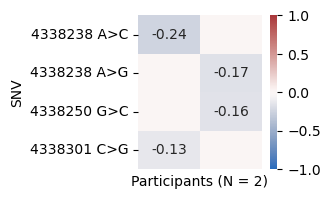

In [240]:
gene = 'whiB6'

plot_unfixed_SNV_change_heatmap(gene, width=2, height=2, saveName=f"/home/sak0914/MtbLongitudinalDiversity/results/figures/{gene}_nonsilent_changes.svg")

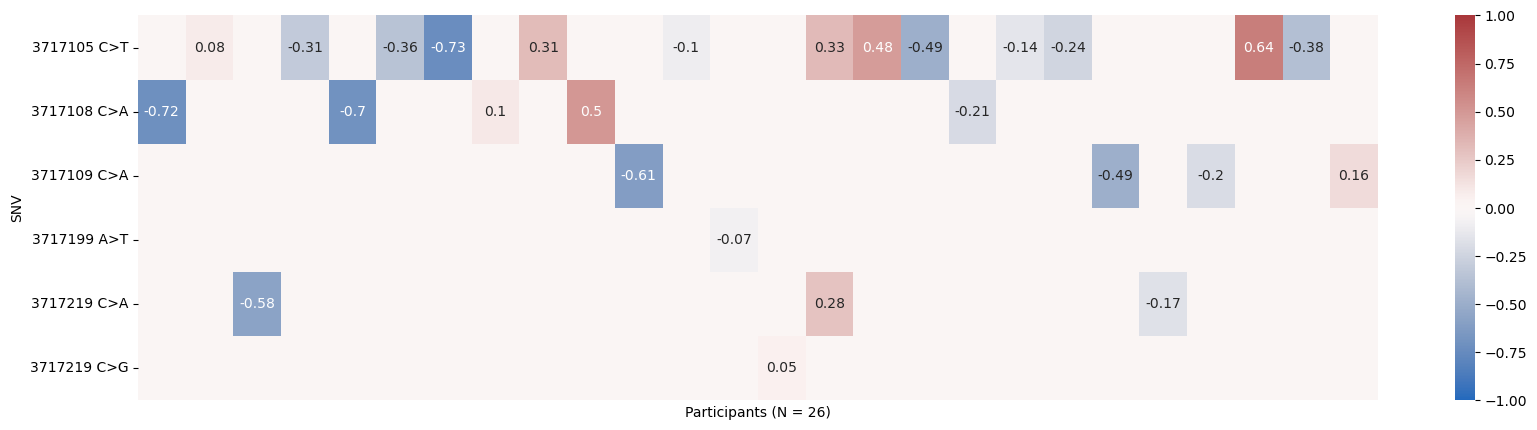

In [237]:
gene = 'sugI'

plot_unfixed_SNV_change_heatmap(gene, width=20, height=5, saveName=f"/home/sak0914/MtbLongitudinalDiversity/results/figures/{gene}_nonsilent_changes.svg")

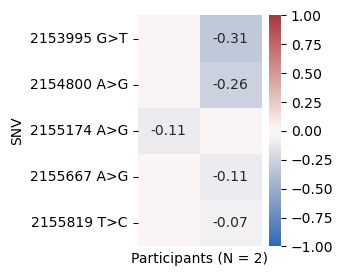

In [238]:
gene = 'katG'

plot_unfixed_SNV_change_heatmap(gene, width=2, height=3, saveName=f"/home/sak0914/MtbLongitudinalDiversity/results/figures/{gene}_nonsilent_changes.svg")

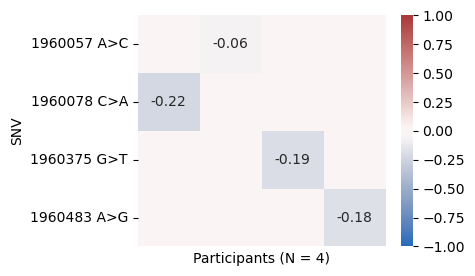

In [239]:
gene = 'Rv1733c'

plot_unfixed_SNV_change_heatmap(gene, width=4, height=3, saveName=f"/home/sak0914/MtbLongitudinalDiversity/results/figures/{gene}_nonsilent_changes.svg")

In [157]:
# # lower because of variants at 163705 and 163706, which are often in the range 0.9-0.95 and is why we're doing this exclusion in the first place
# fixed_thresh = 0.9

# mask = (SNV_differences.abs() > fixed_thresh) & ((sample_1_SNVs == 0) | (sample_2_SNVs == 0))

# # Get coordinates (row, col) of matches
# matches = mask.stack()  # converts to Series with MultiIndex
# matches = matches[matches]  # filter True values

# exclude_SNPs = matches.reset_index().iloc[:, :2]
# exclude_SNPs.columns = ['pid', 'SNP']

# print(f"Excluding {len(exclude_SNPs)} (pid, SNP) pairs that are suspicious")

# # replace the values. Make the SNPs fixed in both, and the difference 0
# sample_1_SNVs.mask(mask, other=1, inplace=True)
# sample_2_SNVs.mask(mask, other=1, inplace=True)
# SNV_differences.mask(mask, other=0, inplace=True)

# # Convert to tuples for comparison
# to_exclude = set(exclude_SNPs.itertuples(index=False, name=None))

# # # remove the SNPs from df_variants and df_lowAF_variants
# # df_variants = df_variants[~df_variants[['pid', 'SNP']].apply(tuple, axis=1).isin(to_exclude)]
# # df_lowAF_variants = df_lowAF_variants[~df_lowAF_variants[['pid', 'SNP']].apply(tuple, axis=1).isin(to_exclude)]

# # do the same for the baseline ones?
# # df_variants_baseline, df_lowAF_variants_baseline

# Selecting a Diversity Metric

In [12]:
AF_lst = np.linspace(0.005, 0.995, 101)

df_test = pd.DataFrame({'AF': AF_lst})
# df_test['Product'] = df_test['AF'] * (1 - df_test['AF'])
# df_test['Gini_Impurity'] = 1 - df_test['AF']**2 - (1 - df_test['AF'])**2
df_test['Shannon_Entropy'] = - df_test['AF'] * np.log2(df_test['AF']) - (1 - df_test['AF']) * np.log2(1 - df_test['AF'])

df_test = df_test.melt(id_vars='AF')

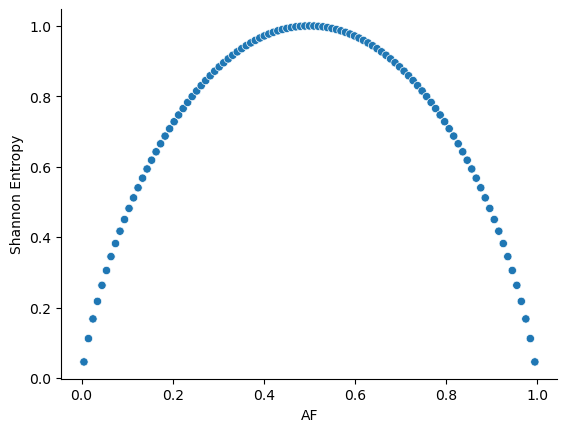

In [19]:
sns.scatterplot(data=df_test,
                x='AF',
                y='value',
                hue='variable',
                legend=False
               )

# sns.scatterplot(data=df_test,
#                 x='AF',
#                 y='Product',
#                 # legend=False
#                )

# sns.scatterplot(data=df_test,
#                 x='AF',
#                 y='Gini_Impurity',
#                 # legend=False
#                )

# sns.scatterplot(data=df_test,
#                 x='AF',
#                 y='Shannon_Entropy',
#                 # legend=False
#                )

# plt.legend(title='')

plt.xlabel('AF')
plt.ylabel('Shannon Entropy')
# plt.title(f"Product of AF and (1 - AF)")
sns.despine()
plt.savefig("../results/figures/Shannon_Entropy_example.svg")

In [304]:
def LAF_metric(AF_series, AF_min=0.05, AF_max=0.90):
    
    # the series has the SNP names as the indexes
    AF_array = AF_series.values
    
    # exclude absent or fixed variants from the count of low frequency variants
    keep_idx = np.argwhere((AF_array >= AF_min) & (AF_array <= AF_max)).flatten()
    keep_variants = AF_series.iloc[keep_idx].index.values

    # exclude 0s because those are no variants. It's because it's from a matrix, all positions that have a variant anywhere are there
    # any zeroes or ones (zeroes because 1 - AF) will zero out the Shannon entropy
    AF_array = AF_array[(AF_array >= AF_min) & (AF_array <= AF_max)]
    
    if len(AF_array) == 0:
        return [], 0, 0

    LAF = 0

    for i, AF in enumerate(AF_array):        
        # shannon entropy
        LAF += - AF * np.log2(AF) - (1 - AF) * np.log2(1 - AF)

    # return mean Shannon entropy. Also return the number of variable sites
    return keep_variants, LAF, LAF / len(AF_array)


def compute_proportion_variable_sites_shared_2samples(pid, df):
    
    df_sample_1 = df.query("pid == @pid & Paired_Sample_Num == 1")
    df_sample_2 = df.query("pid == @pid & Paired_Sample_Num == 2")
    
    sites_variable_intersect = list(set(df_sample_1.POS).intersection(df_sample_2.POS))
    sites_variable_union = list(set(df_sample_1.POS).union(df_sample_2.POS))
    
    if len(sites_variable_union) == 0:
        return 0
    
    # return proportion of all variable sites that are common between the two samples
    return len(sites_variable_intersect) / len(sites_variable_union)

In [305]:
def compute_diversity_metric_changes(sample_1_SNVs, sample_2_SNVs, SNV_differences, df_pids, silent_SNPs, AF_thresh=0.95, silent=True):

    # segregating sites is symmetric difference between sample 1 and sample 2. These are the sites that are different between them?
    df_LAF = pd.DataFrame(columns = ['pid', 'SE1', 'SE2', 'SASE1', 'SASE2', 'NumVar1', 'NumVar2', 'NumVar', 'OverlapVarSites', 'ChangeSites'])
    
    if not silent:
        sample_1_SNVs = sample_1_SNVs.drop(columns=silent_SNPs)
        sample_2_SNVs = sample_2_SNVs.drop(columns=silent_SNPs)
        SNV_differences = SNV_differences.drop(columns=silent_SNPs)
        
    print(SNV_differences.shape)

    for i, pid in enumerate(sample_1_SNVs.index.values):

        # remove sites that are fixed (AF > AF_thresh) in both. Keep those that are fixed in one and not the other though
        single_pid_results = pd.DataFrame(SNV_differences.loc[pid]).query(f"{pid} != 0").merge(pd.DataFrame(sample_1_SNVs.loc[pid]).rename(columns={pid: 'Sample1'}), left_index=True, right_index=True)
        single_pid_results = single_pid_results.merge(pd.DataFrame(sample_2_SNVs.loc[pid]).rename(columns={pid: 'Sample2'}), left_index=True, right_index=True)
        single_pid_results = single_pid_results.query("~(Sample1 > @AF_thresh & Sample2 > @AF_thresh)")

        sample_1_variable_sites, sample_1_SE, sample_1_SASE = LAF_metric(single_pid_results['Sample1'], AF_min=0.05, AF_max=AF_thresh)
        sample_2_variable_sites, sample_2_SE, sample_2_SASE = LAF_metric(single_pid_results['Sample2'], AF_min=0.05, AF_max=AF_thresh)

        df_LAF.loc[i, :] = [pid, 
                            sample_2_SE, # Shannon entropy for sample 1
                            sample_2_SE, # Shannon entropy for sample 2
                            sample_1_SASE,
                            sample_2_SASE,
                            len(sample_1_variable_sites), # number of variable sites for sample 1
                            len(sample_2_variable_sites), # number of variable sites for sample 2
                            len(list(set(sample_1_variable_sites).union(sample_2_variable_sites))), # union of variable sites in samples 1 and 2
                            len(list(set(sample_1_variable_sites).intersection(sample_2_variable_sites))),
                            len(list(set(sample_1_variable_sites).symmetric_difference(sample_2_variable_sites))), # non-overlapping set of sites from samples 1 and 2 
                           ]

    # add in pids that are not in sample_1_unfixed_SNVs, which don't have a low frequency metric anywhere
    pids_no_LAF_variants = list(set(df_pids.pid) - set(df_LAF.pid))
    df_pids_no_LAF_variants = pd.DataFrame(columns = df_LAF.columns)
    df_pids_no_LAF_variants['pid'] = pids_no_LAF_variants

    for col in df_pids_no_LAF_variants.columns:
        if col != 'pid':
            df_pids_no_LAF_variants[col] = 0

    df_LAF = pd.concat([df_LAF, df_pids_no_LAF_variants])

    df_LAF['SE_Diff'] = df_LAF['SE2'] - df_LAF['SE1']
    df_LAF['SASE_Diff'] = df_LAF['SASE2'] - df_LAF['SASE1']
    df_LAF['Abs_SASE_Diff'] = np.abs(df_LAF['SASE_Diff'])

    df_LAF = df_LAF.merge(df_pids[['pid', 'Coll2014', 'Freschi2020', 'Lineage', 'F2']].drop_duplicates(subset='pid'))
    # df_LAF['Lineage'] = df_LAF['Lineage'].astype(int)
    df_LAF['NumVarDiff'] = df_LAF['NumVar2'] - df_LAF['NumVar1']

    df_LAF.to_csv(f"../results/diversity_metrics_{df_LAF.pid.nunique()}pids.csv", index=False)

    df_lowAF_variants.to_csv(f"../results/lowAF_variants_{df_lowAF_variants.pid.nunique()}pids.csv", index=False)
    
    return df_LAF
    
    
    
    
def compute_diversity_metric_baseline(sample_1_SNVs, df_pids, silent_SNPs, AF_thresh=0.95, silent=True):

    # segregating sites is symmetric difference between sample 1 and sample 2. These are the sites that are different between them?
    df_LAF = pd.DataFrame(columns = ['pid', 'SE1', 'SASE1', 'NumVar1'])
    
    if not silent:
        sample_1_SNVs = sample_1_SNVs.drop(columns=list(set(silent_SNPs).intersection(sample_1_SNVs.columns)))
        
    print(sample_1_SNVs.shape)

    for i, pid in enumerate(sample_1_SNVs.index.values):

        sample_1_variable_sites, sample_1_SE, sample_1_SASE = LAF_metric(sample_1_SNVs_baseline.loc[pid, :], AF_min=0.05, AF_max=AF_thresh)

        df_LAF.loc[i, :] = [pid, 
                            sample_1_SE, # Shannon entropy for sample 1
                            sample_1_SASE,
                            len(sample_1_variable_sites), # number of variable sites for sample 1
                           ]

    # add in pids that are not in sample_1_unfixed_SNVs, which don't have a low frequency metric anywhere
    pids_no_LAF_variants = list(set(df_pids.pid) - set(df_LAF.pid))
    df_pids_no_LAF_variants = pd.DataFrame(columns = df_LAF.columns)
    df_pids_no_LAF_variants['pid'] = pids_no_LAF_variants

    for col in df_pids_no_LAF_variants.columns:
        if col != 'pid':
            df_pids_no_LAF_variants[col] = 0

    df_LAF = pd.concat([df_LAF, df_pids_no_LAF_variants])

    df_LAF = df_LAF.merge(df_pids[['pid', 'Coll2014', 'Freschi2020', 'Lineage', 'F2']].drop_duplicates(subset='pid'))

    return df_LAF

In [308]:
df_LAF = compute_diversity_metric_changes(sample_1_SNVs, 
                                          sample_2_SNVs, 
                                          SNV_differences, 
                                          df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2"), 
                                          df_variants.SNP.unique(), # because we don't have the variant types yet
                                          # df_variants.query("Variant_Type == 'Silent'").SNP.unique(), 
                                          silent=True,
                                          # AF_thresh=0.95
                                         )

df_LAF = df_LAF.merge(df_longitudinal_pids[['pid', 'Sampling_Interval']].drop_duplicates())
df_LAF = df_LAF.merge(df_trust_patients[['pid', 's_ttp_sputum_specimen_1']].drop_duplicates())

df_LAF_baseline = compute_diversity_metric_baseline(sample_1_SNVs_baseline, 
                                                    df_baseline_samples, 
                                                    df_variants_baseline.SNP.unique(),  # because we don't have the variant types yet
                                                    # df_variants_baseline.query("Variant_Type=='Silent'").SNP.unique(), 
                                                    silent=True,
                                                    # AF_thresh=0.95
                                                   )

df_LAF_baseline = df_LAF_baseline.merge(df_trust_patients[['pid', 's_ttp_sputum_specimen_1']].drop_duplicates())

(286, 11737)
(395, 13553)


In [266]:
df_LAF = compute_diversity_metric_changes(sample_1_SNVs, 
                                          sample_2_SNVs, 
                                          SNV_differences, 
                                          df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2"), 
                                          df_variants.query("Variant_Type == 'Silent'").SNP.unique(), 
                                          silent=True,
                                          # AF_thresh=0.95
                                         )

df_LAF = df_LAF.merge(df_longitudinal_pids[['pid', 'Sampling_Interval']].drop_duplicates())
df_LAF = df_LAF.merge(df_trust_patients[['pid', 's_ttp_sputum_specimen_1']].drop_duplicates())

df_LAF_baseline = compute_diversity_metric_baseline(sample_1_SNVs_baseline, 
                                                    df_baseline_samples, 
                                                    df_variants_baseline.query("Variant_Type=='Silent'").SNP.unique(), 
                                                    # df_variants_baseline.SNP.unique(), 
                                                    silent=True,
                                                    # AF_thresh=0.95
                                                   )

df_LAF_baseline = df_LAF_baseline.merge(df_trust_patients[['pid', 's_ttp_sputum_specimen_1']].drop_duplicates())

(286, 11629)
(395, 13514)


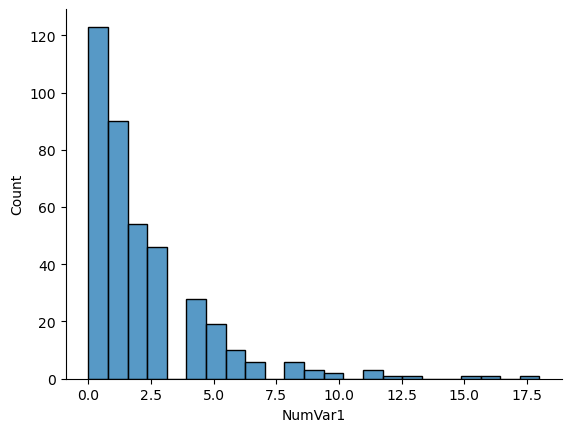

In [309]:
sns.histplot(data=df_LAF_baseline,
             x='NumVar1'
            )

sns.despine()
plt.show()

In [319]:
# sns.scatterplot(data=df_LAF_baseline,
#                 x='F2',
#                  y='SASE1'
#                 )

# plt.axvline(F2_max, color='black', linestyle='--', linewidth=1, label=f"F2 = {F2_max}")

# plt.xscale('log')
# plt.yscale('log')

# plt.ylabel('Shannon Entropy')
# plt.legend()

# sns.despine()

In [268]:
# or ttest_rel for parametric
st.wilcoxon(df_LAF.query("pid in @pids_with_same_lineage_and_low_F2")['SASE2'],
            df_LAF.query("pid in @pids_with_same_lineage_and_low_F2")['SASE1'],
            alternative='two-sided'
           )

WilcoxonResult(statistic=14334.0, pvalue=0.1989478450042279)

In [18]:
df_LAF.query("pid in @pids_with_same_lineage_and_low_F2").SASE_Diff.median(), df_LAF.query("pid in @pids_with_same_lineage_and_low_F2").SASE_Diff.mean()

(0.0, 0.023632576761003006)

<Axes: xlabel='Sampling_Interval', ylabel='Count'>

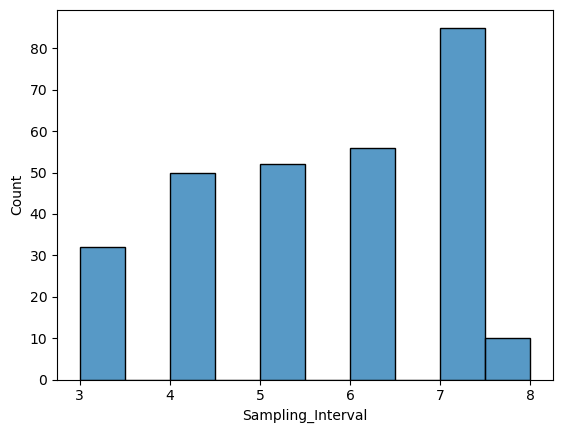

In [37]:
sns.histplot(data=df_LAF,
             x='Sampling_Interval'
            )

In [54]:
for interval in np.sort(df_LAF.Sampling_Interval.unique()):
    
    num_samples = len(df_LAF.query("Sampling_Interval >= @interval"))
    
    if num_samples > 10:
        
        # or ttest_rel for parametric
        pval = st.wilcoxon(df_LAF.query("pid in @pids_with_same_lineage_and_low_F2 & Sampling_Interval >= @interval")['NumVar2'],
                    df_LAF.query("pid in @pids_with_same_lineage_and_low_F2 & Sampling_Interval >= @interval")['NumVar1'],
                    alternative='greater'
                   ).pvalue

        print(f"≥ {interval}: {pval}, N = {num_samples}")

≥ 3: 0.005275156306765916, N = 285
≥ 4: 0.009139912344350394, N = 253
≥ 5: 0.036284390579062166, N = 203
≥ 6: 0.013307923279472484, N = 151
≥ 7: 0.006278036942045351, N = 95


In [77]:
st.spearmanr(df_LAF[['NumVar1', 's_ttp_sputum_specimen_1']].dropna()['NumVar1'], 
             df_LAF[['NumVar1', 's_ttp_sputum_specimen_1']].dropna()['s_ttp_sputum_specimen_1'],
            )

SignificanceResult(statistic=0.07275030424747586, pvalue=0.2232720827279506)

<Axes: xlabel='s_ttp_sputum_specimen_1', ylabel='Count'>

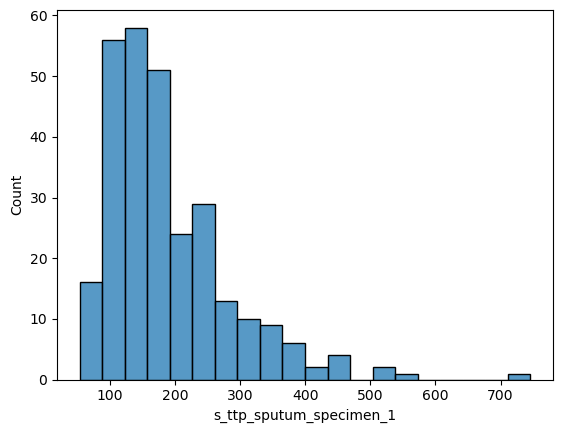

In [79]:
sns.histplot(data=df_LAF,
             x='s_ttp_sputum_specimen_1'
            )

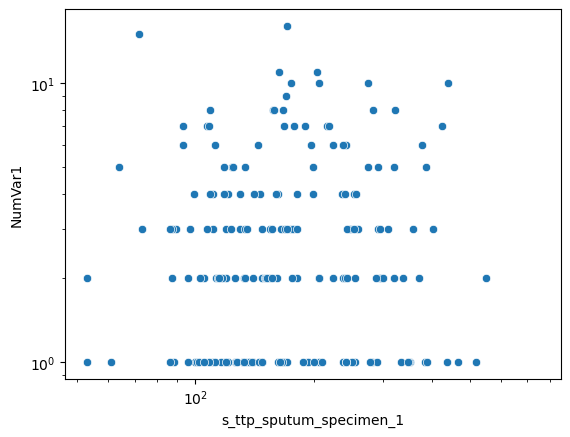

In [74]:
sns.scatterplot(data=df_LAF,
                x='s_ttp_sputum_specimen_1',
                y='NumVar1'
               )

plt.xscale('log')
plt.yscale('log')

In [50]:
st.spearmanr(df_LAF['Sampling_Interval'], df_LAF['NumVarDiff'])

SignificanceResult(statistic=0.009175074194003287, pvalue=0.8774397462013168)

In [25]:
# or ttest_rel for parametric
st.wilcoxon(df_LAF.query("pid in @pids_with_same_lineage_and_low_F2")['NumVarDiff'],
            alternative='greater'
           )

WilcoxonResult(statistic=14926.0, pvalue=0.005275156306765916)

In [240]:
df_LAF.query("pid in @pids_with_same_lineage_and_low_F2").NumVarDiff.median(), df_LAF.query("pid in @pids_with_same_lineage_and_low_F2").NumVarDiff.mean()

(0.0, 0.23508771929824562)

In [241]:
len(df_LAF.query("pid in @pids_with_same_lineage_and_low_F2")), len(df_LAF.query("pid in @pids_with_same_lineage_and_low_F2 & NumVar1==0 & NumVar2==0"))

(285, 62)

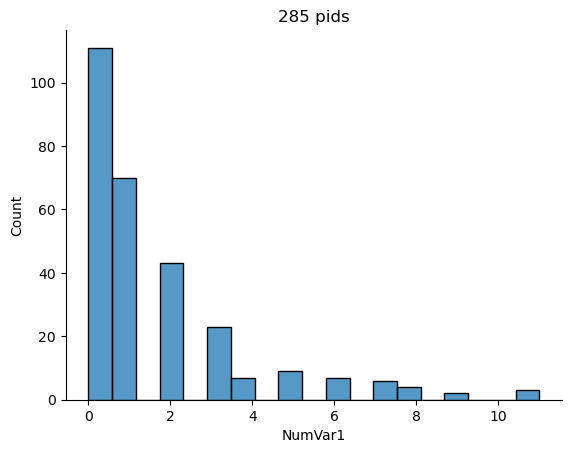

In [25]:
df_plot = df_LAF.query("pid in @pids_with_same_lineage_and_low_F2")

sns.histplot(data=df_plot,
             x='NumVar1',
            )

plt.title(f"{df_plot.pid.nunique()} pids")

sns.despine()
plt.savefig("../results/figures/NumVar1_unmixed.svg", bbox_inches='tight')

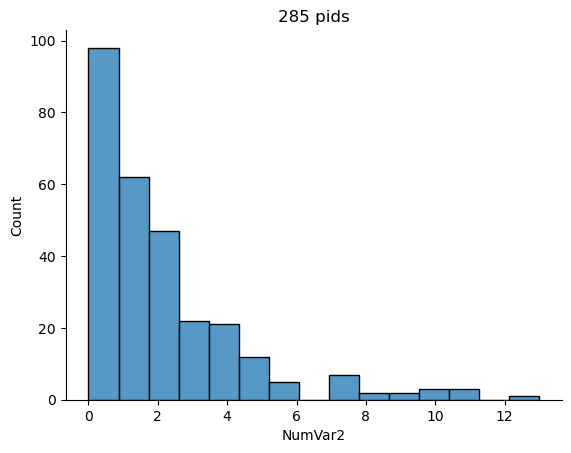

In [26]:
df_plot = df_LAF.query("pid in @pids_with_same_lineage_and_low_F2")

sns.histplot(data=df_plot,
             x='NumVar2',
            )

plt.title(f"{df_plot.pid.nunique()} pids")

sns.despine()
plt.savefig("../results/figures/NumVar2_unmixed.svg", bbox_inches='tight')

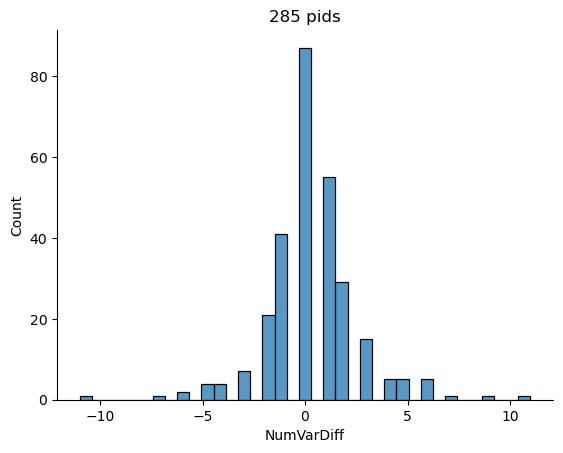

In [27]:
df_plot = df_LAF.query("pid in @pids_with_same_lineage_and_low_F2")

sns.histplot(data=df_plot,
             x='NumVarDiff',
            )

plt.title(f"{df_plot.pid.nunique()} pids")

sns.despine()
plt.savefig("../results/figures/NumVardiff_unmixed_both.svg", bbox_inches='tight')

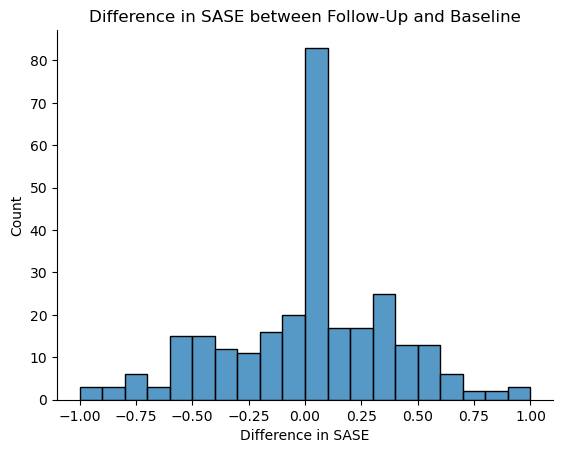

In [28]:
sns.histplot(data=df_LAF.query("pid in @pids_with_same_lineage_and_low_F2"),
             x='SASE_Diff',
             bins=np.linspace(-1, 1, 21)
            )

plt.title('Difference in SASE between Follow-Up and Baseline')
plt.xlabel('Difference in SASE')

sns.despine()
plt.savefig("../results/figures/SASE_diff.svg", bbox_inches='tight')

In [29]:
lineage_col = 'Coll2014'

for lineage in df_LAF[lineage_col].unique():
    
    num_isolates = len(df_LAF.query(f"{lineage_col}==@lineage & ~(SASE1 == 0 & SASE2 == 0)"))
    
    if num_isolates > 1:
    
        increase_pval = st.wilcoxon(df_LAF.query(f"{lineage_col}==@lineage")['SASE2'],
                                    df_LAF.query(f"{lineage_col}==@lineage")['SASE1'],
                                    alternative='greater'
                                   ).pvalue
        
        decrease_pval = st.wilcoxon(df_LAF.query(f"{lineage_col}==@lineage")['SASE2'],
                                    df_LAF.query(f"{lineage_col}==@lineage")['SASE1'],
                                    alternative='less'
                                   ).pvalue

        if increase_pval <= 0.05:
            print(f"L{lineage} increase: p = {np.round(increase_pval, 2)}, N = {num_isolates}")
            
        if decrease_pval <= 0.05:
            print(f"L{lineage} decrease: p = {np.round(decrease_pval, 2)}, N = {num_isolates}")

L4.1.2.1 increase: p = 0.03, N = 4


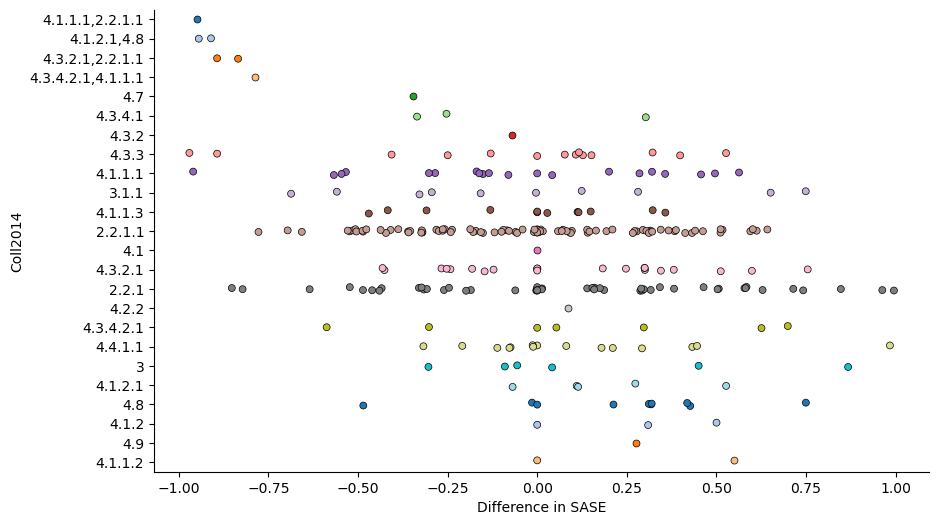

In [353]:
lineage_order = df_LAF.groupby('Coll2014')['SASE_Diff'].mean().sort_values().index.values

fig, ax = plt.subplots(figsize=(10, 6))

sns.stripplot(data=df_LAF,
                x='SASE_Diff',
             y='Coll2014',
             # multiple='dodge',
             # common_norm=False,
             palette='tab20',
              order=lineage_order,
              edgecolor='black',
              linewidth=0.5,
              ax=ax
               )

# plt.title('Difference in SASE between Follow-Up and Baseline')
plt.xlabel('Difference in SASE')

sns.despine()
# plt.savefig("../results/figures/SASE_diff_by_lineage.svg", bbox_inches='tight')

Text(0.5, 1.0, 'Absolute Change in SASE vs. Number of Sites with Low AF Variants')

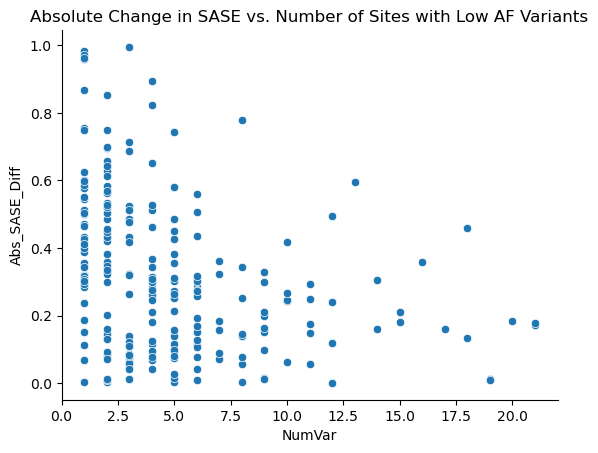

In [354]:
sns.scatterplot(data=df_LAF.query("pid in @pids_with_low_F2").query("SASE1 != 0 | SASE2 != 0"),
                x='NumVar',
                y='Abs_SASE_Diff'
               )

# plt.yscale('log')

sns.despine()
plt.title("Absolute Change in SASE vs. Number of Sites with Low AF Variants")

In [355]:
st.spearmanr(df_LAF.query("pid in @pids_with_low_F2").query("SASE1 != 0 | SASE2 != 0")['NumVar'], df_LAF.query("pid in @pids_with_low_F2").query("SASE1 != 0 | SASE2 != 0")['Abs_SASE_Diff'])

SignificanceResult(statistic=-0.3959760196258482, pvalue=2.1385435171114255e-10)

# pids with Large Changes in SASE

In [31]:
# pid = 'T0143'

# # remove sites that are fixed (AF > 0.95) in both. Keep those that are fixed in one and not the other though
# single_pid_results = pd.DataFrame(SNV_differences.loc[pid]).query(f"{pid} != 0").merge(pd.DataFrame(sample_1_SNVs.loc[pid]).rename(columns={pid: 'Sample1'}), left_index=True, right_index=True)
# single_pid_results = single_pid_results.merge(pd.DataFrame(sample_2_SNVs.loc[pid]).rename(columns={pid: 'Sample2'}), left_index=True, right_index=True)
# single_pid_results = single_pid_results.query("~(Sample1 > @AF_thresh & Sample2 > @AF_thresh)")

# single_pid_results

# Nucleotide Diversity and Estimated Population Size Calculations

In [ ]:
# df_exclude = pd.read_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/references/BED_files/exclude_regions_50bp.EBRlessThan95Percent.bed", sep='\t', header=None)

# excluded_sites = []

# for i, row in df_exclude.iterrows():
#     excluded_sites += list(np.arange(row[1] + 1, row[2] + 1))
    
# # also excluded [2337869, 2340874], inclusive
# excluded_sites += list(np.arange(2337869, 2340874 + 1))

# excluded_sites = np.unique(excluded_sites)

# num_total_sites = len(h37Rv_seq) - len(excluded_sites)

In [360]:
def compute_nucleotide_diversity_Ne(pid, mutation_rate=5e-8):
    
    # remove sites that are fixed (AF > 0.95) in both. Keep those that are fixed in one and not the other though
    df_sample_1 = pd.DataFrame(sample_1_SNVs.loc[pid]).rename(columns={pid: 'Sample1'})
    df_sample_2 = pd.DataFrame(sample_2_SNVs.loc[pid]).rename(columns={pid: 'Sample2'})

    df_sample_1['Sample1_Inv'] = 1 - df_sample_1['Sample1']
    df_sample_2['Sample2_Inv'] = 1 - df_sample_2['Sample2']

    ND_1 = np.sum(2 * df_sample_1.product(axis=1)) / len(df_sample_1)
    ND_2 = np.sum(2 * df_sample_2.product(axis=1)) / len(df_sample_2)

    Ne_1 = ND_1 / (2 * mutation_rate)
    Ne_2 = ND_2 / (2 * mutation_rate)

    return pd.DataFrame({'pid': pid, 'ND_1': ND_1, 'ND_2': ND_2, 'Ne_1': Ne_1, 'Ne_2': Ne_2}, index=[0])

In [368]:
df_population_sizes = []

for pid in df_longitudinal_pids.pid.unique():
    df_population_sizes.append(compute_nucleotide_diversity_Ne(pid))
    
df_population_sizes = pd.concat(df_population_sizes)

print(np.round(df_population_sizes[['Ne_1', 'Ne_2']].max().max()))

df_population_sizes = df_population_sizes.merge(df_longitudinal_pids[['pid', 'Paired_Sample_Num', 'F2']].pivot(index='pid', columns='Paired_Sample_Num', values='F2').rename(columns={1: 'F2_1', 2: 'F2_2'}).reset_index())

437980.0


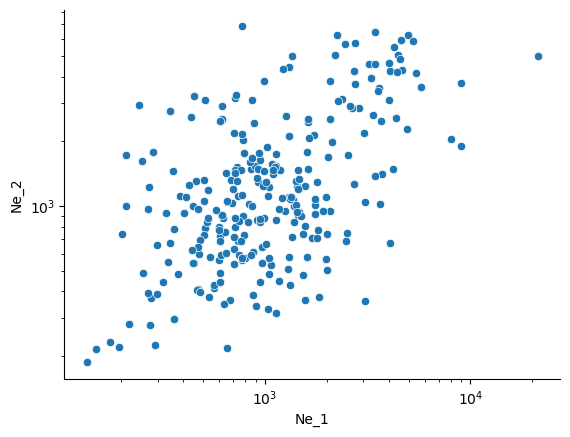

In [371]:
sns.scatterplot(data=df_population_sizes.query("pid in @pids_with_low_F2"),
                x='Ne_1',
                y='Ne_2'
               )

plt.xscale('log')
plt.yscale('log')

sns.despine()

# Associate diversity metrics with outcomes

In [36]:
import sys
sys.path.append(os.path.join(os.getcwd(), "scripts"))
from epi_utils import *

In [312]:
cols_lst = [
            'screen_sex',
            'screen_years',
            'underweight',
            'fstrom1_baseline', # smoking yes or no
            'smoked_substance_use',
            'peth_value_baseline',
            'HIV_CD4',
            'bl_prevtb',
            # 'TTP_baseline',
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            'adherence_rate_by_observed',
            'high_lung_involvement',
            # 'cxr_cavity_chest_radiograph_1',
            # 'Lineage', # Lineage_3 is so rare and causes instabilities / needs to be stratified by
            # 'F2',
            # 'MixedInfect'
           ]

PLI_thresh = 20

# try these first, as they were required for the full TCC model
stratify_covariates = ['smear_pos_no_contam_sputum_specimen_1', 'HIV_CD4', 'high_lung_involvement', 'smoked_substance_use', 'screen_sex']

non_linear_term_variables = []

TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_imputed_TCC = pd.read_csv(f"{TRUST_data_dir}/imputed_TCC.csv").query("pid in @df_trust_patients.pid")

df_TCC = df_imputed_TCC.query("imp_num==0").reset_index(drop=True)
df_imputed_TCC = df_imputed_TCC.query("imp_num > 0").reset_index(drop=True)

CNN_results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

# this includes TTP, PK AUC, and CXR data merged in
df_processed_patients = pd.read_csv(f"{TRUST_data_dir}/20251126_cleaned_patient_outcomes_data.csv")

df_pids_for_outcomes_model, TRUST_phenos, df_pred_combined = read_combine_all_TRUST_data(df_processed_patients, 
                                                                                         {'RIF': 'lineage_amino_acid',
                                                                                          'INH': 'lineage_amino_acid',
                                                                                          'EMB': 'lineage_amino_acid',
                                                                                          'PZA': 'amino_acid'}, 
                                                                                         CNN_results_dir,
                                                                                         F2_thresh=1, 
                                                                                         baseline_only=True
                                                                                        )

# df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("pid in @df_longitudinal_pids.pid").drop_duplicates(subset='pid').reset_index(drop=True)
# df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("pid in @df_baseline_samples.pid").drop_duplicates(subset='pid').reset_index(drop=True)

# df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("pid in @pids_with_same_lineage_and_low_F2").drop_duplicates(subset='pid').reset_index(drop=True)
# df_pids_for_outcomes_model = df_pids_for_outcomes_model.drop_duplicates(subset='pid').reset_index(drop=True)

df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("pid in @df_baseline_samples.pid & Sampling_Week <= 2")
df_pids_for_outcomes_model['inh_resistant'] = (df_pids_for_outcomes_model['pid'].isin(TRUST_phenos.query("INH_lower_bound >= 0.1").pid.values)).astype(int)

df_pids_for_outcomes_model['underweight'] = (df_pids_for_outcomes_model['bl_bmi'] < 18).astype(int)
df_pids_for_outcomes_model['MixedInfect'] = (df_pids_for_outcomes_model['F2'] > F2_max).astype(int)
df_pids_for_outcomes_model['High_TTP'] = (df_pids_for_outcomes_model['TTP_baseline'] > 300).astype(int)

# use the old PLI predictions. Idk what's wrong with the new ones. Probably issues with deduplicating the files
del df_pids_for_outcomes_model['predicted_PLI']
df_PLI = pd.read_csv("~/MtbQuantCNN/analysis/TRUST/processed_data/PLI_Timika_predictions.csv")
df_pids_for_outcomes_model = df_pids_for_outcomes_model.merge(df_PLI.query("Outlier==0 & View=='1B'").sort_values(['pid', 'View']).drop_duplicates('pid', keep='first'), on='pid', how='left')

df_pids_for_outcomes_model['cxr_cavity_chest_radiograph_1'] = df_pids_for_outcomes_model['cxr_cavity_chest_radiograph_1'].replace(2, np.nan)

# df_pids_for_outcomes_model['inv_adherence_rate_by_observed'] = 1 - df_pids_for_outcomes_model['adherence_rate_by_observed']

# df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("Sampling_Week <= 2")
df_pids_for_outcomes_model = df_pids_for_outcomes_model.sort_values(['pid', 'Original_ID']).drop_duplicates(subset='pid', keep='first').reset_index(drop=True)

len(df_pids_for_outcomes_model), df_pids_for_outcomes_model.pid.nunique()

406 patients with uncontaminated WGS samples
400 patients with uncontaminated WGS samples taken in the first 2 weeks

8 patients: ['T0402' 'T0206' 'T0128' 'T0042' 'T0404' 'T0032' 'T0403' 'T0170'] have multiple sequences at the same timepoint
403 patients have MICs for RIF
403 patients have MICs for INH
403 patients have MICs for EMB
282 patients have MICs for PZA
398 patients have measured MICs in the first 2 weeks

Found predicted RIF MICs for 400 pids
Found predicted INH MICs for 400 pids
Found predicted EMB MICs for 400 pids
Found predicted PZA MICs for 400 pids
400 patients have predicted MICs


(379, 379)

<Axes: xlabel='predicted_PLI', ylabel='Count'>

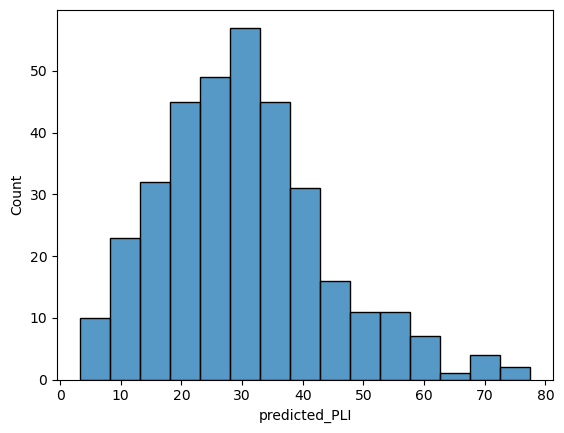

In [311]:
sns.histplot(data=df_pids_for_outcomes_model,
             x='predicted_PLI',
            )

In [39]:
# df_pids_for_outcomes_model['predicted_PLI'].median(), np.percentile(df_pids_for_outcomes_model['predicted_PLI'].dropna(), 75)

In [40]:
labels_dict = {'RIF_AUC': 'Rifampicin PK AUC',
              'INH_AUC': 'Isoniazid PK AUC',
              'EMB_AUC': 'Ethambutol PK AUC',
              'PZA_AUC': 'Pyrazinamide PK AUC',
              'screen_sex': 'Male Sex',
              'screen_years': 'Age',
              'bl_bmi': 'Body Mass Index',
              'smoked_substance_use': 'Smoked Substance Use',
              'HIV_High_CD4': 'HIV, CD4 ≥ 200 cells/$\mathregular{mm^3}$',
              'HIV_Low_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$',
              'bl_prevtb': 'Previous TB Disease',
              'smear_pos_no_contam_sputum_specimen_1': 'Smear Positivity at Baseline',
              'diabetes': 'Diabetes',
              'Lineage_1': 'Lineage 1',
              'Lineage_2': 'Lineage 2',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4',
              'total_adherence': 'Adherence Rate',
              'F2': 'F2 Strain Mixing Metric',
              'inh_resistant': 'INH Resistance',
              'high_lung_involvement': '>20% Lung Affected',
              'RIF_pred_MIC': 'Predicted RIF MIC',
              'INH_pred_MIC': 'Predicted INH MIC',
              'EMB_pred_MIC': 'Predicted EMB MIC',
              'PZA_pred_MIC': 'Predicted PZA MIC',
              'RIF_midpoint': 'Measured RIF MIC',
              'INH_midpoint': 'Measured INH MIC',
              'EMB_midpoint': 'Measured EMB MIC',
              'PZA_midpoint': 'Measured PZA MIC',
               'delayed_TCC': 'TCC > 8 Weeks',
               'TTP_baseline': 'TTP at Baseline',
               'peth_value_baseline': 'PEth',
               'fstrom1_baseline': 'Smoking',
               'RIF_pred_MIC_high': 'Predicted RIF MIC > 0.06 µg/mL',
               # 'INH_pred_MIC_high': 'Predicted Isoniazid MIC',
               'PZA_pred_MIC_high': 'Predicted Pyrazinamide MIC > 24.6 µg/mL',
               'HIV_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$', # when we computed the relative risk, it was this group vs. the other two groups,
               'high_lung_involvement': f'PLI > {PLI_thresh}%',
               'Not_Lineage_2': 'Not Lineage 2',
               'NumVar': '# of low-AF Segregating Sites',
               'NumVar1': '# of low-AF Sites at Baseline',
               'ChangeSites': '# of low-AF Sites with a Change',
               'underweight': 'BMI < 18',
               'adherence_rate_by_observed': 'Tx Adherence',
               'SASE1': 'Site-Averaged Shannon Entropy at Baseline',
               'cxr_cavity_chest_radiograph_1': 'Cavitation',
               'predicted_PLI': 'Predicted % Lung Involvement'
             }

In [41]:
df_pids_for_outcomes_model['adherence_rate_by_observed'].mean(), df_pids_for_outcomes_model['adherence_rate_by_observed'].median()

(0.7341972046627192, 0.837722337722338)

In [42]:
# df_processed_patients = pd.read_csv(f"/home/sak0914/TRUST_data_processing/processed_data/.snapshot/o2_home_2025-11-24_17_15_04_UTC/20251111_cleaned_patient_outcomes_data.csv")
# df_processed_patients['screen_sex'] = df_processed_patients['screen_sex'].replace(2, 0)
# df_processed_patients.to_csv(f"/home/sak0914/TRUST_data_processing/processed_data/20251111_cleaned_patient_outcomes_data.csv", index=False)

In [43]:
df_test_results, df_model_processed, cph_models_imputations = fit_cox_models_all_imputations(df_pids_for_outcomes_model,
                                                                                                  df_pred_combined,
                                                                                                   TRUST_phenos,
                                                                                                  df_imputed_TCC,
                                                                                                  cols_lst,
                                                                                                  event_col = 'culture_convert',
                                                                                                  time_col = 'TCC',
                                                                                                 MIC_type = 'none',
                                                                                                  invert_OR=True,
                                                                                                  stratify_variables=stratify_covariates,
                                                                                                 binary_lineage=True
                                                                                                 )

df_violating_covariates = []

for model_idx in range(len(cph_models_imputations)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], df_model_processed[model_idx], time_transform='rank').summary

    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)

print(len(df_violating_covariates.query("p <= 0.05")))

# convert to HR per 10 years
OR_col = 'HR_TCC_assoc'
df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

    328 total pids
5


In [44]:
OR_col = 'HR_TCC_assoc'
df_test_results.query("pval <= 0.05").sort_values('pval')[['pval', 'covariate', f"{OR_col}_lower", OR_col, f"{OR_col}_upper"]]

,pval,covariate,HR_TCC_assoc_lower,HR_TCC_assoc,HR_TCC_assoc_upper
5,0.000314,screen_years,1.136384,1.318263,1.529251


In [45]:
forest_plot(df_test_results, 
            df_test_results.sort_values(['pval', 'HR_TCC_assoc'], ascending=[True, False]).covariate.values, 
            labels_dict, 
            val_col='HR_TCC_assoc', 
            alpha=0.05, 
            log=False, 
            pval_offset=1.05, 
            df_stratify_variables_results=None, 
            saveName="../results/figures/TCC/forest_plot.svg"
           )

In [46]:
df_pids_for_outcomes_model.pid.nunique()

379

In [47]:
df_LAF_baseline.pid.nunique()

395

In [48]:
diversity_metric = 'NumVar1'
binarize = False
thresh = 0.1

# df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid', diversity_metric, 'grouped_variant']])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])
df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid', diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])

if binarize:
    df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > thresh).astype(int)
    
    median_val = df_add_metric_for_model[diversity_metric].median()
    # df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > median_val).astype(int)

df_test_results_diversity, _, _ = fit_cox_models_all_imputations(df_add_metric_for_model,
                                                              df_pred_combined, 
                                                                TRUST_phenos,
                                                              df_imputed_TCC,
                                                           cols_lst + [diversity_metric],
                                                              event_col = 'culture_convert',
                                                              time_col = 'TCC',
                                                              invert_OR=True,
                                                              stratify_variables=stratify_covariates,
                                                             binary_lineage=True
                                                             )

    328 total pids


In [49]:
# convert to HR per 10 years
OR_col = 'HR_TCC_assoc'

df_test_results_diversity.loc[df_test_results_diversity['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results_diversity.loc[df_test_results_diversity['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

In [50]:
OR_col = 'HR_TCC_assoc'

df_test_results_diversity.query("pval <= 0.05").sort_values('pval')[['pval', 'covariate', f"{OR_col}_lower", OR_col, f"{OR_col}_upper"]]

,pval,covariate,HR_TCC_assoc_lower,HR_TCC_assoc,HR_TCC_assoc_upper
6,0.000284,screen_years,1.138999,1.321645,1.533579


In [56]:
forest_plot(df_test_results_diversity, 
            df_test_results_diversity.sort_values(['pval', 'HR_TCC_assoc'], ascending=[True, False]).covariate.values, 
            labels_dict, 
            val_col='HR_TCC_assoc', 
            alpha=0.05, 
            log=False, 
            pval_offset=1.05, 
            df_stratify_variables_results=None, 
            saveName="../results/figures/TCC/forest_plot_with_pilon_diversity.svg"
           )

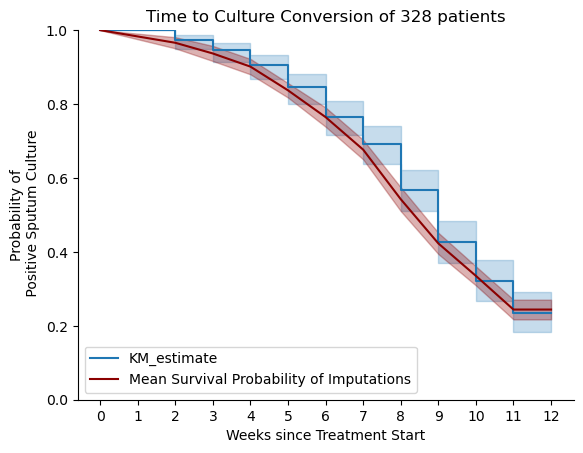

In [52]:
pids_with_TCC = df_model_processed[0].pid.unique()
df_imputed_TCC = df_imputed_TCC.query("pid in @pids_with_TCC")

median_survival_imputations = {}

# Prepare a list to collect survival functions from each imputation
survival_curves = []

# Fit Kaplan-Meier for each imputation and store survival function
for imp in df_imputed_TCC['imp_num'].unique():
    
    if imp > 0:
        imputed_data = df_imputed_TCC.query("imp_num==@imp")

        kmf = lifelines.KaplanMeierFitter()
        kmf.fit(durations=imputed_data['TCC'], event_observed=imputed_data['culture_convert'])

        survival_curves.append(kmf.survival_function_.rename(columns={"KM_estimate": f"imp_{imp}"}))

        median_survival_imputations[imp] = kmf.median_survival_time_

# Combine all imputed survival functions into one DataFrame
df_survival = pd.concat(survival_curves, axis=1)

kmf_full_dataset = lifelines.KaplanMeierFitter()
kmf_full_dataset.fit(df_TCC.query("pid in @pids_with_TCC")['TCC'], event_observed=df_TCC.query("pid in @pids_with_TCC")['culture_convert'])

fig, ax = plt.subplots()

kmf_full_dataset.plot_survival_function()#show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5})
plt.ylim(0, 1)

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, df_imputed_TCC.TCC.max() + 1))

mean_survival = df_survival.mean(axis=1)
sd_survival = df_survival.std(axis=1)

# plot the mean survival probability at each week across the imputations
# plt.step(df_survival.index, mean_survival, label='KM Estimate of Imputed Datasets', where='post')
plt.plot(df_survival.index, mean_survival, label='Mean Survival Probability of Imputations', color='darkred')#, where='post')

# Calculate and plot the confidence interval using 1.96 * std for ~95% CI
ci_upper = mean_survival + 1.96 * sd_survival
ci_lower = mean_survival - 1.96 * sd_survival

# 'tab:blue'
plt.fill_between(df_survival.index, ci_lower, ci_upper, alpha=0.3, color='darkred')#, label='95% CI')

plt.title(f"Time to Culture Conversion of {df_imputed_TCC.pid.nunique()} patients")
plt.ylabel("Probability of\n Positive Sputum Culture") #
plt.xlabel("Weeks since Treatment Start")

plt.gca().get_legend().remove()
plt.legend()

sns.despine()
plt.savefig(f"/home/sak0914/MtbLongitudinalDiversity/results/figures/TCC/KM_estimate.svg", bbox_inches='tight')

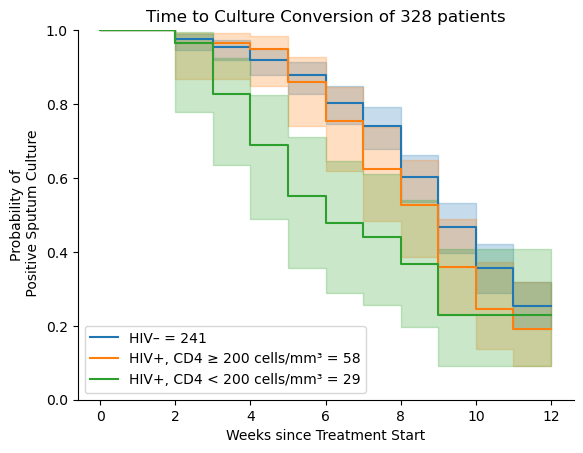

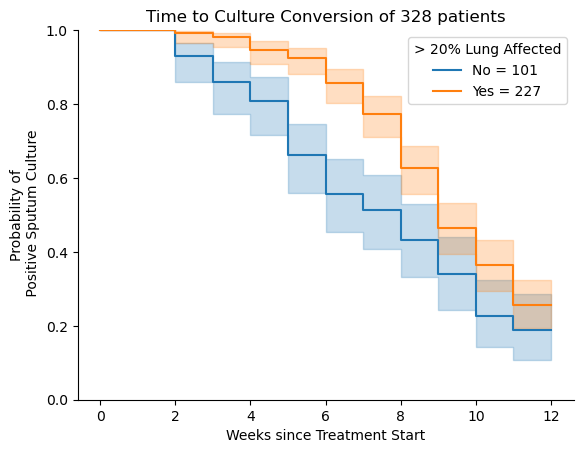

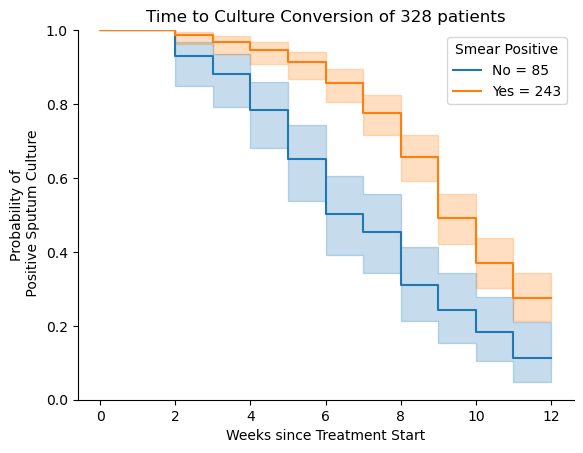

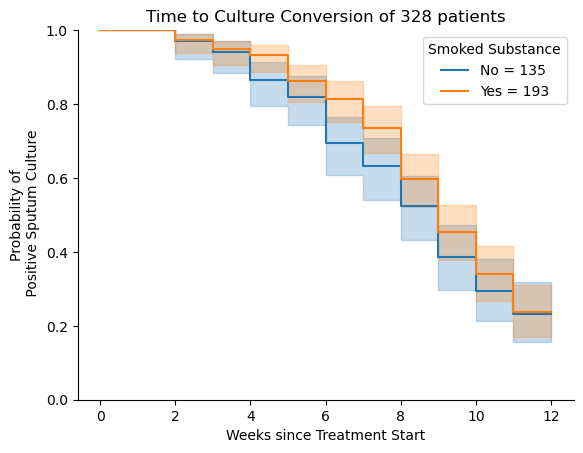

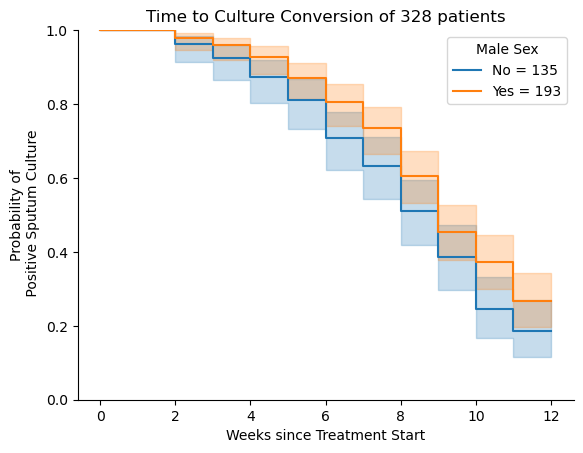

In [80]:
df_check_stratify_vars = df_pids_for_outcomes_model.query("pid in @pids_with_TCC").merge(df_TCC, on='pid')
df_check_stratify_vars['high_lung_involvement'] = (df_check_stratify_vars['predicted_PLI'] > 20)
df_check_stratify_vars['high_lung_involvement'] = df_check_stratify_vars['high_lung_involvement'].astype(int)

categorical_cols = ['HIV_CD4', 'high_lung_involvement', 'smear_pos_no_contam_sputum_specimen_1', 'smoked_substance_use', 'screen_sex']
labels_lst = ['HIV_CD4', '> 20% Lung Affected', 'Smear Positive', 'Smoked Substance', 'Male Sex']

legend_name_dict = dict(zip(categorical_cols, labels_lst))

df_logrank_pvalues = pd.DataFrame(columns = ['covariate', 'pval', 'TCC_ratio']).set_index('covariate')

for variable in categorical_cols:
    
    fig, ax = plt.subplots()
    
    df_single_variable = df_check_stratify_vars.dropna(subset=variable)
    df_single_variable[variable] = df_single_variable[variable].astype(int)
    
    if variable == 'HIV_CD4':
        legend_marker_dict = {0: 'HIV–', 1: 'HIV+, CD4 ≥ 200 cells/mm\u00B3', 2: 'HIV+, CD4 < 200 cells/mm\u00B3'}
        color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))
    # elif variable == 'Lineage 2':
    #     legend_marker_dict = {1: 'L1', 2: 'L2', 3: 'L3', 4: 'L4'}
    #     color_dict = {1: "#DF83AC", 2: "#7098CB", 3: "#815D9F", 4: "#E76956"}
    else:
        legend_marker_dict = {0: 'No', 1: 'Yes'}
        color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

    # sort so that 0 is plotted before 1
    for group in np.sort(df_single_variable[variable].unique()):
        
        df_single_group = df_single_variable.query(f"{variable}==@group")
            
        kmf = lifelines.KaplanMeierFitter()
        kmf.fit(df_single_group['TCC'], event_observed=df_single_group['culture_convert'], label=group)
            
        kmf.plot_survival_function(ax=ax, show_censors=False, color=color_dict[group], censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, label=f"{legend_marker_dict[group]} = {len(df_single_group)}")

        if variable != 'HIV_CD4':
            plt.legend(title=legend_name_dict[variable])

    # HIV with high CD4 and HIV-negative are not significantly different, so just compare HIV with low CD4 to the other 2 groups
    if variable == 'HIV_CD4':
        
        # do them separately for each of the two HIV groups relative to the no HIV group
        logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_single_variable.query(f"{variable}==1")['TCC'], 
                                                                  durations_B=df_single_variable.query(f"{variable}==0")['TCC'], 
                                                                  event_observed_A=df_single_variable.query(f"{variable}==1")['culture_convert'], 
                                                                  event_observed_B=df_single_variable.query(f"{variable}==0")['culture_convert'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )
        
        df_logrank_pvalues.loc['HIV_High_CD4', :] = [logRank_test_results.p_value,
                                                     df_single_variable.query(f"{variable}==1")['TCC'].mean() / df_single_variable.query(f"{variable}==0")['TCC'].mean()
                                                    ]
        
        logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_single_variable.query(f"{variable}==2")['TCC'], 
                                                                  durations_B=df_single_variable.query(f"{variable}==0")['TCC'], 
                                                                  event_observed_A=df_single_variable.query(f"{variable}==2")['culture_convert'], 
                                                                  event_observed_B=df_single_variable.query(f"{variable}==0")['culture_convert'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )
        
        df_logrank_pvalues.loc['HIV_Low_CD4', :] = [logRank_test_results.p_value, 
                                                    df_single_variable.query(f"{variable}==2")['TCC'].mean() / df_single_variable.query(f"{variable}==0")['TCC'].mean()
                                                   ]
        
    else:
        logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_single_variable.query(f"{variable}==1")['TCC'], 
                                                                  durations_B=df_single_variable.query(f"{variable}==0")['TCC'], 
                                                                  event_observed_A=df_single_variable.query(f"{variable}==1")['culture_convert'], 
                                                                  event_observed_B=df_single_variable.query(f"{variable}==0")['culture_convert'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )
        
        df_logrank_pvalues.loc[variable, :] = [logRank_test_results.p_value, 
                                               df_single_variable.query(f"{variable}==1")['TCC'].mean() / df_single_variable.query(f"{variable}==0")['TCC'].mean()
                                              ]

    # print(f"{legend_name_dict[variable]}: χ^2 = {logRank_test_results.test_statistic}, p = {logRank_test_results.p_value}")
    plt.ylim(0, 1)

    sns.despine()
    plt.title(f"Time to Culture Conversion of {df_single_variable.pid.nunique()} patients")
    plt.ylabel("Probability of\n Positive Sputum Culture") #
    plt.xlabel("Weeks since Treatment Start")
    sns.despine()
            
    if variable in stratify_covariates:
        # plt.show()
        plt.savefig(f"/home/sak0914/MtbLongitudinalDiversity/results/figures/TCC/KM_estimate_stratified_{legend_name_dict[variable]}.svg", bbox_inches='tight')
    else:
        plt.close()
    
df_logrank_pvalues.to_csv("/home/sak0914/MtbLongitudinalDiversity/results/TCC/KM_logRank_test_pvalues.csv")

In [82]:
df_logrank_pvalues.sort_values('pval')

,pval,TCC_ratio
covariate,,
smear_pos_no_contam_sputum_specimen_1,0.0,1.277807
high_lung_involvement,0.000252,1.243749
HIV_Low_CD4,0.001903,0.775014
screen_sex,0.033849,1.111553
HIV_High_CD4,0.152546,0.964556
smoked_substance_use,0.227321,1.0627


## Composite Poor Outcomes

In [313]:
# to_studyto_treatment_outcome column. 
# Other descriptions in to_studyto_other_treatment_outcome
# additional comments in to_comments_treatment_outcome
treatment_outcome_dict = {1: 'cure',
                          2: 'complete',
                          3: 'defaulted', # typically they stopped taking treatment entirely, not just interruption. May have been doctor-recommended, like due to liver injury or something
                          4: 'failure',
                          5: 'extension',
                          6: 'death',
                          7: 'transferred',
                          8: 'lost_fu',
                          9: 'other'
                        }

# esp_reason_end_of_study_parti column
# Other descriptions in esp_reasonoth_end_of_study_parti
esp_dict = {1: 'complete', # completed all study requirements
            2: 'inappropriate', # should not have been included in the study
            3: 'withdrew',
            4: 'failure', # includes both groups 4 and 5 in treatment_outcome_dict, meaning the patient was culture positive at month 5 or tx was extended
            5: 'relapse',
            6: 'moved', # moved/transferred out,
            7: 'lost_fu',
            8: 'death',
            9: 'other'
            }

cols_lst = [
            'screen_sex',
            'screen_years',
            'underweight',
            'fstrom1_baseline', # smoking yes or no
            'smoked_substance_use',
            'peth_value_baseline',
            'HIV_CD4',
            'bl_prevtb',
            # 'TTP_baseline',
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            'adherence_rate_by_observed',
            'high_lung_involvement',
            # 'predicted_PLI',
            # 'cxr_cavity_chest_radiograph_1',
            'Lineage', # Lineage_3 is so rare and causes instabilities / needs to be stratified by
            # 'F2',
            # 'MixedInfect'
           ]

# cols_lst = [
#             # 'screen_sex',
#             # 'screen_years',
#             # 'underweight',
#             # 'fstrom1_baseline', # smoking yes or no
#             # 'smoked_substance_use',
#             # 'peth_value_baseline',
#             'HIV_CD4',
#             'bl_prevtb',
#             # 'TTP_baseline',
#             'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
#             # 'diabetes',
#             # 'adherence_rate_by_observed',
#             'high_lung_involvement',
#             # 'predicted_PLI',
#             # 'cxr_cavity_chest_radiograph_1',
#             # 'Lineage', # Lineage_3 is so rare and causes instabilities / needs to be stratified by
#             # 'F2',
#             # 'MixedInfect'
#            ]

tb_deaths_only = True

# try these first, as they were required for the full TCC model
stratify_covariates = []

MIC_type = 'none'

df_tx_outcomes_full = pd.read_csv(f"{TRUST_data_dir}/tx_outcomes.csv")
df_tx_outcomes = pd.read_csv(f"{TRUST_data_dir}/tx_outcomes.csv").query("pid in @df_pids_for_outcomes_model.pid")

df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti'], 'event'] = 0
df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti'], 'censor_date'] = df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti']]['esp_date_end_of_study_parti']
df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti'], 'date'] = df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti']]['time_in_trial']

df_tx_outcomes['weeks'] = df_tx_outcomes['date'] / 7
df_tx_outcomes['months'] = df_tx_outcomes['date'] / 30

print(f"Maximum event date: {df_tx_outcomes.weeks.max()} weeks")

Maximum event date: 99.0 weeks


In [43]:
# df_tx_outcomes.query("pid in @df_model_processed.pid").shape

In [ ]:
df_tx_outcomes.query("pid in @df_model_processed.pid").time_in_trial.median(), df_tx_outcomes.query("pid in @df_model_processed.pid").time_in_trial.max()

In [ ]:
df_tx_outcomes.query("pid in @df_model_processed.pid").query("TB_death == 0")

In [118]:
df_tx_outcomes.query("pid in @df_model_processed.pid").query("event_type=='death' & event ==1")#.shape

,pid,date,event_type,to_studyto_treatment_outcome,esp_reason_end_of_study_parti,esp_reasonoth_end_of_study_parti,esp_date_end_of_study_parti,waiver_reason_end_of_study_parti,esp_cod_end_of_study_parti,waiver_deathcause_end_of_study_parti,TB_death,event,screen_date,event_date,censor_date,time_in_trial,weeks,months,imp_num
3,T0046,304.0,death,1.0,8.0,NaN,2018-12-05,4.0,Probably cancer of oesophagus. (According to f...,Esophageal cancer,0.0,1,2018-01-16,2018-11-16,NaN,323.0,43.428571,10.133333,1
5,T0051,481.0,death,1.0,8.0,NaN,2019-06-13,4.0,Cancer,Cancer,0.0,1,2018-02-09,2019-06-05,NaN,489.0,68.714286,16.033333,1
7,T0067,449.0,death,1.0,8.0,NaN,2019-08-07,4.0,Embolism,Embolism,1.0,1,2018-05-11,2019-08-03,NaN,453.0,64.142857,14.966667,1
20,T0182,53.0,death,6.0,8.0,NaN,2019-10-09,4.0,Car accident,Car accident,0.0,1,2019-08-14,2019-10-06,NaN,56.0,7.571429,1.766667,1
22,T0197,350.0,death,1.0,8.0,NaN,2020-10-22,4.0,Cardiovascular Accident,Heart attack,0.0,1,2019-10-03,2020-09-17,NaN,385.0,50.000000,11.666667,1
43,T0399,217.0,death,1.0,8.0,NaN,2023-09-29,4.0,"Unknown, participant was referred for psycholo...",Lung cancer,0.0,1,2023-02-17,2023-09-22,NaN,224.0,31.000000,7.233333,1
48,T0464,281.0,death,1.0,8.0,NaN,2024-11-12,4.0,unknown,Unknown,1.0,1,2024-02-05,2024-11-12,NaN,281.0,40.142857,9.366667,1
49,T0472,142.0,death,6.0,8.0,NaN,2024-07-29,4.0,Unknown,unknown,1.0,1,2024-03-06,2024-07-26,NaN,145.0,20.285714,4.733333,1


In [121]:
df_tx_outcomes.query("pid in @df_model_processed.pid").query("esp_reason_end_of_study_parti==7").shape

(33, 19)

In [126]:
df_tx_outcomes.loc[pd.isnull(df_tx_outcomes['esp_date_end_of_study_parti'])].query("pid in @df_model_processed.pid").shape

(11, 19)

In [282]:
# df_lowAF_variants_baseline.query("GENE in ['sugI', 'dacB1-sugI']")

In [283]:
df_tx_outcomes.query("TB_death != 0 & event == 1").event_type.value_counts()

event_type
relapse       12
tx_failure    11
death          3
Name: count, dtype: int64

In [512]:
binary_cols = ['diabetes', 'bl_prevtb', 'underweight']

for col in binary_cols:
    print(col, df_pids_for_outcomes_model[col].mean())

diabetes 0.044854881266490766
bl_prevtb 0.38258575197889183
underweight 0.5461741424802111


In [221]:
df_pids_for_outcomes_model['screen_years'].min(), df_pids_for_outcomes_model['screen_years'].median()

(15, 37.0)

In [222]:
df_pids_for_outcomes_model['HIV_CD4'].value_counts()

HIV_CD4
0.0    273
1.0     64
2.0     37
Name: count, dtype: int64

Text(0.5, 1.0, 'KM Estimate for 379 pids')

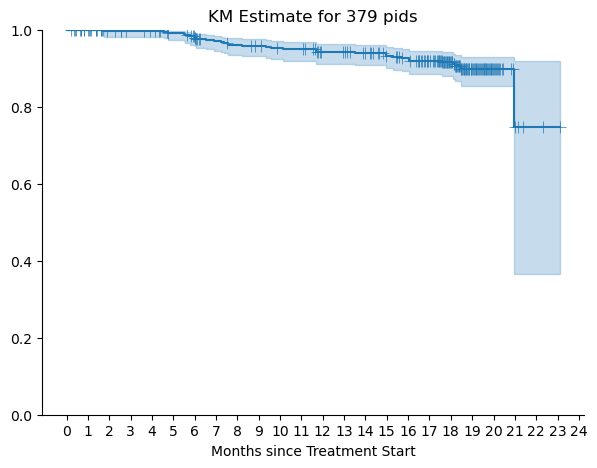

In [112]:
fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_tx_outcomes.months.max()))

kmf = lifelines.KaplanMeierFitter()

kmf.fit(df_tx_outcomes['months'], event_observed=df_tx_outcomes['event'],)# label=group_name)

kmf.plot_survival_function(ax=ax, 
                           show_censors=True, 
                           censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                           # label=f"# Sites ≥ {int(group)} = {len(df_single_group)}",
                          )

# Original event table (indexed by actual event/censor times)
event_table = kmf.event_table

# Define integer time points of interest
integer_times = np.arange(0, max_val + 1)

# Reindex to integer times
event_table_int = (
    event_table.reindex(integer_times, method="ffill").fillna(method="bfill")
)

# Now you can extract at-risk and censored at integer times
at_risk_int = event_table_int["at_risk"]
censored_int = event_table_int["censored"]

every_other_month = np.linspace(0, max_val, 13)

sns.despine()
ax.get_legend().remove()
plt.xlabel('Months since Treatment Start')
ax.set_xticks(range(0, max_val + 1))

plt.ylim(0, 1)
plt.title(f"KM Estimate for {df_tx_outcomes.pid.nunique()} pids")
# plt.savefig("../results/figures/outcomes/baseline/KM_estimate.svg", bbox_inches='tight')

In [224]:
event_table_int[['at_risk', 'censored']].loc[every_other_month].T

event_at,0,2,4,6,8,10,12,14,16,18,20,22,24
at_risk,379,354,347,331,317,310,299,291,275,197,22,3,1
censored,0,1,1,1,0,1,1,1,1,4,1,1,1


In [226]:
df_pids_for_outcomes_model.shape, df_pids_for_outcomes_model.pid.nunique()

((379, 7904), 379)

In [227]:
df_pids_for_outcomes_model.pid.nunique()

379

In [435]:
df_pids_for_outcomes_model.F2.max()

0.0258794881094243

In [326]:
df_test_results, df_model_processed, cph_model = fit_cox_models_all_imputations(df_pids_for_outcomes_model,#.query("pid in @pids_with_same_lineage_and_low_F2"),
                                                                                  df_pred_combined,
                                                                                   TRUST_phenos,
                                                                                  df_tx_outcomes,
                                                                                  cols_lst,# + ['RIF_AUC'],
                                                                                  event_col = 'event',
                                                                                  time_col = 'date',
                                                                                 MIC_type = 'none',
                                                                                  # MIC_type='predicted',
                                                                                 include_drugs=['RIF'],
                                                                                 binarize_drugs=['RIF'],
                                                                                  tb_deaths_only=tb_deaths_only,
                                                                                  invert_OR=False,
                                                                                  stratify_variables=stratify_covariates,
                                                                                 binary_lineage=True,
                                                                                PLI_thresh=PLI_thresh
                                                                                 )


# convert to HR per 10 years
OR_col = 'OR'
df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

df_violating_covariates = []

for model_idx in range(len(cph_model)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_model[model_idx], df_model_processed[model_idx], time_transform='rank').summary

    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)
print(len(df_violating_covariates.query("p <= 0.05")))

df_model_processed = df_model_processed[0]
cph_model = cph_model[0]

cph_model.check_assumptions(df_model_processed)
print(f"    AIC: {cph_model.AIC_partial_}")
print(f"    Concordance Index: {cph_model.concordance_index_}")
print(f"    Log Likelihood: {cph_model.log_likelihood_}")

base_model_LL = cph_model.log_likelihood_

    Censored 6 patients with non-TB deaths
    367 total pids
0
Proportional hazard assumption looks okay.
    AIC: 297.1123092179953
    Concordance Index: 0.672806524184477
    Log Likelihood: -134.55615460899764


In [325]:
OR_col = 'OR'

df_test_results.query("pval <= 0.05").sort_values('pval')[['pval', 'covariate', f"{OR_col}_lower", OR_col, f"{OR_col}_upper"]]

,pval,covariate,OR_lower,OR,OR_upper
2,0.02431,HIV_Low_CD4,1.169192,3.335772,9.51715


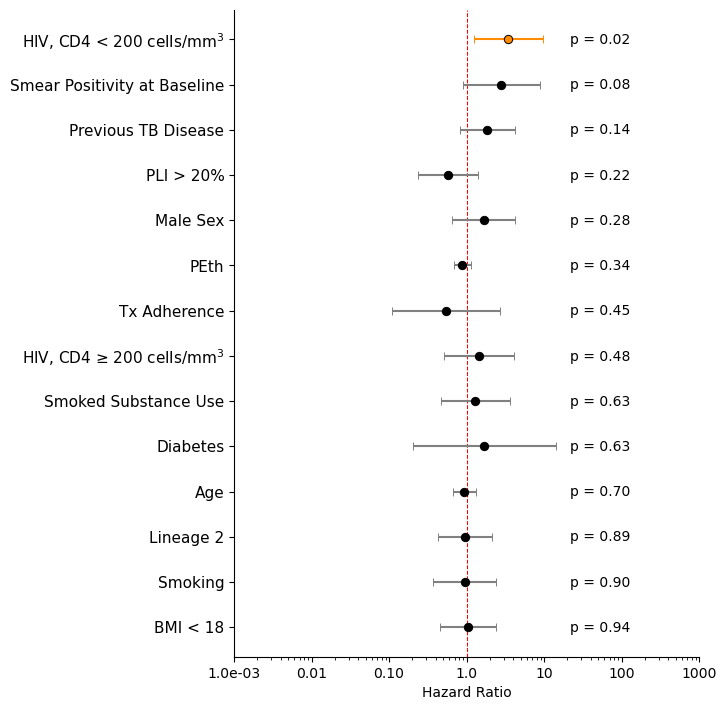

In [327]:
forest_plot(df_test_results, 
            df_test_results.sort_values(['pval', 'OR'], ascending=[True, False]).covariate.values, 
            labels_dict, 
            val_col='OR', 
            alpha=0.05, 
            log=True, 
            pval_offset=1.5, 
            df_stratify_variables_results=None, 
            # saveName="../results/figures/outcomes/forest_plot.svg"
           )


# Univariate Patient Associations

In [60]:
# df_univariate_associations = []

# for col in cols_lst + list(df_pids_for_outcomes_model.columns[df_pids_for_outcomes_model.columns.str.contains('AUC')]):
    
#     df_test_results, df_model_processed, cph_model = fit_cox_models_all_imputations(df_pids_for_outcomes_model,#.query("pid in @pids_with_low_F2"),
#                                                                                   df_pred_combined,
#                                                                                    TRUST_phenos,
#                                                                                   df_tx_outcomes,
#                                                                                     [col],
#                                                                                   event_col = 'event',
#                                                                                   time_col = 'date',
#                                                                                 MIC_type = 'none',
#                                                                                   # MIC_type=MIC_type,
#                                                                                  # include_drugs=['RIF'],
#                                                                                  # binarize_drugs=['RIF'],
#                                                                                   tb_deaths_only=tb_deaths_only,
#                                                                                   invert_OR=False,
#                                                                                   stratify_variables=stratify_covariates,
#                                                                                  binary_lineage=True,
#                                                                                     PLI_thresh=PLI_thresh,
#                                                                                  )


#     # convert to HR per 10 years
#     OR_col = 'OR'
#     df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

#     df_violating_covariates = []

#     for model_idx in range(len(cph_model)):

#         df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_model[model_idx], df_model_processed[model_idx], time_transform='rank').summary

#         # diabetes has a p-value of like 0.0105
#         violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})

#         violating_covariates['imp_num'] = model_idx + 1

#         df_violating_covariates.append(violating_covariates)

#     df_violating_covariates = pd.concat(df_violating_covariates)
#     print(len(df_violating_covariates.query("p <= 0.05")))

#     df_model_processed = df_model_processed[0]
#     cph_model = cph_model[0]

#     cph_model.check_assumptions(df_model_processed)
    
#     df_univariate_associations.append(df_test_results)
#     # print(f"    AIC: {cph_model.AIC_partial_}")
#     # print(f"    Concordance Index: {cph_model.concordance_index_}")
#     # print(f"    Log Likelihood: {cph_model.log_likelihood_}")

#     # base_model_LL = cph_model.log_likelihood_
    
# df_univariate_associations = pd.concat(df_univariate_associations)

In [174]:
df_univariate_associations.query("pval <= 0.2").sort_values('pval')

,covariate,coef,exp(coef),se(coef),coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper
1,HIV_Low_CD4,0.379364,1.461355,0.144275,1.276461,0.485446,1,0.008552,3.583933,1.384036,9.280525
0,RIF_AUC,-0.596518,0.550726,0.257646,-0.060013,0.025920,1,0.020598,0.941753,0.895104,0.990833
0,smoked_substance_use,0.349490,1.418344,0.217507,0.709921,0.441824,1,0.108099,2.033831,0.855527,4.834997
0,peth_value_baseline,-0.291996,0.746772,0.200736,-0.167327,0.115031,1,0.145773,0.845923,0.675175,1.059852
0,PZA_AUC,-0.331795,0.717635,0.229922,-0.005445,0.003773,1,0.148998,0.994570,0.987243,1.001952


In [490]:
# diversity_metric = 'ChangeSites'

# df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid', diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])

# sns.histplot(df_add_metric_for_model,
#              x=diversity_metric,
#              hue='Lineage',
#              multiple='dodge',
#              # bins=range(int(df_add_metric_for_model[diversity_metric].min()), int(df_add_metric_for_model[diversity_metric].max()) + 2), discrete=True
#             )

# plt.axvline(8, color='red', label="8")
# plt.legend()

# plt.title(f"{df_add_metric_for_model.pid.nunique()} pids")

# sns.despine()
# plt.savefig(f"../results/figures/change_sites.svg", bbox_inches='tight')

In [491]:
# diversity_metric = 'NumVar'

# df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid', diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])

# sns.histplot(df_add_metric_for_model,
#              x=diversity_metric,
#              hue='Lineage',
#              multiple='dodge',
#              # bins=range(int(df_add_metric_for_model[diversity_metric].min()), int(df_add_metric_for_model[diversity_metric].max()) + 2), discrete=True
#             )

# plt.axvline(9, color='red', label="9")
# plt.legend()

# plt.title(f"{df_add_metric_for_model.pid.nunique()} pids")

# sns.despine()
# plt.savefig(f"../results/figures/segregating_sites.svg", bbox_inches='tight')

In [328]:
diversity_metric = 'NumVar1'
# diversity_metric = 'SASE1'
binarize = False
thresh = 0.1

# grouped_variant_genes = ['Rv2690c'] #['phoR'] #['sugI'] #['devS', 'devR']

# df_LAF['grouped_variant'] = df_LAF['pid'].isin(df_lowAF_variants.query("GENE in @grouped_variant_genes").pid.unique()).astype(int)
# df_LAF_baseline['grouped_variant'] = df_LAF_baseline['pid'].isin(df_lowAF_variants_baseline.query("GENE in @grouped_variant_genes").pid.unique()).astype(int)

# print(df_LAF_baseline.grouped_variant.value_counts())

# diversity_metric = 'ChangeSites'
# binarize = True
# thresh = 8

# diversity_metric = 'NumVar'
# binarize = True
# thresh = 9

df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid', diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])
# df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid', diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])

if binarize:
    df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > thresh).astype(int)
    
    median_val = df_add_metric_for_model[diversity_metric].median()
    # df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > median_val).astype(int)

df_test_results_diversity, df_model_processed, cph_model = fit_cox_models_all_imputations(df_add_metric_for_model,#.query("pid in @pids_with_same_lineage_and_low_F2"),
                                                              df_pred_combined, 
                                                                TRUST_phenos,
                                                              df_tx_outcomes,
                                                           cols_lst + [diversity_metric],# + ['RIF_AUC'],
                                                              event_col = 'event',
                                                              time_col = 'date',
                                                            MIC_type='none',
                                                           # MIC_type='predicted',
                                                             include_drugs=['RIF'],
                                                             binarize_drugs=['RIF'],
                                                              tb_deaths_only=tb_deaths_only,
                                                              invert_OR=False,
                                                              stratify_variables=stratify_covariates,
                                                             binary_lineage=True,
                                                                                          PLI_thresh=PLI_thresh
                                                             )

df_model_processed = df_model_processed[0]
cph_model = cph_model[0]

OR_col = 'OR'

cph_model.check_assumptions(df_model_processed)
print(f"    AIC: {cph_model.AIC_partial_}")
print(f"    Concordance Index: {cph_model.concordance_index_}")
print(f"    Log Likelihood: {cph_model.log_likelihood_}")

diversity_metric_continuous_LL = cph_model.log_likelihood_

# scale the odds ratio to be for an increase of 5 variable sites
if not binarize:
    scale_factor = 10
    df_test_results_diversity.loc[df_test_results_diversity['covariate']==diversity_metric, [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]] = df_test_results_diversity.loc[df_test_results_diversity['covariate']==diversity_metric, [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]]**scale_factor
    df_test_results_diversity.loc[df_test_results_diversity['covariate']=='screen_years', [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]] = df_test_results_diversity.loc[df_test_results_diversity['covariate']=='screen_years', [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]]**scale_factor

print(f"Final: {df_model_processed.pid.nunique()} pids")

    Censored 6 patients with non-TB deaths
    367 total pids
Proportional hazard assumption looks okay.
    AIC: 295.6220146254339
    Concordance Index: 0.7016310461192351
    Log Likelihood: -132.81100731271695
Final: 367 pids


In [329]:
df_test_results_diversity.query("pval <= 0.05").sort_values(['pval'])

,covariate,coef,exp(coef),se(coef),coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper
2,HIV_Low_CD4,0.336185,1.399598,0.154726,1.128720,0.519484,1,0.029798,3.091698,1.116892,8.558211
1,NumVar1,0.313397,1.368065,0.152063,0.115755,0.056165,1,0.039306,3.182118,1.058367,9.567449


In [330]:
# Cox Snell Pseudo R^2.
# There is not a good consensus on how to compute R^2 for survival regression models, so I picked this one
1 - np.exp(2/len(df_model_processed) * (base_model_LL - diversity_metric_continuous_LL))

0.00946525923336805

In [331]:
df_test_results_diversity.OR_upper.max()

17.571051469435837

In [332]:
def LRT(LL_1, LL_2):
    
    test_stat = np.abs(2 * (LL_1 - LL_2))

    # p-value from the chi-squared distribution
    return 1 - st.chi2.cdf(test_stat, 1)

In [333]:
LRT(diversity_metric_continuous_LL, base_model_LL)

0.06172959902515962

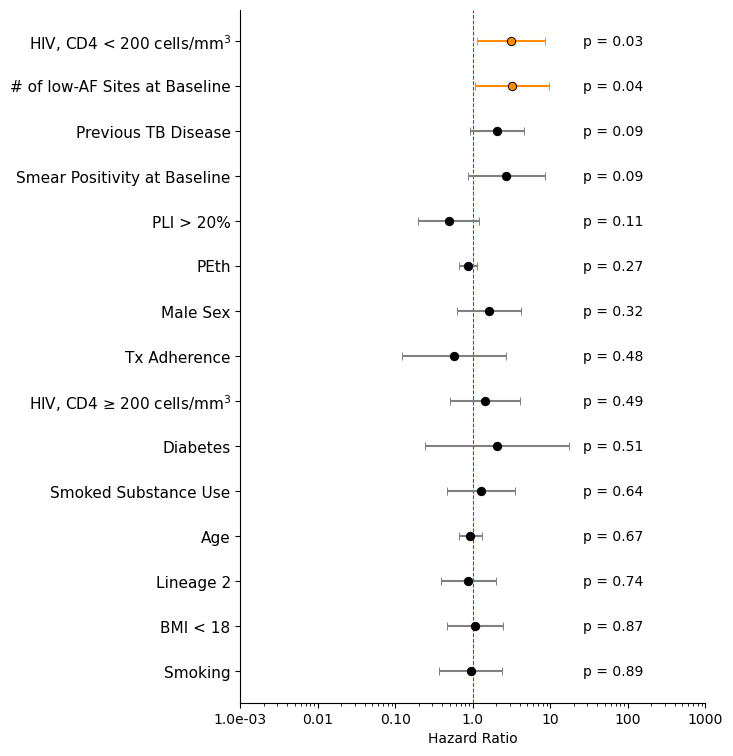

In [334]:
forest_plot(df_test_results_diversity, 
            df_test_results_diversity.sort_values(['pval', 'OR'], ascending=[True, False]).covariate.values, 
            labels_dict, 
            val_col='OR', 
            alpha=0.05, 
            log=True,
            pval_offset=1.5, 
            df_stratify_variables_results=None, 
            # saveName="../results/figures/outcomes/pilon_forest_plot_with_diversity.svg"
           )



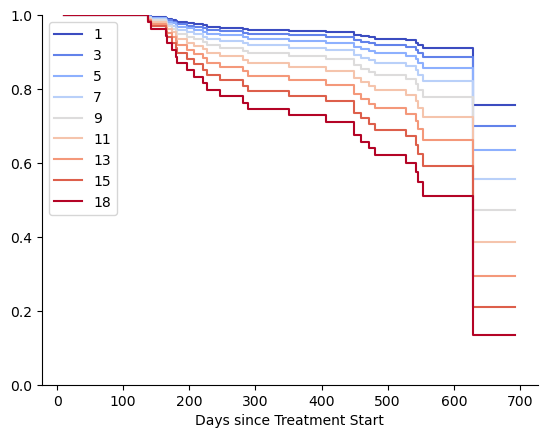

In [260]:
scaler = StandardScaler()

raw_values = df_add_metric_for_model.query("pid in @df_model_processed.pid")[diversity_metric].values

raw_mean = raw_values.mean()
raw_sd = raw_values.std()

scaled_values = (raw_values - raw_mean) / raw_sd

def unscale_val(scaled_val, raw_mean, raw_sd):
    # it should be an integer, so return it as such. If it's not, it's a float precision problem
    return int(scaled_val * raw_sd + raw_mean)

# percentiles_lst = [25, 50, 75, 87.5, 100]

# if binarize:
#     test_vals = df_model_processed[diversity_metric].unique()
# else:
#     test_vals = np.percentile(scaled_values, percentiles_lst)
    
# percentile_dict = dict(zip(test_vals, percentiles_lst))

test_vals = np.linspace(1, df_add_metric_for_model.NumVar1.max(), int(df_add_metric_for_model.NumVar1.max() / 2))
test_vals = (test_vals - raw_mean) / raw_sd

ax = cph_model.plot_partial_effects_on_outcome(covariates=diversity_metric, values=test_vals, plot_baseline=False, cmap='coolwarm')

# Update legend labels
handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles, [f"{perc}th perc. = {str(unscale_val(val, raw_mean, raw_sd))}" for val, perc in percentile_dict.items()])
ax.legend(handles, [f"{str(unscale_val(val, raw_mean, raw_sd))}" for val in test_vals])
ax.set_xlabel('Days since Treatment Start')
plt.ylim(0, 1)

sns.despine()
plt.savefig("../results/figures/outcomes/pilon_NumVar1_varying_hazard.svg", bbox_inches='tight')

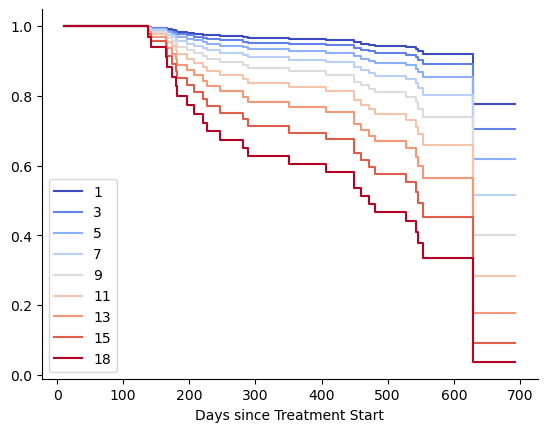

In [144]:
# scaler = StandardScaler()

# raw_values = df_add_metric_for_model.query("pid in @df_model_processed.pid")[diversity_metric].values

# raw_mean = raw_values.mean()
# raw_sd = raw_values.std()

# scaled_values = (raw_values - raw_mean) / raw_sd

# def unscale_val(scaled_val, raw_mean, raw_sd):
#     # it should be an integer, so return it as such. If it's not, it's a float precision problem
#     return int(scaled_val * raw_sd + raw_mean)

# # percentiles_lst = [25, 50, 75, 87.5, 100]

# # if binarize:
# #     test_vals = df_model_processed[diversity_metric].unique()
# # else:
# #     test_vals = np.percentile(scaled_values, percentiles_lst)
    
# # percentile_dict = dict(zip(test_vals, percentiles_lst))

# test_vals = np.linspace(1, df_add_metric_for_model.NumVar1.max(), int(df_add_metric_for_model.NumVar1.max() / 2))
# test_vals = (test_vals - raw_mean) / raw_sd

# ax = cph_model.plot_partial_effects_on_outcome(covariates=diversity_metric, values=test_vals, plot_baseline=False, cmap='coolwarm')

# # Update legend labels
# handles, labels = ax.get_legend_handles_labels()
# # ax.legend(handles, [f"{perc}th perc. = {str(unscale_val(val, raw_mean, raw_sd))}" for val, perc in percentile_dict.items()])
# ax.legend(handles, [f"{str(unscale_val(val, raw_mean, raw_sd))}" for val in test_vals])
# ax.set_xlabel('Days since Treatment Start')

# sns.despine()
# plt.savefig("../results/figures/outcomes/NumVar1_varying_hazard.svg", bbox_inches='tight')

# Binarized NumVar1

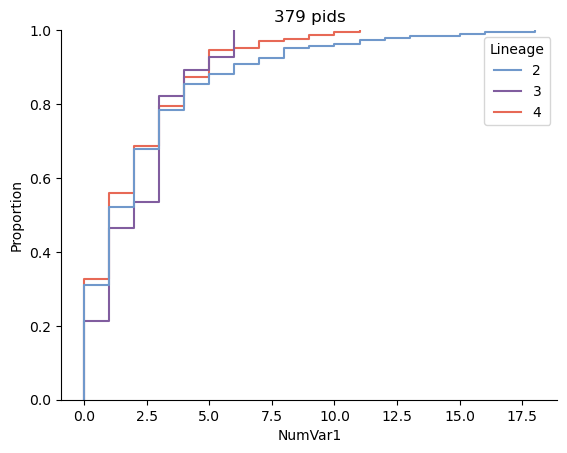

In [261]:
diversity_metric = 'NumVar1'

df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid', diversity_metric]])#.query("pid in @pids_with_same_lineage_and_low_F2")#.merge(df_LAF[['pid', col_to_binarize]])

LinToColor_Dict = {"1": "#DF83AC",
                   "2": "#7098CB",
                   "3": "#815D9F",
                   "4": "#E76956",
                   # "Other": "white"
                   # "5": "#B67548",
                   # "6": "#6AB79E",
                   # "8": "#E4515B",
                   # "M.bovis": "white",
                  }
    
sns.ecdfplot(df_add_metric_for_model,
             x=diversity_metric,
             hue='Lineage',
             hue_order=['2', '3', '4'],
             palette=LinToColor_Dict
            )

binarize_thresh = 4
# plt.axvline(binarize_thresh, color='black', label=str(binarize_thresh))
# plt.legend()

plt.title(f"{df_add_metric_for_model.pid.nunique()} pids")

sns.despine()
# plt.savefig(f"../results/figures/variable_sites_sample1.svg", bbox_inches='tight')

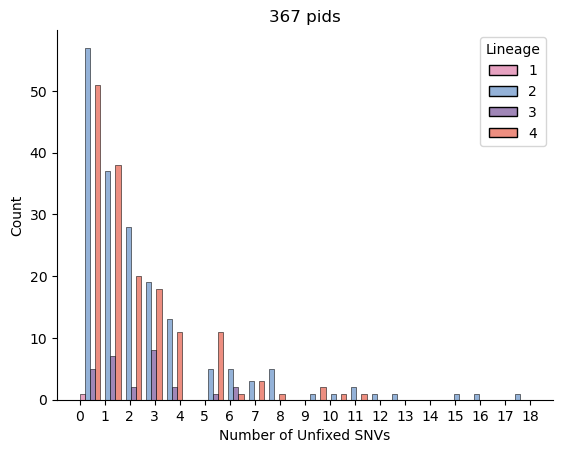

In [262]:
diversity_metric = 'NumVar1'

df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid', diversity_metric]])#.query("pid in @pids_with_same_lineage_and_low_F2")#.merge(df_LAF[['pid', col_to_binarize]])

df_add_metric_for_model = df_add_metric_for_model.query("pid in @df_model_processed.pid")

LinToColor_Dict = {"1": "#DF83AC",
                   "2": "#7098CB",
                   "3": "#815D9F",
                   "4": "#E76956",
                   # "Other": "white"
                   # "5": "#B67548",
                   # "6": "#6AB79E",
                   # "8": "#E4515B",
                   # "M.bovis": "white",
                  }
    
sns.histplot(df_add_metric_for_model,
             x=diversity_metric,
             hue='Lineage',
             multiple='dodge',
             # bins=range(int(df_add_metric_for_model[diversity_metric].min()), int(df_add_metric_for_model[diversity_metric].max()) + 2),
             hue_order=['1', '2', '3', '4'],
             palette=LinToColor_Dict
            )

# Force integer x-axis ticks
plt.xticks(
    np.arange(
        int(df_add_metric_for_model[diversity_metric].min()),
        int(df_add_metric_for_model[diversity_metric].max()) + 1
    )
)

plt.title(f"{df_add_metric_for_model.pid.nunique()} pids")
plt.xlabel('Number of Unfixed SNVs')

sns.despine()
plt.savefig(f"../results/figures/pilon_variable_sites_sample1.svg", bbox_inches='tight')

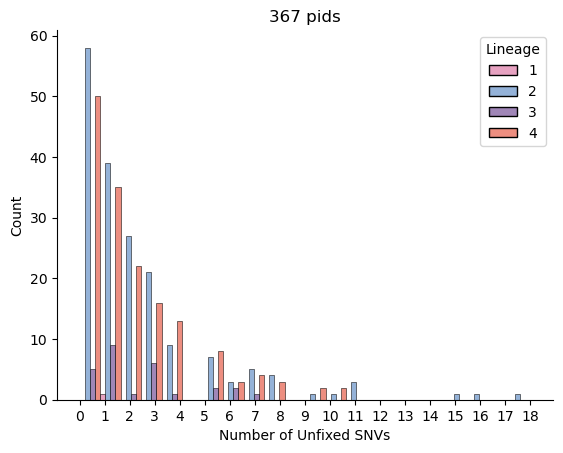

In [145]:
diversity_metric = 'NumVar1'

df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid', diversity_metric]])#.query("pid in @pids_with_same_lineage_and_low_F2")#.merge(df_LAF[['pid', col_to_binarize]])

df_add_metric_for_model = df_add_metric_for_model.query("pid in @df_model_processed.pid")

LinToColor_Dict = {"1": "#DF83AC",
                   "2": "#7098CB",
                   "3": "#815D9F",
                   "4": "#E76956",
                   # "Other": "white"
                   # "5": "#B67548",
                   # "6": "#6AB79E",
                   # "8": "#E4515B",
                   # "M.bovis": "white",
                  }
    
sns.histplot(df_add_metric_for_model,
             x=diversity_metric,
             hue='Lineage',
             multiple='dodge',
             # bins=range(int(df_add_metric_for_model[diversity_metric].min()), int(df_add_metric_for_model[diversity_metric].max()) + 2),
             hue_order=['1', '2', '3', '4'],
             palette=LinToColor_Dict
            )

# Force integer x-axis ticks
plt.xticks(
    np.arange(
        int(df_add_metric_for_model[diversity_metric].min()),
        int(df_add_metric_for_model[diversity_metric].max()) + 1
    )
)

plt.title(f"{df_add_metric_for_model.pid.nunique()} pids")
plt.xlabel('Number of Unfixed SNVs')

sns.despine()
plt.savefig(f"../results/figures/variable_sites_sample1.svg", bbox_inches='tight')

In [146]:
groups = [
    g["NumVar1"].values
    for _, g in df_add_metric_for_model.groupby("Lineage")
]

st.kruskal(*groups)

KruskalResult(statistic=1.0421294470676918, pvalue=0.7910593406819596)

In [147]:
df_add_metric_for_model.F2.max()

0.0258794881094243

In [148]:
df_add_metric_for_model.Sampling_Week.unique()

array([1, 2])

In [105]:
# diversity_metric = 'NumVar1'
# binarize = True
# thresh = 4

# # diversity_metric = 'ChangeSites'
# # binarize = True
# # thresh = 8

# # diversity_metric = 'NumVar'
# # binarize = True
# # thresh = 9

# df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid', diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])

# if binarize:
#     df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > thresh).astype(int)
    
#     median_val = df_add_metric_for_model[diversity_metric].median()
#     # df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > median_val).astype(int)

# df_test_results_diversity, df_model_processed, cph_model = fit_cox_models_all_imputations(df_add_metric_for_model,
#                                                               df_pred_combined, 
#                                                                 TRUST_phenos,
#                                                               df_tx_outcomes,
#                                                            cols_lst + [diversity_metric] + ['RIF_AUC'],
#                                                            #  [diversity_metric],
#                                                               event_col = 'event',
#                                                               time_col = 'date',
#                                                            MIC_type=MIC_type,
#                                                              include_drugs=['RIF'],
#                                                              binarize_drugs=['RIF'],
#                                                               tb_deaths_only=tb_deaths_only,
#                                                               invert_OR=False,
#                                                               # stratify_variables=['RIF_pred_MIC_high'],
#                                                              binary_lineage=True
#                                                              )

# df_model_processed = df_model_processed[0]
# cph_model = cph_model[0]

# OR_col = 'OR'

# cph_model.check_assumptions(df_model_processed)
# print(f"    AIC: {cph_model.AIC_partial_}")
# print(f"    Concordance Index: {cph_model.concordance_index_}")
# print(f"    Log Likelihood: {cph_model.log_likelihood_}")

# diversity_metric_binarized_LL = cph_model.log_likelihood_

# # scale the odds ratio to be for an increase of 5 variable sites
# if not binarize:
#     scale_factor = 10
#     df_test_results_diversity.loc[df_test_results_diversity['covariate']==diversity_metric, [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]] = df_test_results_diversity.loc[df_test_results_diversity['covariate']==diversity_metric, [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]]**scale_factor
#     df_test_results_diversity.loc[df_test_results_diversity['covariate']=='screen_years', [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]] = df_test_results_diversity.loc[df_test_results_diversity['covariate']=='screen_years', [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]]**scale_factor

# print(f"Final: {df_model_processed.pid.nunique()} pids")

In [106]:
# if binarize:
#     saveName = f"../results/figures/outcomes/NumVar1_binarized_{thresh}.svg"
# else:
#     saveName = f"../results/figures/outcomes/NumVar1_continuous.svg"

# forest_plot(df_test_results_diversity, 
#             df_test_results_diversity.sort_values(['pval', 'OR'], ascending=[True, False]).covariate.values, 
#             labels_dict, 
#             val_col='OR', 
#             alpha=0.05, 
#             log=True, 
#             pval_offset=2, 
#             df_stratify_variables_results=None, 
#             saveName=saveName
#            )



In [263]:
def bin_by_min_count(values, min_count):
    """
    Group sorted values into bins with at least `min_count` elements.
    
    Parameters
    ----------
    values : array-like
        The input values.
    min_count : int
        Minimum number of elements per bin.
        
    Returns
    -------
    bins : list of arrays
        A list of arrays, each containing the values in that bin.
    edges : list of tuples
        (min, max) range for each bin.
    """
    values = np.sort(values)
    n = len(values)
    
    # Determine split indices
    splits = np.arange(min_count, n, min_count)
    bins = np.split(values, splits)
    
    # Merge last bin if it's too small
    if len(bins[-1]) < min_count and len(bins) > 1:
        bins[-2] = np.concatenate([bins[-2], bins[-1]])
        bins = bins[:-1]
    
    edges = [(b[0], b[-1]) for b in bins]
    return bins, edges

196
95
76
var_group: p = 0.09585803485534589


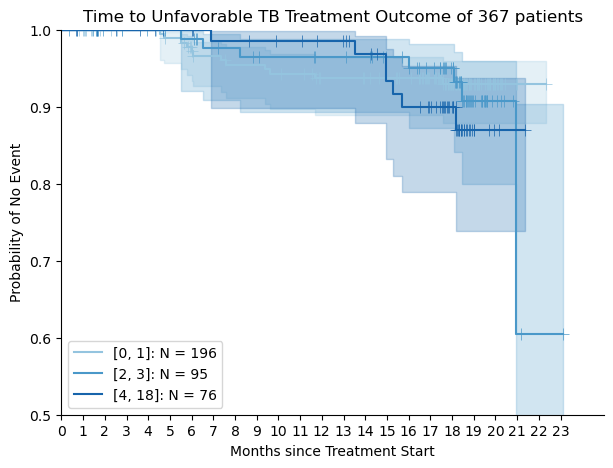

In [266]:
df_KM_plot = df_add_metric_for_model.query("pid in @df_model_processed.pid").merge(df_tx_outcomes[['pid', 'event_type', 'TB_death', 'date', 'event', 'weeks', 'months']])

df_KM_plot['NumVar1'] = df_KM_plot['NumVar1'].astype(int)

df_KM_plot["var_group"] = pd.qcut(
    df_KM_plot["NumVar1"],
    q=[0, 0.50, 0.75, 1.0],       # quantile cutpoints
    labels=["Q2", "Q3", "Q4"]     # group names
)

# percentiles = [0, 25, 50, 75]

# # for i, perc in enumerate(percentiles):
#     # perc_value = np.percentile(df_KM_plot['NumVar1'], perc)
#     # print(perc, perc_value)
# for i, perc_value in enumerate([0, 1, 3, 4]):
#     df_KM_plot.loc[df_KM_plot['NumVar1'] >= perc_value, "var_group"] = f"Q{i+1}"
    
# it's the binarized one here, not raw values
del df_KM_plot[diversity_metric]

# get raw values
df_KM_plot = df_KM_plot.merge(df_LAF_baseline[['pid', 'NumVar1']])

fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_KM_plot.months.max()))

kmf = lifelines.KaplanMeierFitter()

# stratify_col = f'{diversity_metric}_Binary'
# df_KM_plot[stratify_col] = (df_KM_plot[diversity_metric] > thresh).astype(int)
# label_dict = {0: f'# Low-AF Sites ≤ {thresh}', 1: f'# Low-AF Sites > {thresh}'}
# color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

stratify_col = 'var_group'

label_dict = {
    "Q1": r"$25^{\mathrm{th}}$",
    "Q2": r"$50^{\mathrm{th}}$",
    "Q3": r"$75^{\mathrm{th}}$",
    "Q4": r"$100^{\mathrm{th}}$"
}

value_dict = {var: [df_KM_plot.query(f"var_group==@var").NumVar1.min(), df_KM_plot.query(f"var_group==@var").NumVar1.max()] for var in label_dict.keys()}

color_dict = dict(zip(list(label_dict.keys()), sns.color_palette('Blues', n_colors=len(label_dict)).as_hex()))

kmf_tables = []

if tb_deaths_only:
    df_KM_plot.loc[df_KM_plot['TB_death']==0, 'event'] = 0

for group in np.sort(df_KM_plot[stratify_col].unique()):
    
    df_single_group = df_KM_plot.query(f"{stratify_col}==@group")
    print(len(df_single_group))
    group_name = label_dict[group]

    kmf.fit(df_single_group['months'], event_observed=df_single_group['event'],)# label=group_name)
    
    kmf.plot_survival_function(ax=ax, 
                               show_censors=True, 
                               color=color_dict[group], 
                               censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                               # label=f"# Sites ≥ {int(group)} = {len(df_single_group)}",
                               # label=f"{group_name} = [{int(value_dict[group][0])}, {int(value_dict[group][1])}]: (N = {len(df_single_group)})"
                               label=f"[{int(value_dict[group][0])}, {int(value_dict[group][1])}]: N = {len(df_single_group)}"
                              )
    
    # Original event table (indexed by actual event/censor times)
    event_table = kmf.event_table

    # Define integer time points of interest
    integer_times = np.arange(0, max_val + 1)

    # Reindex to integer times
    event_table_int = (
        event_table.reindex(integer_times, method="ffill").fillna(method="bfill")
    )

    # Now you can extract at-risk and censored at integer times
    at_risk_int = event_table_int["at_risk"]
    censored_int = event_table_int["censored"]

    every_other_month = np.linspace(0, max_val, 13)
    
    # event_table_int['Group'] = group_name
    # kmf_tables.append(event_table_int[['Group', 'at_risk', 'censored']].loc[every_other_month])
    
# kmf_tables = pd.concat(kmf_tables, axis=1)

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_KM_plot.pid.nunique()} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")

plt.xlim(0, max_val + 1)
plt.ylim(0.5, 1)

logRank_test_results = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=1, weightings="fleming-harrington")
print(f"{stratify_col}: p = {logRank_test_results.p_value}")

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, int(df_KM_plot['months'].max()) + 1))

# plt.legend(title='Percentiles')

sns.despine()
# plt.savefig(f"../results/figures/outcomes/KM_estimate_binarized_{thresh}.svg", bbox_inches='tight')
plt.savefig(f"../results/figures/outcomes/pilon_KM_estimate_percentiles.svg", bbox_inches='tight')

In [267]:
logRank_test_results = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=0, weightings="fleming-harrington")

print(f"{stratify_col}: p = {logRank_test_results.p_value}")

var_group: p = 0.6622499930982957


In [150]:
logRank_test_results = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=0, weightings="fleming-harrington")

print(f"{stratify_col}: p = {logRank_test_results.p_value}")

var_group: p = 0.12329709047240689


In [151]:
len(df_KM_plot.query("NumVar1==0")), len(df_KM_plot.query("NumVar1==1")), len(df_KM_plot.query("NumVar1 in [2, 3]"))

(113, 84, 93)

In [152]:
np.percentile(df_KM_plot.NumVar1, 25), np.percentile(df_KM_plot.NumVar1, 50), np.percentile(df_KM_plot.NumVar1, 75)

(0.0, 1.0, 3.0)

In [153]:
df_KM_plot.query("var_group=='Q3'").NumVar1.min(), df_KM_plot.query("var_group=='Q3'").NumVar1.max()

(2, 3)

In [154]:
df_KM_plot.query("var_group=='Q4'").NumVar1.min()

4

In [155]:
df_KM_plot.groupby('var_group')['event'].mean()

var_group
Q2    0.050761
Q3    0.075269
Q4    0.116883
Name: event, dtype: float64

In [156]:
df_KM_plot.query("months >= 12").groupby('var_group')['event'].mean()

var_group
Q2    0.006289
Q3    0.054795
Q4    0.100000
Name: event, dtype: float64

In [157]:
df_KM_plot.query("months >= 15 & event_type != 'cure'")[['pid', 'event', 'event_type', 'screen_date', 'esp_date_end_of_study_parti', 'date']]

,pid,event,event_type,screen_date,esp_date_end_of_study_parti,date
26,T0031,1,relapse,2017-11-17,2019-05-17,546.0
44,T0051,0,death,2018-02-09,2019-06-13,481.0
73,T0089,0,relapse,2018-07-20,2019-12-02,500.0
85,T0107,1,relapse,2018-10-05,2020-06-25,629.0
94,T0118,0,death,2018-11-08,2020-07-02,602.0
104,T0130,0,relapse,2018-12-11,2020-08-04,602.0
109,T0135,1,relapse,2019-01-18,2020-07-14,543.0
130,T0162,1,relapse,2019-05-21,2020-11-25,554.0
142,T0176,0,relapse,2019-07-19,2021-03-02,592.0
204,T0249,1,relapse,2021-01-05,2022-04-21,471.0
